In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler # Imported but not used in provided cells
from sklearn.ensemble import RandomForestClassifier # Imported but not used in provided cells
from sklearn.model_selection import train_test_split # Imported but not used in provided cells
import os
import time # Imported but not used in provided cells
import json # Moved import here for clarity

# Set plot styles
# Using the updated style name to address the deprecation warning.
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

print("Plot styles set.") # Optional: Confirmation message

print("Libraries imported and styles set.")

Plot styles set.
Libraries imported and styles set.


In [2]:
def load_combined_data(thursday_file, friday_file, sample_size_per_file=None):
    """
    Load and combine data from Thursday and Friday datasets.
    Uses simplified random sampling if sample_size_per_file is provided.
    """
    print("Loading and combining Thursday and Friday datasets...")
    dfs = []

    for file_path, day_label in [(thursday_file, 'Thursday'), (friday_file, 'Friday')]:
        print(f"Loading data from {file_path}...")
        try:
            if sample_size_per_file:
                # Count total rows efficiently
                with open(file_path, 'r') as f:
                    total_rows = sum(1 for row in f) -1 # Adjust for header

                if total_rows > sample_size_per_file:
                    # Generate row indices to skip (0-based index for skiprows)
                    skip_indices = np.random.choice(np.arange(1, total_rows + 1),
                                                    total_rows - sample_size_per_file,
                                                    replace=False)
                    # Sort skip indices because read_csv expects them sorted
                    df_day = pd.read_csv(file_path, skiprows=sorted(skip_indices))
                    print(f"Sampled {len(df_day)} rows from {day_label} dataset")
                else:
                    # Sample size >= total rows, load all
                    df_day = pd.read_csv(file_path)
                    print(f"Loaded all {len(df_day)} rows from {day_label} dataset (sample size >= total).")
            else:
                df_day = pd.read_csv(file_path)
                print(f"Loaded all rows from {day_label} dataset.")

            df_day['source'] = day_label
            dfs.append(df_day)

        except FileNotFoundError:
             print(f"Error: File not found at {file_path}. Skipping.")
        except Exception as e:
            print(f"Error loading {file_path}: {e}. Skipping.")

    if not dfs:
        print("Error: No data loaded. Returning None.")
        return None

    df_combined = pd.concat(dfs, ignore_index=True)
    print(f"Combined dataset shape: {df_combined.shape}")
    return df_combined

def clean_and_prepare_data(df):
    """
    Clean and prepare data for anomaly detection.
    Handles inf/NaN, creates attack labels, and plots distribution.
    """
    if df is None:
        print("Input DataFrame is None. Cannot clean data.")
        return None

    print("\nCleaning and preparing data...")
    df_clean = df.copy()

    # Strip leading/trailing whitespace from column names
    df_clean.columns = df_clean.columns.str.strip()

    # Handle missing and infinite values
    print("Handling missing and infinite values...")
    numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

    # Replace infinite values with NaN
    df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Impute specific columns ('Flow Byts/s', 'Flow Pkts/s') with their median
    for col in ['Flow Byts/s', 'Flow Pkts/s']:
        if col in df_clean.columns:
            if df_clean[col].notna().any():
                median_val = df_clean[col].median(skipna=True)
                df_clean[col].fillna(median_val, inplace=True)
                print(f"Filled NaNs in '{col}' with median: {median_val}")
            else:
                 df_clean[col].fillna(0, inplace=True) # Fallback if all values are NaN
                 print(f"Filled NaNs in '{col}' with 0 (all values were NaN).")

    # Fill remaining numeric NaNs with 0 (Consider if appropriate for all)
    remaining_numeric_na = df_clean[numeric_cols].isnull().sum().sum()
    if remaining_numeric_na > 0:
        df_clean[numeric_cols] = df_clean[numeric_cols].fillna(0)
        print(f"Filled {remaining_numeric_na} remaining numeric NaN values with 0.")

    # Fill non-numeric NaNs with a placeholder if necessary (e.g., 'Missing')
    object_cols = df_clean.select_dtypes(include='object').columns
    for col in object_cols:
        if df_clean[col].isnull().any():
             print(f"Filling NaNs in object column '{col}' with 'Missing'.")
             df_clean[col].fillna('Missing', inplace=True)


    # Create binary attack label ('Label' column must exist)
    if 'Label' in df_clean.columns:
        print("Creating binary attack labels...")
        df_clean['Label'] = df_clean['Label'].astype(str) # Ensure string type
        df_clean['is_attack'] = ~df_clean['Label'].str.contains('Benign', case=False, na=False)

        # Create specific attack type labels
        df_clean['attack_type'] = df_clean['Label'].apply(
            lambda x: 'Normal' if 'Benign' in x else
                      'SQL Injection' if 'SQL Injection' in x else # Be specific
                      'Brute Force-Web' if 'Brute Force -Web' in x else # Check exact label names
                      'Brute Force-XSS' if 'Brute Force -XSS' in x else # Check exact label names
                      x # Keep original label if not matched
        )

        # Count attack types
        attack_counts = df_clean['attack_type'].value_counts()
        print("\nAttack type distribution:")
        print(attack_counts)

        # Plot attack distribution
        plt.figure(figsize=(10, max(6, len(attack_counts)*0.5))) # Adjust height
        sns.countplot(y='attack_type', data=df_clean, order = df_clean['attack_type'].value_counts().index)
        plt.title('Distribution of Attack Types')
        plt.tight_layout()
        plt.show()
    else:
        print("Warning: 'Label' column not found. Cannot create attack labels.")
        df_clean['is_attack'] = False # Default or handle as error
        df_clean['attack_type'] = 'Unknown'

    return df_clean

print("Data loading and cleaning functions defined.")

Data loading and cleaning functions defined.


In [3]:
def load_dataset():
    """
    Load the dataset, either from a processed file or by generating it
    from raw files using previously defined functions. Uses absolute paths now.
    """
    # Define file paths (adjust relative paths as needed based on notebook location)
    processed_path = '../../data/processed/combined_dataset.csv' # Keep relative for processed output, or make absolute too

    # Define file paths using the absolute paths provided
    thursday_file = r"C:\Users\mcgahanc\Desktop\msc Cybersecurity\Semester 3\AIML in CyberSec\CA\Datasets\Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv"
    friday_file = r"C:\Users\mcgahanc\Desktop\msc Cybersecurity\Semester 3\AIML in CyberSec\CA\Datasets\Friday-23-02-2018_TrafficForML_CICFlowMeter.csv"

    # Ensure processed data directory exists (using relative path here)
    os.makedirs(os.path.dirname(processed_path), exist_ok=True)

    if os.path.exists(processed_path):
        print(f"Loading processed dataset from: {processed_path}")
        try:
            df = pd.read_csv(processed_path)
            print(f"Loaded processed dataset: {df.shape[0]} rows, {df.shape[1]} columns")
            # Basic check for expected columns after loading
            if 'Label' not in df.columns:
                 print("Warning: Loaded processed data missing 'Label' column.")
            return df
        except Exception as e:
            print(f"Error loading processed file {processed_path}: {e}. Will attempt to recreate.")
            # Fall through to recreate if loading fails

    # If processed file doesn't exist or failed to load, create it
    print("Processed dataset not found or failed to load. Creating from raw data...")

    # Load and combine raw data (make sure load_combined_data is defined in a previous cell)
    df_combined = load_combined_data(thursday_file, friday_file, sample_size_per_file=1000) # Try 10k first

    if df_combined is None:
        print("Failed to load combined data. Cannot proceed.")
        return None

    # Clean and prepare the combined data (make sure clean_and_prepare_data is defined in a previous cell)
    df_clean = clean_and_prepare_data(df_combined)

    if df_clean is None:
        print("Failed to clean data. Cannot proceed.")
        return None

    # Save the processed dataset for future use
    try:
        df_clean.to_csv(processed_path, index=False)
        print(f"Saved newly processed dataset ({df_clean.shape[0]} rows) to {processed_path}")
    except Exception as e:
        print(f"Error saving processed dataset to {processed_path}: {e}")

    return df_clean

print("Master data loading function defined (with updated absolute paths).")

Master data loading function defined (with updated absolute paths).


In [4]:
# Call the function to load the data into the 'df' DataFrame
df = load_dataset()

# Display basic info if loaded successfully
if df is not None:
    print("\nDataFrame loaded successfully. Basic info:")
    df.info()
    # Display first few rows
    # print("\nFirst 5 rows:")
    # print(df.head())
else:
    print("\nDataFrame could not be loaded. Subsequent cells may fail.")

Loading processed dataset from: ../../data/processed/combined_dataset.csv
Loaded processed dataset: 2000 rows, 83 columns

DataFrame loaded successfully. Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 83 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Dst Port           2000 non-null   int64  
 1   Protocol           2000 non-null   int64  
 2   Timestamp          2000 non-null   object 
 3   Flow Duration      2000 non-null   int64  
 4   Tot Fwd Pkts       2000 non-null   int64  
 5   Tot Bwd Pkts       2000 non-null   int64  
 6   TotLen Fwd Pkts    2000 non-null   int64  
 7   TotLen Bwd Pkts    2000 non-null   int64  
 8   Fwd Pkt Len Max    2000 non-null   int64  
 9   Fwd Pkt Len Min    2000 non-null   int64  
 10  Fwd Pkt Len Mean   2000 non-null   float64
 11  Fwd Pkt Len Std    2000 non-null   float64
 12  Bwd Pkt Len Max    2000 non-null   int64  
 13  Bw

In [5]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_feature_distributions(df, feature_cols):
    """Analyze the distribution of specified features and plot them (skipping plots for highly skewed)."""
    if df is None:
        print("DataFrame is None. Cannot analyze features.")
        return None

    total_features = len(feature_cols)
    print(f"\nAnalyzing distributions for {total_features} features...")
    analysis_results = { "skewness": {}, "range_info": {}, "outliers": {} }

    for i, feature in enumerate(feature_cols):
        start_time = time.time()
        print(f"[{i+1}/{total_features}] Starting analysis for feature: '{feature}'...")

        if feature not in df.columns:
            print(f"  -> Warning: Feature '{feature}' not found...")
            continue
        if not pd.api.types.is_numeric_dtype(df[feature]):
            print(f"  -> Warning: Feature '{feature}' is not numeric ({df[feature].dtype})...")
            analysis_results["skewness"][feature] = None
            # ... (rest of skip logic for non-numeric) ...
            print(f"  -> Finished feature: '{feature}' (Skipped - Non-Numeric) in {end_time - start_time:.2f} seconds.")
            continue

        # --- Calculations ---
        print(f"  Calculating stats for '{feature}'...")
        try:
            skew = df[feature].skew()
            analysis_results["skewness"][feature] = skew
            feature_min = df[feature].min()
            feature_max = df[feature].max()
            feature_range = feature_max - feature_min if pd.notna(feature_min) and pd.notna(feature_max) else 0
            analysis_results["range_info"][feature] = {"min": feature_min, "max": feature_max, "range": feature_range}
            q1 = df[feature].quantile(0.25); q3 = df[feature].quantile(0.75)
            iqr = q3 - q1 if pd.notna(q1) and pd.notna(q3) else 0
            if iqr > 0:
                lower_bound = q1 - 1.5 * iqr; upper_bound = q3 + 1.5 * iqr
                outlier_count = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)].shape[0]
                outlier_percent = 100 * outlier_count / df.shape[0] if df.shape[0] > 0 else 0
            else:
                outlier_count = 0; outlier_percent = 0.0
            analysis_results["outliers"][feature] = {"count": outlier_count, "percent": outlier_percent}
            print(f"  Stats calculated for '{feature}'.")
        except Exception as e:
             print(f"  -> Error calculating stats for '{feature}': {e}. Skipping.")
             analysis_results["skewness"][feature] = None
             # ... (rest of error handling) ...
             end_time = time.time()
             print(f"  -> Finished feature: '{feature}' (Error in Stats) in {end_time - start_time:.2f} seconds.")
             continue

        # --- Create a Cleaned Version for Plotting Check ---
        feature_data_for_plotting = df[feature].copy()
        negative_mask = feature_data_for_plotting < 0; invalid_count = negative_mask.sum()
        if invalid_count > 0:
            print(f"    Replacing {invalid_count} negative values in '{feature}' with NaN before plotting.")
            feature_data_for_plotting[negative_mask] = np.nan
        inf_mask = np.isinf(feature_data_for_plotting); inf_count = inf_mask.sum()
        if inf_count > 0:
             print(f"    Replacing {inf_count} infinite values in '{feature}' with NaN before plotting.")
             feature_data_for_plotting[inf_mask] = np.nan
        plot_data = feature_data_for_plotting.dropna()

        if plot_data.empty:
             print(f"    -> No valid data remaining for '{feature}'. Skipping plots.")
             end_time = time.time()
             print(f"  -> Finished feature: '{feature}' (No Plot Data) in {end_time - start_time:.2f} seconds.")
             continue

        # --- Check for extreme skewness BEFORE attempting plots ---
        q99 = plot_data.quantile(0.99)
        is_very_skewed = (pd.notna(q99) and q99 > 0 and plot_data.max() > 100 * q99) or \
                         (pd.notna(skew) and abs(skew) > 20) # Adjusted skew threshold example

        # --- Plotting (Only if NOT extremely skewed) ---
        if is_very_skewed:
             print(f"  -> Feature '{feature}' is very skewed. Skipping plotting to avoid hangs.")
        else:
            print(f"  Plotting distributions for '{feature}'...")
            try:
                print(f"    Original Data stats for '{feature}' before plotting:\n{df[feature].describe()}") # Print original stats
                print(f"    Original NaN count: {df[feature].isna().sum()}, Original Inf count: {np.isinf(df[feature]).sum()}")
                print(f"    Plotting with {len(plot_data)} valid data points for '{feature}'.")

                plt.figure(figsize=(15, 5))

                # Plot 1: Original distribution (using cleaned data)
                print(f"    Trying sns.histplot (original) for '{feature}'...")
                plt.subplot(1, 3, 1)
                # No need for range limiting here now as we skip plotting if very skewed
                sns.histplot(plot_data, kde=False)
                plt.title(f'Original {feature}\n(Cleaned)')
                print(f"    SUCCESS: sns.histplot (original) for '{feature}'.")

                # Plot 2: Log transformation plot (using cleaned data)
                print(f"    Trying sns.histplot (log) for '{feature}'...")
                plt.subplot(1, 3, 2)
                cleaned_min_for_log = plot_data.min()
                is_positive_for_log = pd.notna(cleaned_min_for_log) and cleaned_min_for_log >= 0
                is_skewed_orig = pd.notna(skew) and abs(skew) > 1.0
                if is_positive_for_log and is_skewed_orig:
                     log_transformed_data = np.log1p(plot_data)
                     if log_transformed_data.isnull().any() or np.isinf(log_transformed_data).any():
                          print(f"      -> Warning: Non-finite values after log1p...")
                          sns.histplot(plot_data, kde=False); plt.title(f'Original (Log failed)')
                     else:
                          sns.histplot(log_transformed_data, kde=False); plt.title(f'Log1p-transformed {feature}')
                else:
                     sns.histplot(plot_data, kde=False)
                     reason = '(min<=0 after clean)' if not is_positive_for_log else '(low skew)'
                     plt.title(f'Original {reason} - Log N/A')
                print(f"    SUCCESS: sns.histplot (log) for '{feature}'.")

                # Plot 3: Box plot (using cleaned data)
                print(f"    Trying sns.boxplot for '{feature}'...")
                plt.subplot(1, 3, 3)
                sns.boxplot(y=plot_data)
                plt.title(f'Boxplot\n(Original Outlier %: {outlier_percent:.2f})')
                print(f"    SUCCESS: sns.boxplot for '{feature}'.")

                plt.suptitle(f'Distribution Analysis: {feature}', fontsize=14)
                plt.tight_layout(rect=[0, 0.03, 1, 0.95])
                plt.show()
                print(f"  Plots shown for '{feature}'.")

            except Exception as e:
                print(f"  -> Error plotting distributions for '{feature}': {e}. Plots might be incomplete.")
                plt.close('all')

        # --- End of plotting block ---

        end_time = time.time()
        print(f"  -> Finished feature: '{feature}' in {end_time - start_time:.2f} seconds.")

    print("\nFeature distribution analysis complete.")
    return analysis_results


Selected 77 potential numerical features.

Analyzing distributions for 77 features...
[1/77] Starting analysis for feature: 'Protocol'...
  Calculating stats for 'Protocol'...
  Stats calculated for 'Protocol'.
  Plotting distributions for 'Protocol'...
    Original Data stats for 'Protocol' before plotting:
count    2000.000000
mean        9.224500
std         5.144155
min         0.000000
25%         6.000000
50%         6.000000
75%        17.000000
max        17.000000
Name: Protocol, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Protocol'.
    Trying sns.histplot (original) for 'Protocol'...
    SUCCESS: sns.histplot (original) for 'Protocol'.
    Trying sns.histplot (log) for 'Protocol'...
    SUCCESS: sns.histplot (log) for 'Protocol'.
    Trying sns.boxplot for 'Protocol'...
    SUCCESS: sns.boxplot for 'Protocol'.


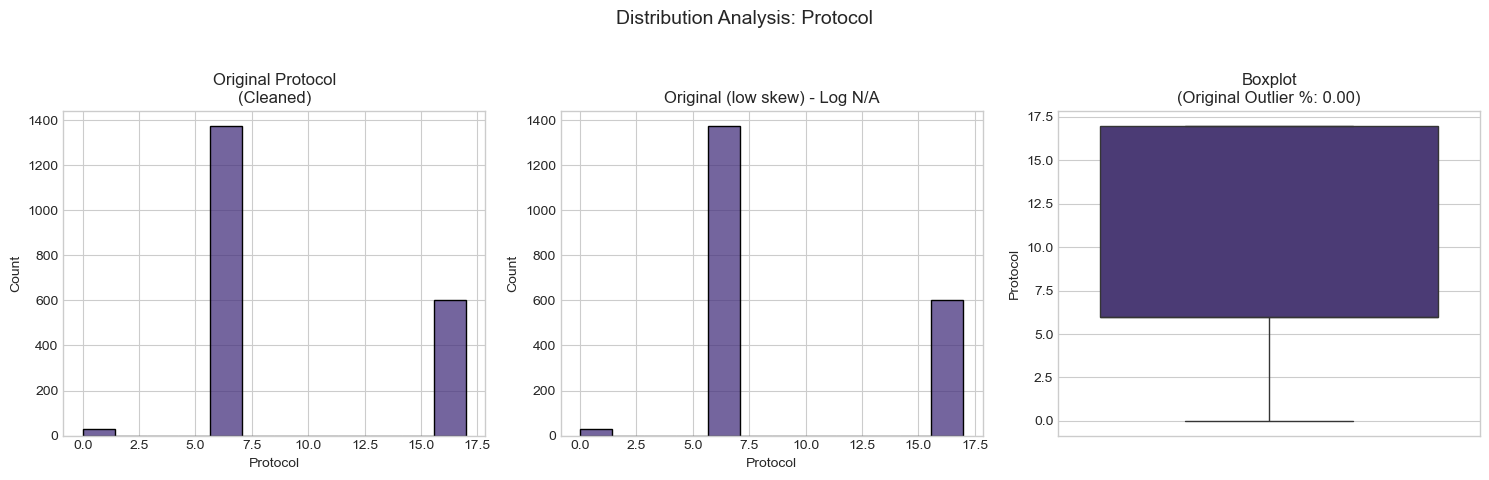

  Plots shown for 'Protocol'.
  -> Finished feature: 'Protocol' in 0.93 seconds.
[2/77] Starting analysis for feature: 'Flow Duration'...
  Calculating stats for 'Flow Duration'...
  Stats calculated for 'Flow Duration'.
  Plotting distributions for 'Flow Duration'...
    Original Data stats for 'Flow Duration' before plotting:
count    2.000000e+03
mean     1.813256e+07
std      3.609560e+07
min      0.000000e+00
25%      5.350000e+02
50%      9.489500e+04
75%      4.980808e+06
max      1.199910e+08
Name: Flow Duration, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Flow Duration'.
    Trying sns.histplot (original) for 'Flow Duration'...
    SUCCESS: sns.histplot (original) for 'Flow Duration'.
    Trying sns.histplot (log) for 'Flow Duration'...
    SUCCESS: sns.histplot (log) for 'Flow Duration'.
    Trying sns.boxplot for 'Flow Duration'...
    SUCCESS: sns.boxplot for 'Flow Duration'.


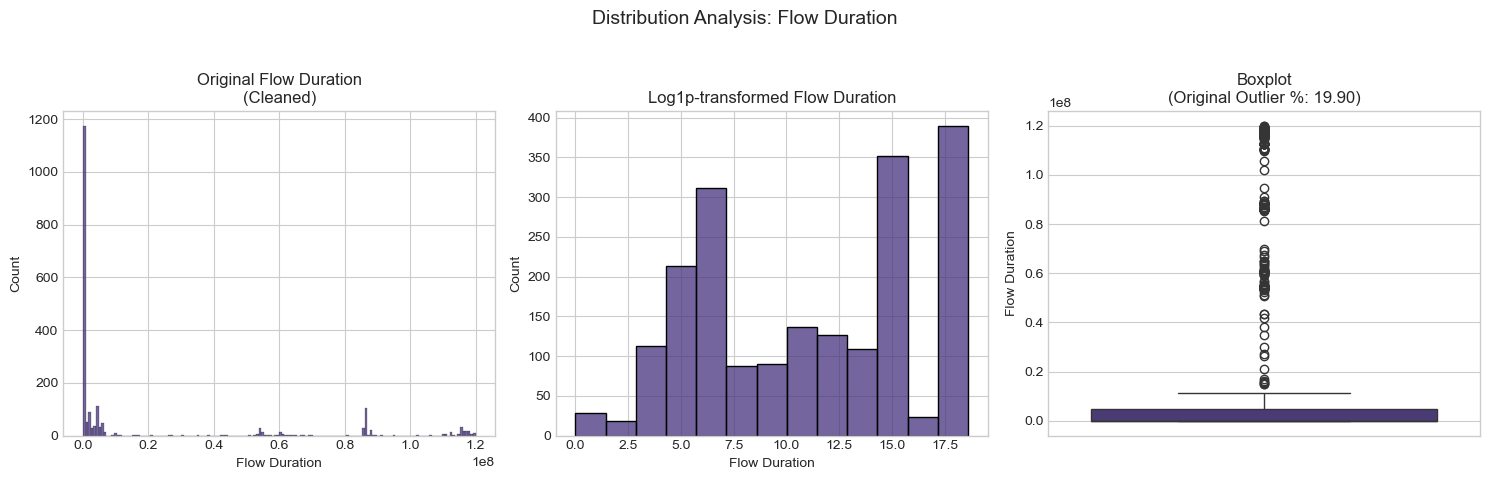

  Plots shown for 'Flow Duration'.
  -> Finished feature: 'Flow Duration' in 0.63 seconds.
[3/77] Starting analysis for feature: 'Tot Fwd Pkts'...
  Calculating stats for 'Tot Fwd Pkts'...
  Stats calculated for 'Tot Fwd Pkts'.
  -> Feature 'Tot Fwd Pkts' is very skewed. Skipping plotting to avoid hangs.
  -> Finished feature: 'Tot Fwd Pkts' in 0.01 seconds.
[4/77] Starting analysis for feature: 'Tot Bwd Pkts'...
  Calculating stats for 'Tot Bwd Pkts'...
  Stats calculated for 'Tot Bwd Pkts'.
  -> Feature 'Tot Bwd Pkts' is very skewed. Skipping plotting to avoid hangs.
  -> Finished feature: 'Tot Bwd Pkts' in 0.00 seconds.
[5/77] Starting analysis for feature: 'TotLen Fwd Pkts'...
  Calculating stats for 'TotLen Fwd Pkts'...
  Stats calculated for 'TotLen Fwd Pkts'.
  Plotting distributions for 'TotLen Fwd Pkts'...
    Original Data stats for 'TotLen Fwd Pkts' before plotting:
count     2000.00000
mean       365.47700
std        856.95317
min          0.00000
25%          0.00000
50%  

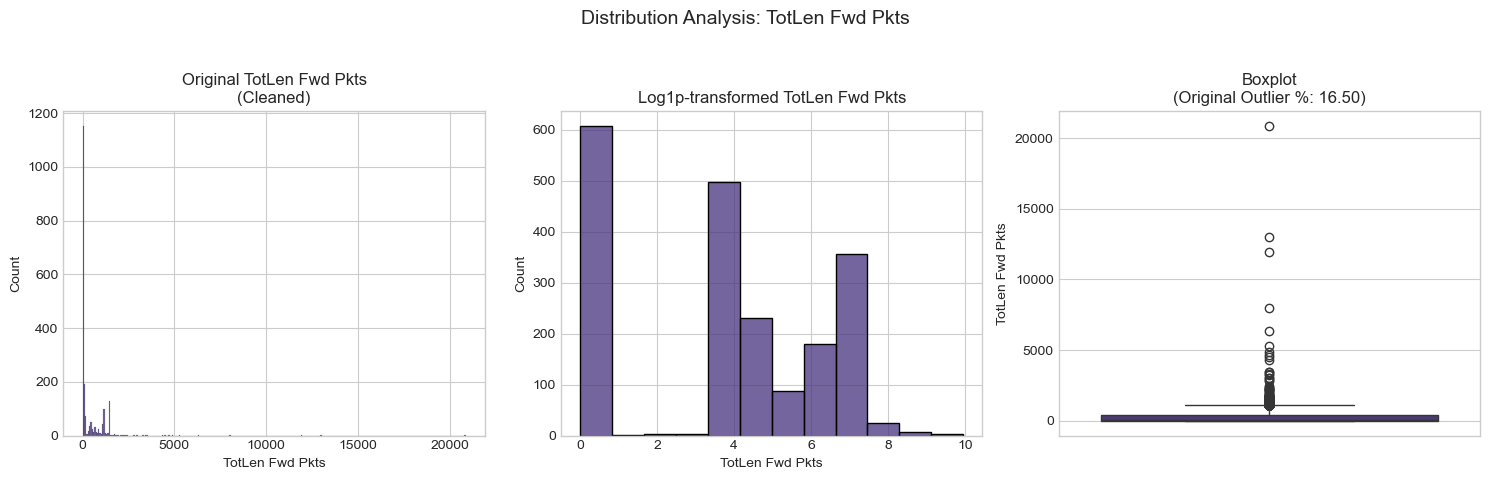

  Plots shown for 'TotLen Fwd Pkts'.
  -> Finished feature: 'TotLen Fwd Pkts' in 0.80 seconds.
[6/77] Starting analysis for feature: 'TotLen Bwd Pkts'...
  Calculating stats for 'TotLen Bwd Pkts'...
  Stats calculated for 'TotLen Bwd Pkts'.
  -> Feature 'TotLen Bwd Pkts' is very skewed. Skipping plotting to avoid hangs.
  -> Finished feature: 'TotLen Bwd Pkts' in 0.00 seconds.
[7/77] Starting analysis for feature: 'Fwd Pkt Len Max'...
  Calculating stats for 'Fwd Pkt Len Max'...
  Stats calculated for 'Fwd Pkt Len Max'.
  Plotting distributions for 'Fwd Pkt Len Max'...
    Original Data stats for 'Fwd Pkt Len Max' before plotting:
count    2000.00000
mean      176.01300
std       268.96197
min         0.00000
25%         0.00000
50%        41.00000
75%       187.25000
max      1397.00000
Name: Fwd Pkt Len Max, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Fwd Pkt Len Max'.
    Trying sns.histplot (original) for 'Fwd Pkt Le

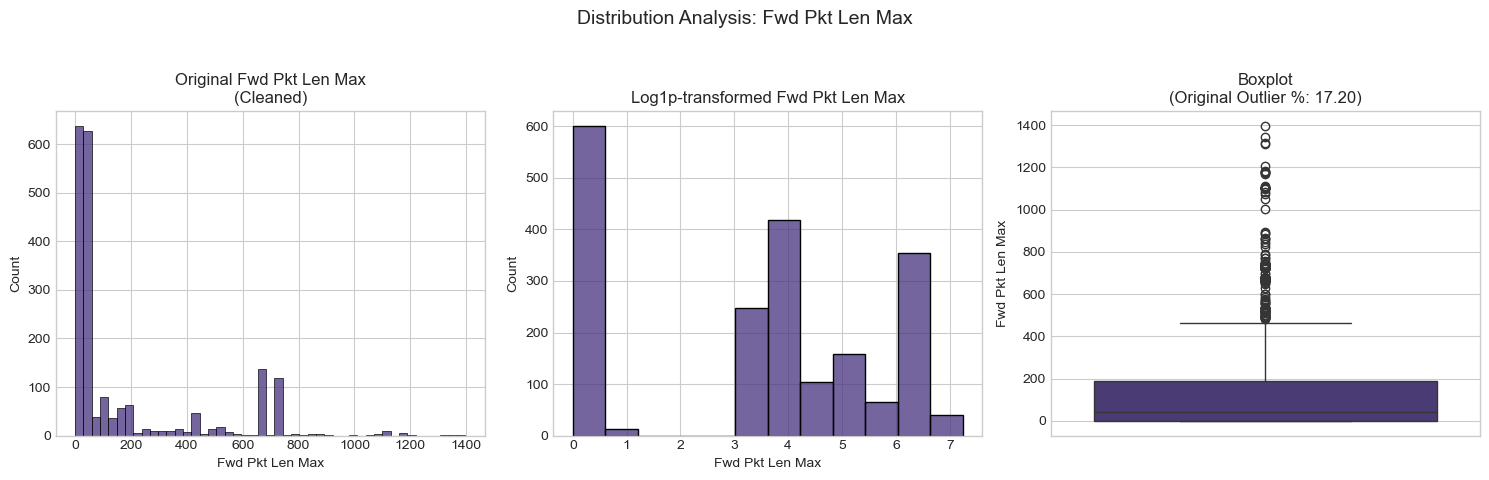

  Plots shown for 'Fwd Pkt Len Max'.
  -> Finished feature: 'Fwd Pkt Len Max' in 0.56 seconds.
[8/77] Starting analysis for feature: 'Fwd Pkt Len Min'...
  Calculating stats for 'Fwd Pkt Len Min'...
  Stats calculated for 'Fwd Pkt Len Min'.
  Plotting distributions for 'Fwd Pkt Len Min'...
    Original Data stats for 'Fwd Pkt Len Min' before plotting:
count    2000.000000
mean       13.030000
std        26.276574
min         0.000000
25%         0.000000
50%         0.000000
75%        33.000000
max       500.000000
Name: Fwd Pkt Len Min, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Fwd Pkt Len Min'.
    Trying sns.histplot (original) for 'Fwd Pkt Len Min'...
    SUCCESS: sns.histplot (original) for 'Fwd Pkt Len Min'.
    Trying sns.histplot (log) for 'Fwd Pkt Len Min'...
    SUCCESS: sns.histplot (log) for 'Fwd Pkt Len Min'.
    Trying sns.boxplot for 'Fwd Pkt Len Min'...
    SUCCESS: sns.boxplot for 'Fwd Pkt Len Min'.


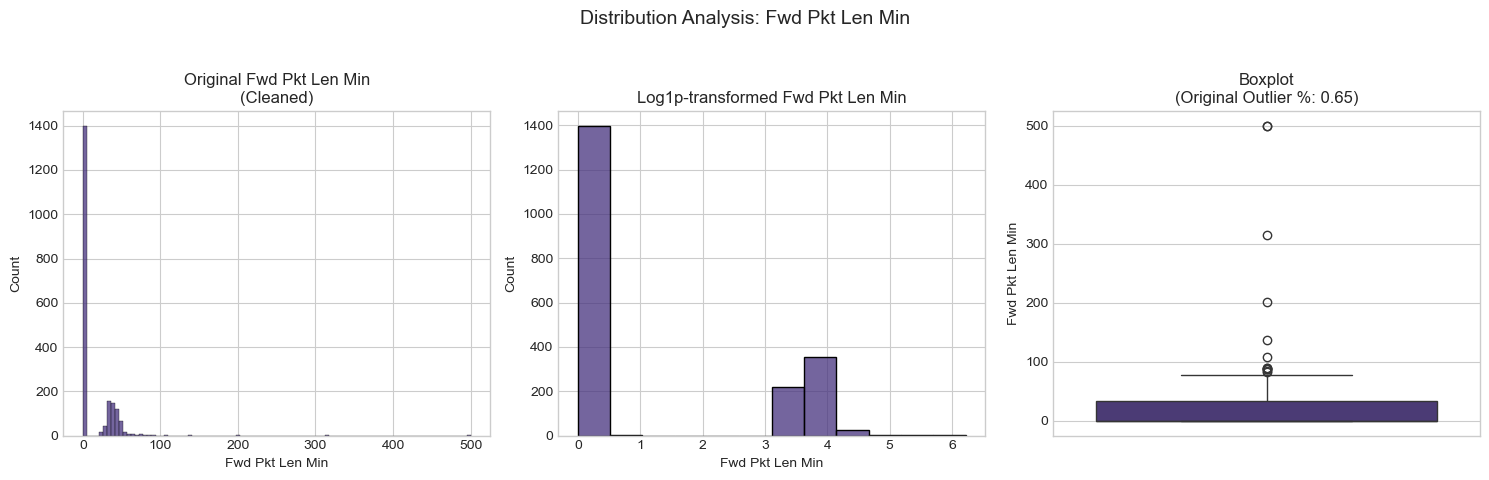

  Plots shown for 'Fwd Pkt Len Min'.
  -> Finished feature: 'Fwd Pkt Len Min' in 0.63 seconds.
[9/77] Starting analysis for feature: 'Fwd Pkt Len Mean'...
  Calculating stats for 'Fwd Pkt Len Mean'...
  Stats calculated for 'Fwd Pkt Len Mean'.
  Plotting distributions for 'Fwd Pkt Len Mean'...
    Original Data stats for 'Fwd Pkt Len Mean' before plotting:
count    2000.000000
mean       44.199116
std        49.296214
min         0.000000
25%         0.000000
50%        36.000000
75%        54.025000
max       581.333333
Name: Fwd Pkt Len Mean, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Fwd Pkt Len Mean'.
    Trying sns.histplot (original) for 'Fwd Pkt Len Mean'...
    SUCCESS: sns.histplot (original) for 'Fwd Pkt Len Mean'.
    Trying sns.histplot (log) for 'Fwd Pkt Len Mean'...
    SUCCESS: sns.histplot (log) for 'Fwd Pkt Len Mean'.
    Trying sns.boxplot for 'Fwd Pkt Len Mean'...
    SUCCESS: sns.boxplot for 'Fwd Pkt

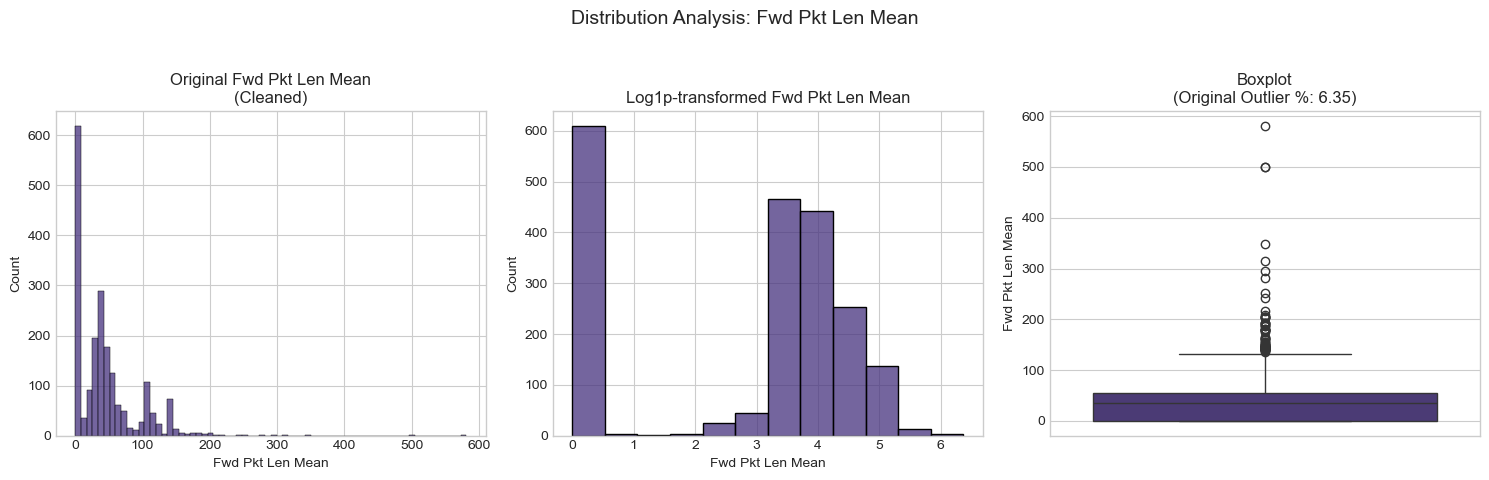

  Plots shown for 'Fwd Pkt Len Mean'.
  -> Finished feature: 'Fwd Pkt Len Mean' in 0.55 seconds.
[10/77] Starting analysis for feature: 'Fwd Pkt Len Std'...
  Calculating stats for 'Fwd Pkt Len Std'...
  Stats calculated for 'Fwd Pkt Len Std'.
  Plotting distributions for 'Fwd Pkt Len Std'...
    Original Data stats for 'Fwd Pkt Len Std' before plotting:
count    2000.000000
mean       53.589492
std        86.498879
min         0.000000
25%         0.000000
50%         0.000000
75%        85.671871
max       495.190738
Name: Fwd Pkt Len Std, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Fwd Pkt Len Std'.
    Trying sns.histplot (original) for 'Fwd Pkt Len Std'...
    SUCCESS: sns.histplot (original) for 'Fwd Pkt Len Std'.
    Trying sns.histplot (log) for 'Fwd Pkt Len Std'...
    SUCCESS: sns.histplot (log) for 'Fwd Pkt Len Std'.
    Trying sns.boxplot for 'Fwd Pkt Len Std'...
    SUCCESS: sns.boxplot for 'Fwd Pkt Len Std'

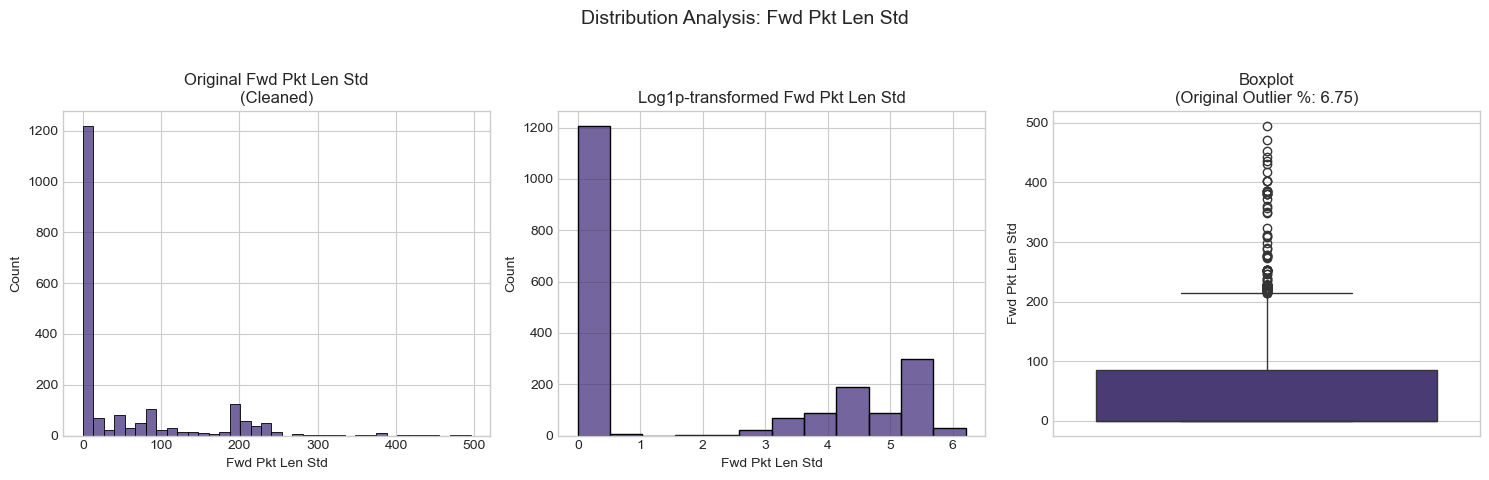

  Plots shown for 'Fwd Pkt Len Std'.
  -> Finished feature: 'Fwd Pkt Len Std' in 0.55 seconds.
[11/77] Starting analysis for feature: 'Bwd Pkt Len Max'...
  Calculating stats for 'Bwd Pkt Len Max'...
  Stats calculated for 'Bwd Pkt Len Max'.
  Plotting distributions for 'Bwd Pkt Len Max'...
    Original Data stats for 'Bwd Pkt Len Max' before plotting:
count    2000.000000
mean      360.370000
std       514.591768
min         0.000000
25%         0.000000
50%        93.500000
75%       488.000000
max      1460.000000
Name: Bwd Pkt Len Max, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Bwd Pkt Len Max'.
    Trying sns.histplot (original) for 'Bwd Pkt Len Max'...
    SUCCESS: sns.histplot (original) for 'Bwd Pkt Len Max'.
    Trying sns.histplot (log) for 'Bwd Pkt Len Max'...
    SUCCESS: sns.histplot (log) for 'Bwd Pkt Len Max'.
    Trying sns.boxplot for 'Bwd Pkt Len Max'...
    SUCCESS: sns.boxplot for 'Bwd Pkt Len Max'.


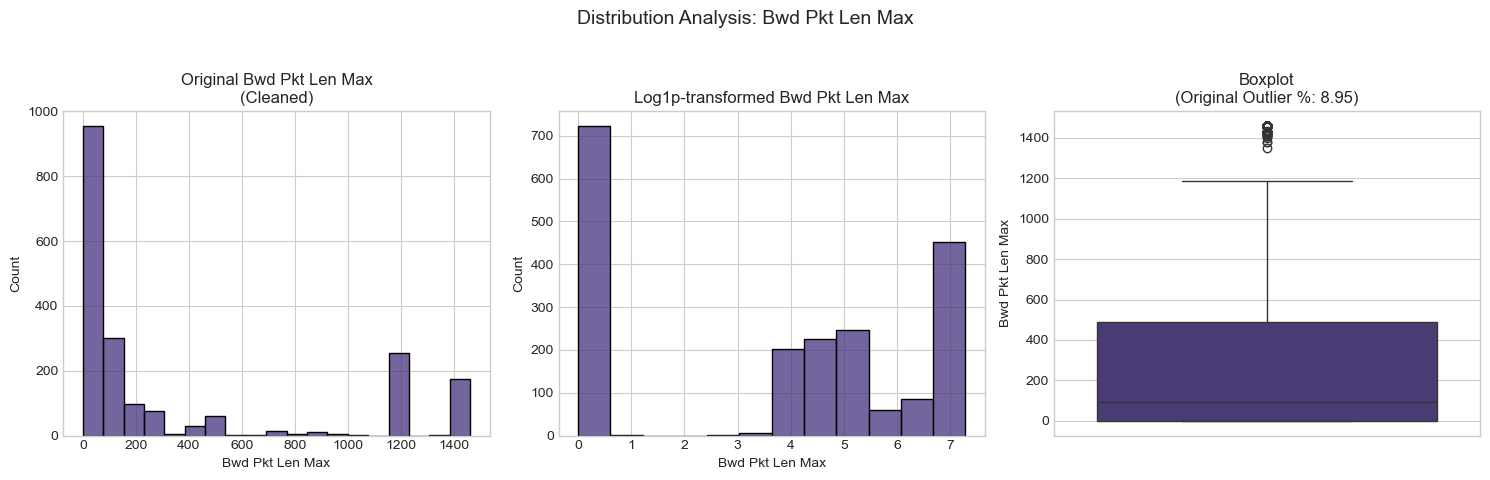

  Plots shown for 'Bwd Pkt Len Max'.
  -> Finished feature: 'Bwd Pkt Len Max' in 0.66 seconds.
[12/77] Starting analysis for feature: 'Bwd Pkt Len Min'...
  Calculating stats for 'Bwd Pkt Len Min'...
  Stats calculated for 'Bwd Pkt Len Min'.
  Plotting distributions for 'Bwd Pkt Len Min'...
    Original Data stats for 'Bwd Pkt Len Min' before plotting:
count    2000.000000
mean       30.004500
std        54.056198
min         0.000000
25%         0.000000
50%         0.000000
75%        56.000000
max       331.000000
Name: Bwd Pkt Len Min, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Bwd Pkt Len Min'.
    Trying sns.histplot (original) for 'Bwd Pkt Len Min'...
    SUCCESS: sns.histplot (original) for 'Bwd Pkt Len Min'.
    Trying sns.histplot (log) for 'Bwd Pkt Len Min'...
    SUCCESS: sns.histplot (log) for 'Bwd Pkt Len Min'.
    Trying sns.boxplot for 'Bwd Pkt Len Min'...
    SUCCESS: sns.boxplot for 'Bwd Pkt Len Min'.


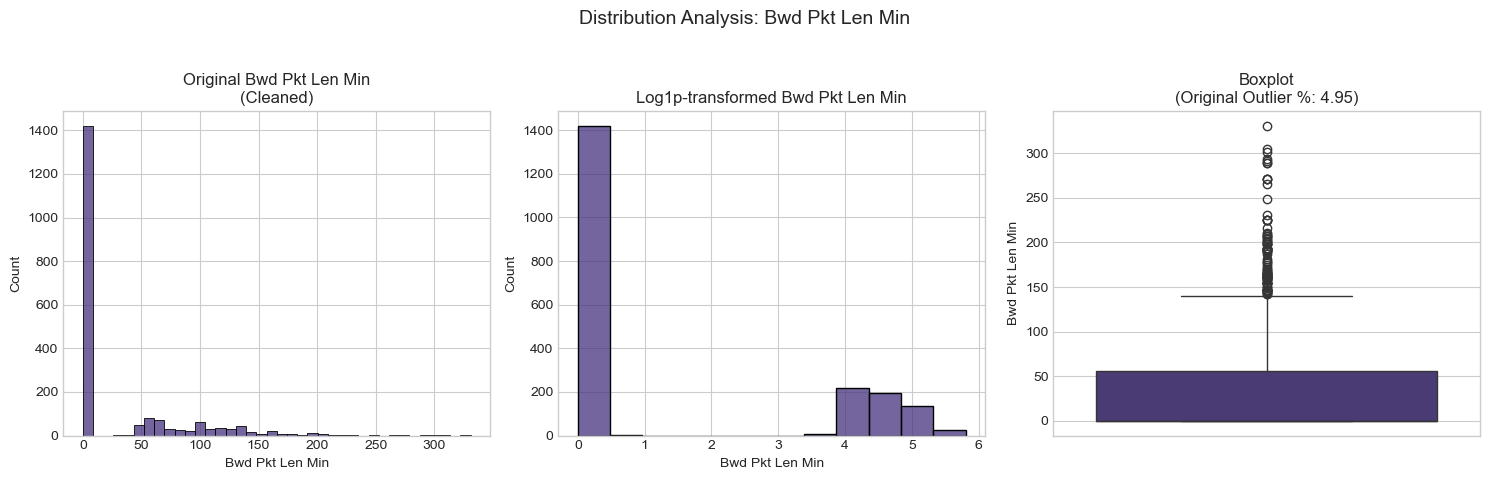

  Plots shown for 'Bwd Pkt Len Min'.
  -> Finished feature: 'Bwd Pkt Len Min' in 0.58 seconds.
[13/77] Starting analysis for feature: 'Bwd Pkt Len Mean'...
  Calculating stats for 'Bwd Pkt Len Mean'...
  Stats calculated for 'Bwd Pkt Len Mean'.
  Plotting distributions for 'Bwd Pkt Len Mean'...
    Original Data stats for 'Bwd Pkt Len Mean' before plotting:
count    2000.000000
mean      119.549367
std       180.800432
min         0.000000
25%         0.000000
50%        64.000000
75%       166.850000
max      1449.634291
Name: Bwd Pkt Len Mean, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Bwd Pkt Len Mean'.
    Trying sns.histplot (original) for 'Bwd Pkt Len Mean'...
    SUCCESS: sns.histplot (original) for 'Bwd Pkt Len Mean'.
    Trying sns.histplot (log) for 'Bwd Pkt Len Mean'...
    SUCCESS: sns.histplot (log) for 'Bwd Pkt Len Mean'.
    Trying sns.boxplot for 'Bwd Pkt Len Mean'...
    SUCCESS: sns.boxplot for 'Bwd Pk

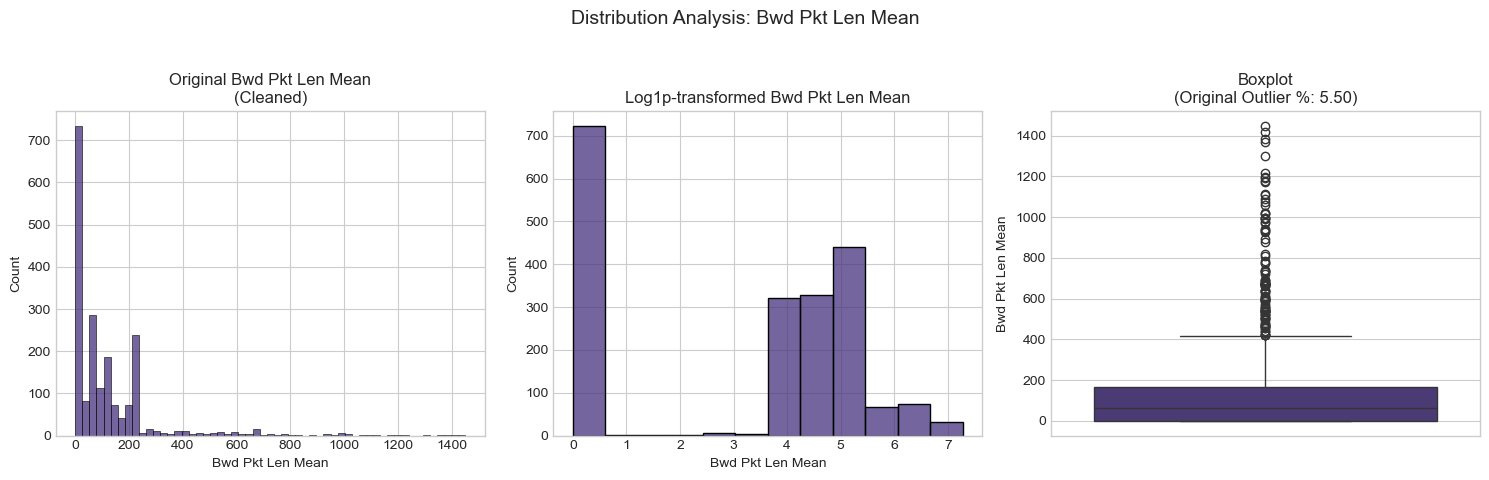

  Plots shown for 'Bwd Pkt Len Mean'.
  -> Finished feature: 'Bwd Pkt Len Mean' in 0.52 seconds.
[14/77] Starting analysis for feature: 'Bwd Pkt Len Std'...
  Calculating stats for 'Bwd Pkt Len Std'...
  Stats calculated for 'Bwd Pkt Len Std'.
  Plotting distributions for 'Bwd Pkt Len Std'...
    Original Data stats for 'Bwd Pkt Len Std' before plotting:
count    2000.000000
mean      127.881036
std       206.321894
min         0.000000
25%         0.000000
50%         0.000000
75%       244.000000
max       730.113142
Name: Bwd Pkt Len Std, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Bwd Pkt Len Std'.
    Trying sns.histplot (original) for 'Bwd Pkt Len Std'...
    SUCCESS: sns.histplot (original) for 'Bwd Pkt Len Std'.
    Trying sns.histplot (log) for 'Bwd Pkt Len Std'...
    SUCCESS: sns.histplot (log) for 'Bwd Pkt Len Std'.
    Trying sns.boxplot for 'Bwd Pkt Len Std'...
    SUCCESS: sns.boxplot for 'Bwd Pkt Len Std'

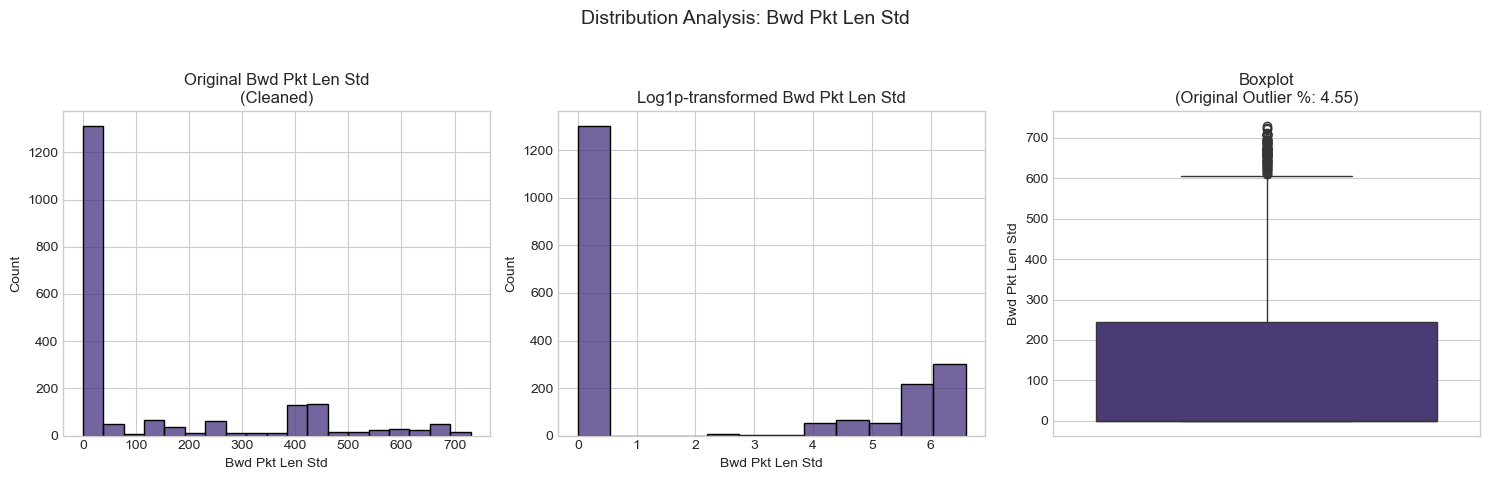

  Plots shown for 'Bwd Pkt Len Std'.
  -> Finished feature: 'Bwd Pkt Len Std' in 0.53 seconds.
[15/77] Starting analysis for feature: 'Flow Byts/s'...
  Calculating stats for 'Flow Byts/s'...
  Stats calculated for 'Flow Byts/s'.
  Plotting distributions for 'Flow Byts/s'...
    Original Data stats for 'Flow Byts/s' before plotting:
count    2.000000e+03
mean     3.143242e+05
std      3.968036e+06
min      0.000000e+00
25%      0.000000e+00
50%      7.881881e+02
75%      4.870767e+04
max      8.900000e+07
Name: Flow Byts/s, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Flow Byts/s'.
    Trying sns.histplot (original) for 'Flow Byts/s'...
    SUCCESS: sns.histplot (original) for 'Flow Byts/s'.
    Trying sns.histplot (log) for 'Flow Byts/s'...
    SUCCESS: sns.histplot (log) for 'Flow Byts/s'.
    Trying sns.boxplot for 'Flow Byts/s'...
    SUCCESS: sns.boxplot for 'Flow Byts/s'.


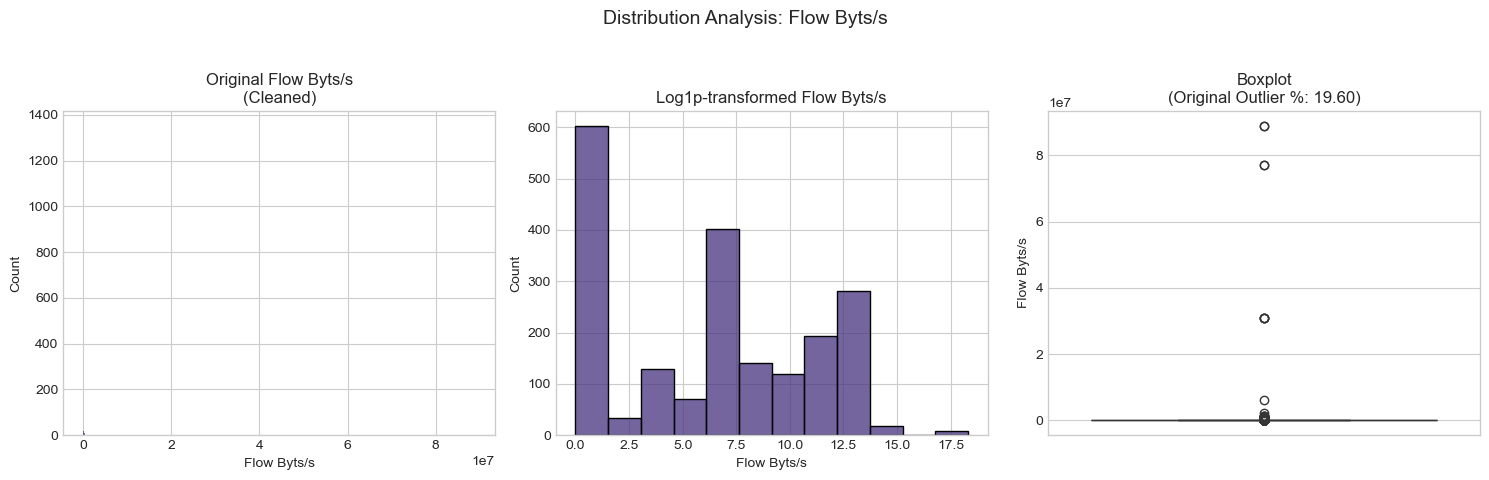

  Plots shown for 'Flow Byts/s'.
  -> Finished feature: 'Flow Byts/s' in 10.86 seconds.
[16/77] Starting analysis for feature: 'Flow Pkts/s'...
  Calculating stats for 'Flow Pkts/s'...
  Stats calculated for 'Flow Pkts/s'.
  Plotting distributions for 'Flow Pkts/s'...
    Original Data stats for 'Flow Pkts/s' before plotting:
count    2.000000e+03
mean     2.597472e+04
std      2.109876e+05
min      2.259628e-02
25%      3.132975e+00
50%      4.636445e+01
75%      5.118368e+03
max      3.000000e+06
Name: Flow Pkts/s, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Flow Pkts/s'.
    Trying sns.histplot (original) for 'Flow Pkts/s'...
    SUCCESS: sns.histplot (original) for 'Flow Pkts/s'.
    Trying sns.histplot (log) for 'Flow Pkts/s'...
    SUCCESS: sns.histplot (log) for 'Flow Pkts/s'.
    Trying sns.boxplot for 'Flow Pkts/s'...
    SUCCESS: sns.boxplot for 'Flow Pkts/s'.


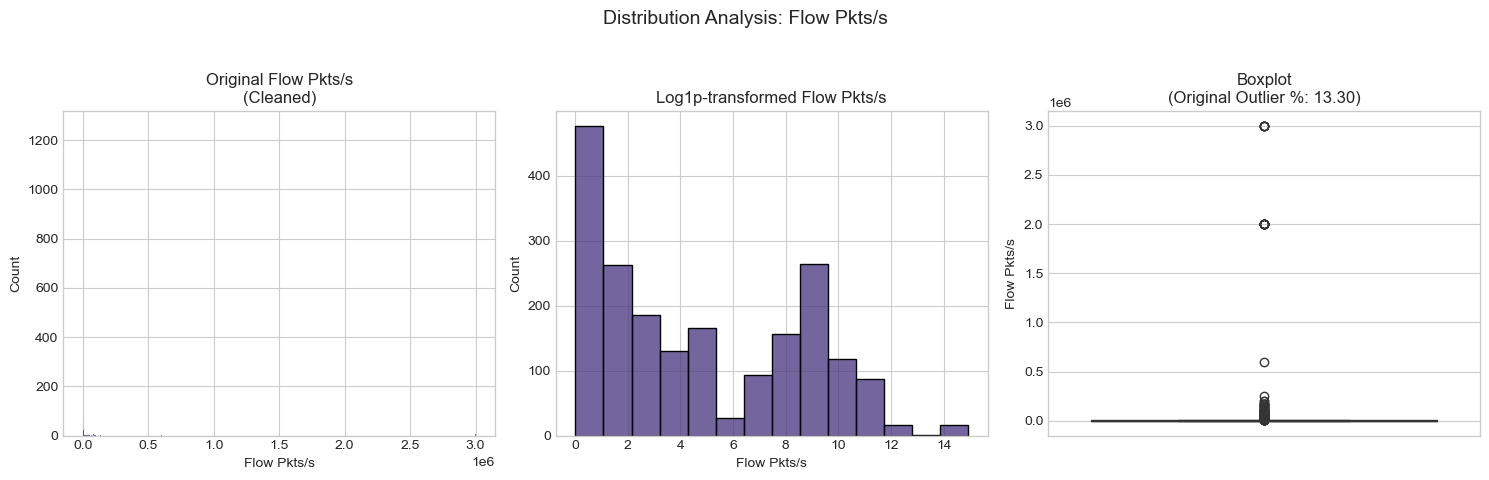

  Plots shown for 'Flow Pkts/s'.
  -> Finished feature: 'Flow Pkts/s' in 4.27 seconds.
[17/77] Starting analysis for feature: 'Flow IAT Mean'...
  Calculating stats for 'Flow IAT Mean'...
  Stats calculated for 'Flow IAT Mean'.
  Plotting distributions for 'Flow IAT Mean'...
    Original Data stats for 'Flow IAT Mean' before plotting:
count    2.000000e+03
mean     9.122226e+06
std      2.479236e+07
min      0.000000e+00
25%      3.507500e+02
50%      2.823300e+04
75%      4.189838e+05
max      8.851016e+07
Name: Flow IAT Mean, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Flow IAT Mean'.
    Trying sns.histplot (original) for 'Flow IAT Mean'...
    SUCCESS: sns.histplot (original) for 'Flow IAT Mean'.
    Trying sns.histplot (log) for 'Flow IAT Mean'...
    SUCCESS: sns.histplot (log) for 'Flow IAT Mean'.
    Trying sns.boxplot for 'Flow IAT Mean'...
    SUCCESS: sns.boxplot for 'Flow IAT Mean'.


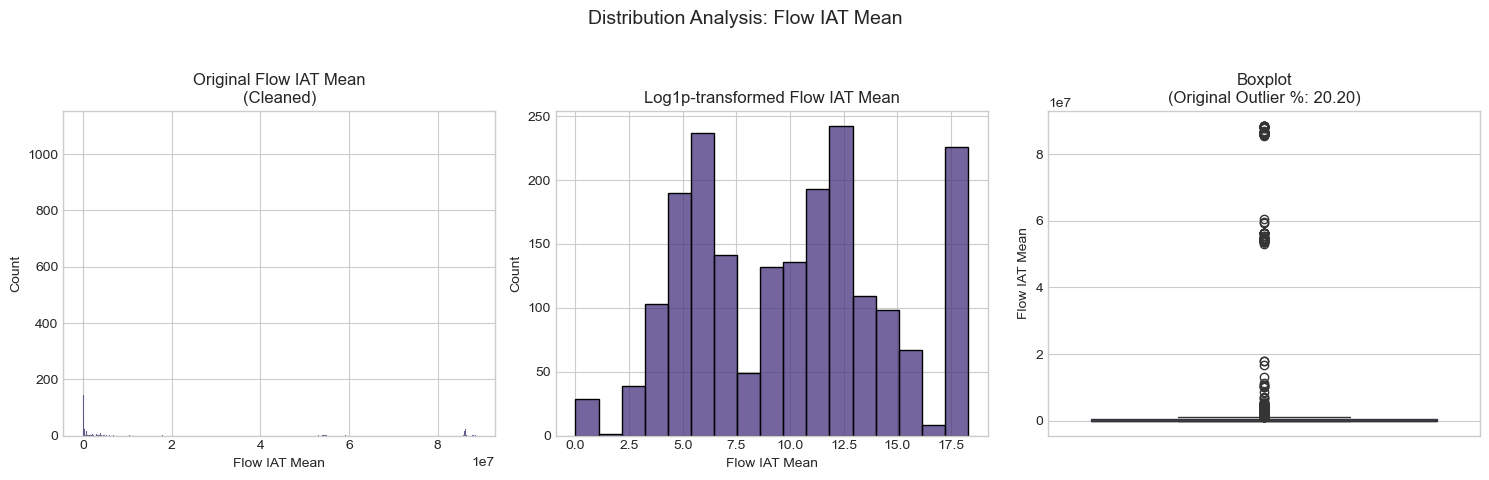

  Plots shown for 'Flow IAT Mean'.
  -> Finished feature: 'Flow IAT Mean' in 3.00 seconds.
[18/77] Starting analysis for feature: 'Flow IAT Std'...
  Calculating stats for 'Flow IAT Std'...
  Stats calculated for 'Flow IAT Std'.
  Plotting distributions for 'Flow IAT Std'...
    Original Data stats for 'Flow IAT Std' before plotting:
count    2.000000e+03
mean     7.959989e+05
std      2.792110e+06
min      0.000000e+00
25%      0.000000e+00
50%      6.231857e+00
75%      2.406826e+05
max      4.448323e+07
Name: Flow IAT Std, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Flow IAT Std'.
    Trying sns.histplot (original) for 'Flow IAT Std'...
    SUCCESS: sns.histplot (original) for 'Flow IAT Std'.
    Trying sns.histplot (log) for 'Flow IAT Std'...
    SUCCESS: sns.histplot (log) for 'Flow IAT Std'.
    Trying sns.boxplot for 'Flow IAT Std'...
    SUCCESS: sns.boxplot for 'Flow IAT Std'.


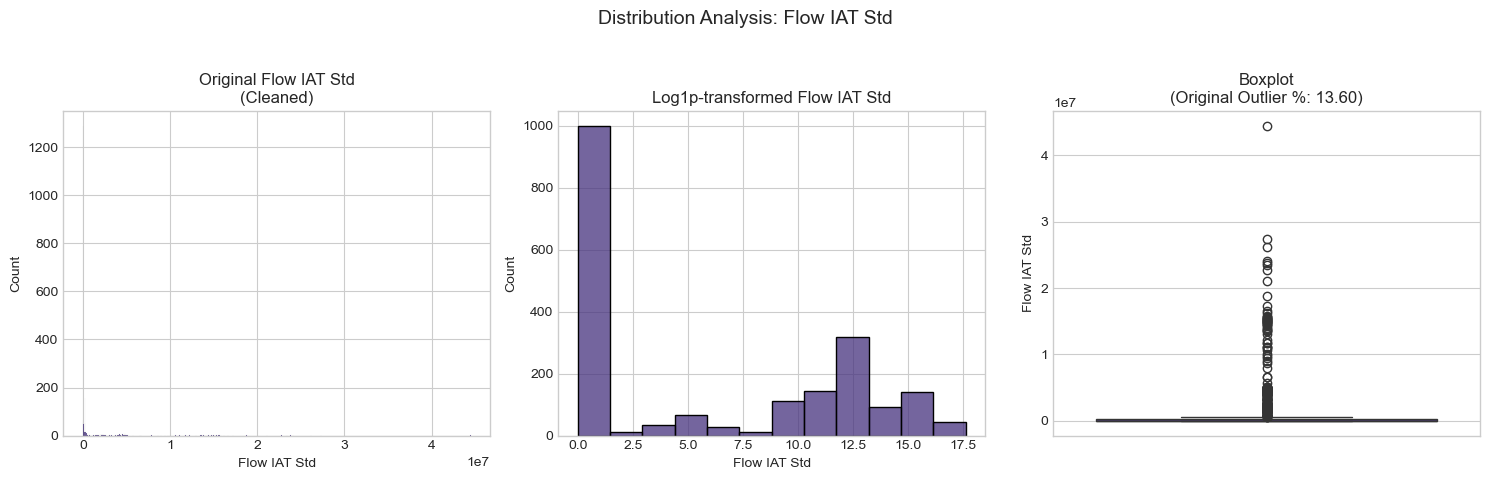

  Plots shown for 'Flow IAT Std'.
  -> Finished feature: 'Flow IAT Std' in 2.01 seconds.
[19/77] Starting analysis for feature: 'Flow IAT Max'...
  Calculating stats for 'Flow IAT Max'...
  Stats calculated for 'Flow IAT Max'.
  Plotting distributions for 'Flow IAT Max'...
    Original Data stats for 'Flow IAT Max' before plotting:
count    2.000000e+03
mean     1.144112e+07
std      2.604252e+07
min      0.000000e+00
25%      3.685000e+02
50%      6.849550e+04
75%      3.000758e+06
max      1.177533e+08
Name: Flow IAT Max, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Flow IAT Max'.
    Trying sns.histplot (original) for 'Flow IAT Max'...
    SUCCESS: sns.histplot (original) for 'Flow IAT Max'.
    Trying sns.histplot (log) for 'Flow IAT Max'...
    SUCCESS: sns.histplot (log) for 'Flow IAT Max'.
    Trying sns.boxplot for 'Flow IAT Max'...
    SUCCESS: sns.boxplot for 'Flow IAT Max'.


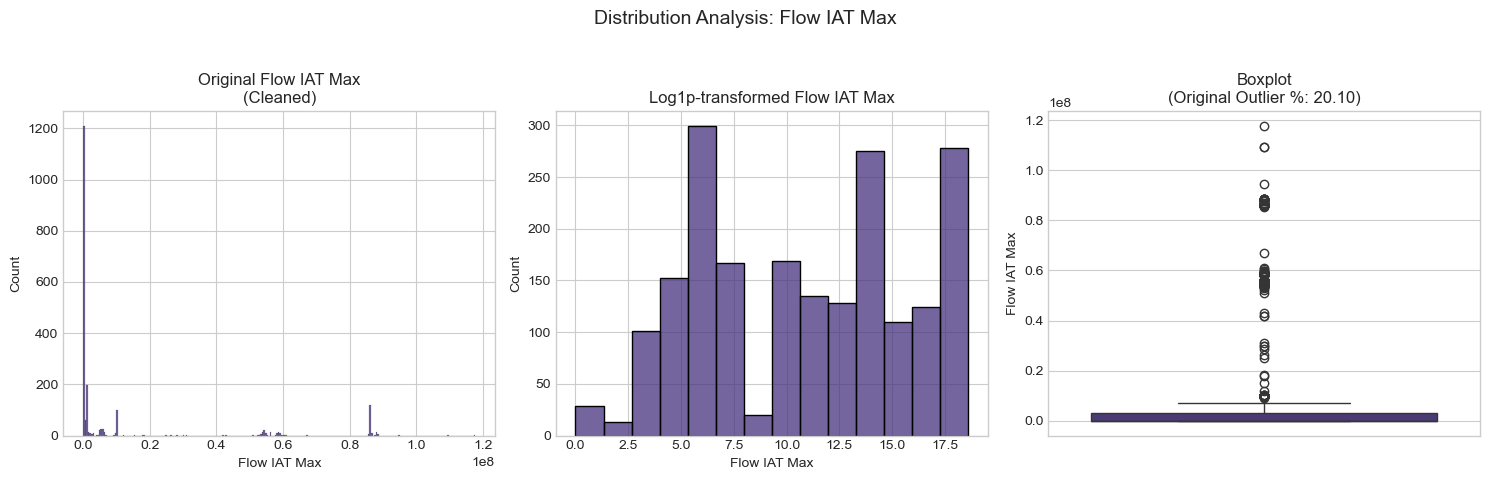

  Plots shown for 'Flow IAT Max'.
  -> Finished feature: 'Flow IAT Max' in 0.82 seconds.
[20/77] Starting analysis for feature: 'Flow IAT Min'...
  Calculating stats for 'Flow IAT Min'...
  Stats calculated for 'Flow IAT Min'.
  Plotting distributions for 'Flow IAT Min'...
    Original Data stats for 'Flow IAT Min' before plotting:
count    2.000000e+03
mean     8.757509e+06
std      2.488838e+07
min      0.000000e+00
25%      1.900000e+01
50%      8.100000e+01
75%      1.029750e+03
max      8.851016e+07
Name: Flow IAT Min, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Flow IAT Min'.
    Trying sns.histplot (original) for 'Flow IAT Min'...
    SUCCESS: sns.histplot (original) for 'Flow IAT Min'.
    Trying sns.histplot (log) for 'Flow IAT Min'...
    SUCCESS: sns.histplot (log) for 'Flow IAT Min'.
    Trying sns.boxplot for 'Flow IAT Min'...
    SUCCESS: sns.boxplot for 'Flow IAT Min'.


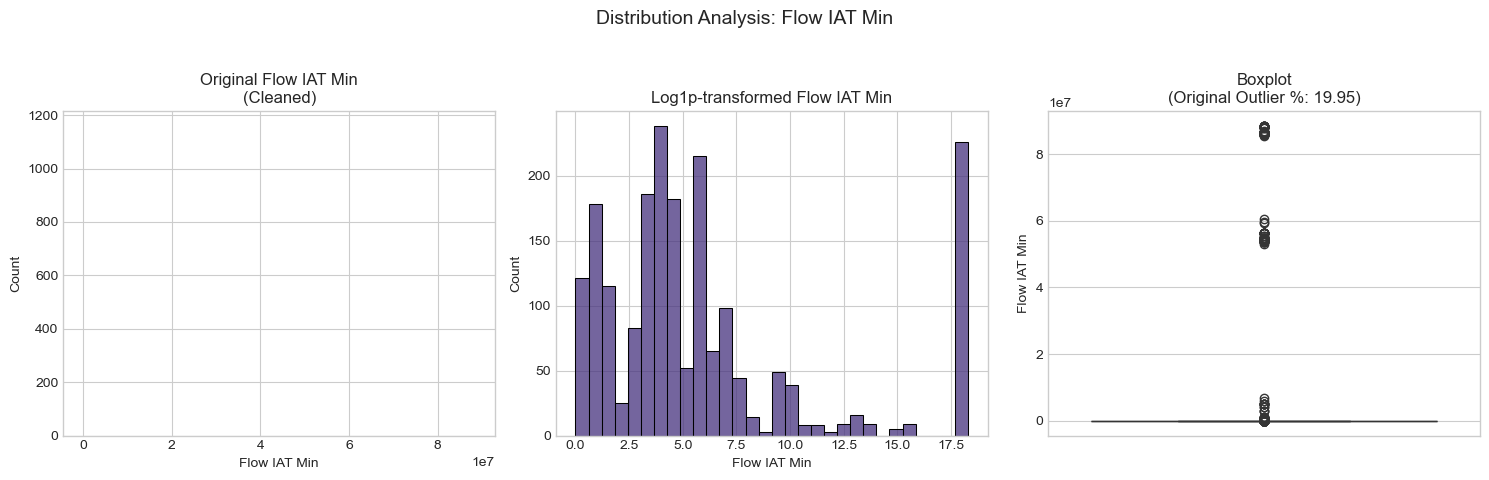

  Plots shown for 'Flow IAT Min'.
  -> Finished feature: 'Flow IAT Min' in 495.55 seconds.
[21/77] Starting analysis for feature: 'Fwd IAT Tot'...
  Calculating stats for 'Fwd IAT Tot'...
  Stats calculated for 'Fwd IAT Tot'.
  Plotting distributions for 'Fwd IAT Tot'...
    Original Data stats for 'Fwd IAT Tot' before plotting:
count    2.000000e+03
mean     1.779948e+07
std      3.612532e+07
min      0.000000e+00
25%      0.000000e+00
50%      5.281150e+04
75%      4.061462e+06
max      1.199792e+08
Name: Fwd IAT Tot, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Fwd IAT Tot'.
    Trying sns.histplot (original) for 'Fwd IAT Tot'...
    SUCCESS: sns.histplot (original) for 'Fwd IAT Tot'.
    Trying sns.histplot (log) for 'Fwd IAT Tot'...
    SUCCESS: sns.histplot (log) for 'Fwd IAT Tot'.
    Trying sns.boxplot for 'Fwd IAT Tot'...
    SUCCESS: sns.boxplot for 'Fwd IAT Tot'.


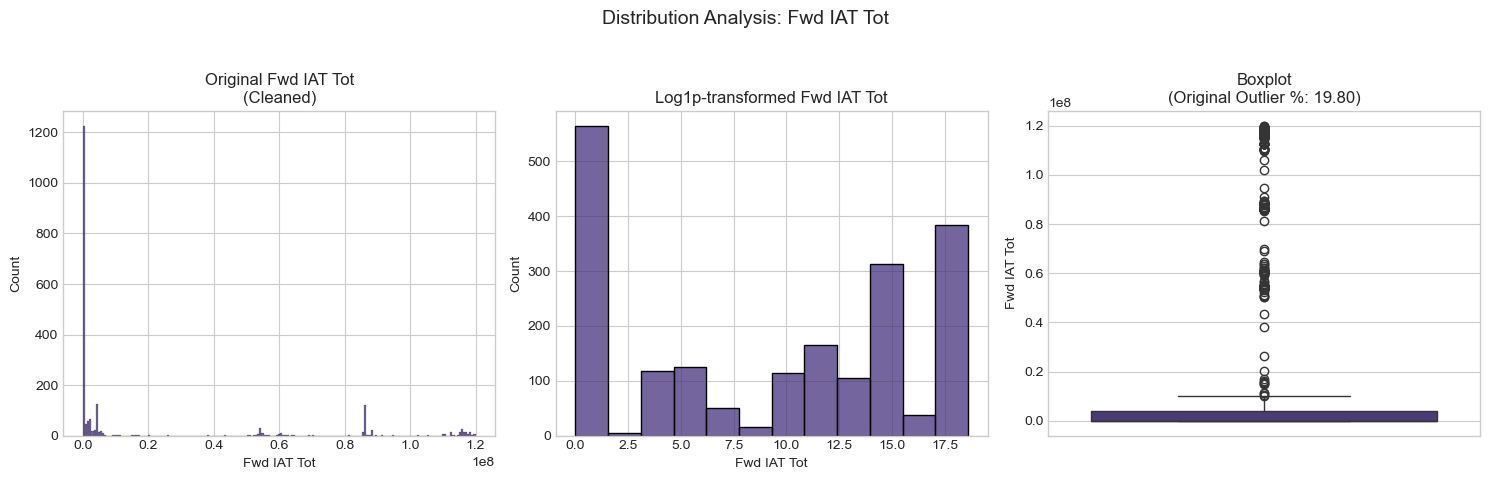

  Plots shown for 'Fwd IAT Tot'.
  -> Finished feature: 'Fwd IAT Tot' in 0.61 seconds.
[22/77] Starting analysis for feature: 'Fwd IAT Mean'...
  Calculating stats for 'Fwd IAT Mean'...
  Stats calculated for 'Fwd IAT Mean'.
  Plotting distributions for 'Fwd IAT Mean'...
    Original Data stats for 'Fwd IAT Mean' before plotting:
count    2.000000e+03
mean     9.371357e+06
std      2.476005e+07
min      0.000000e+00
25%      0.000000e+00
50%      2.532979e+04
75%      3.709550e+05
max      8.851016e+07
Name: Fwd IAT Mean, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Fwd IAT Mean'.
    Trying sns.histplot (original) for 'Fwd IAT Mean'...
    SUCCESS: sns.histplot (original) for 'Fwd IAT Mean'.
    Trying sns.histplot (log) for 'Fwd IAT Mean'...
    SUCCESS: sns.histplot (log) for 'Fwd IAT Mean'.
    Trying sns.boxplot for 'Fwd IAT Mean'...
    SUCCESS: sns.boxplot for 'Fwd IAT Mean'.


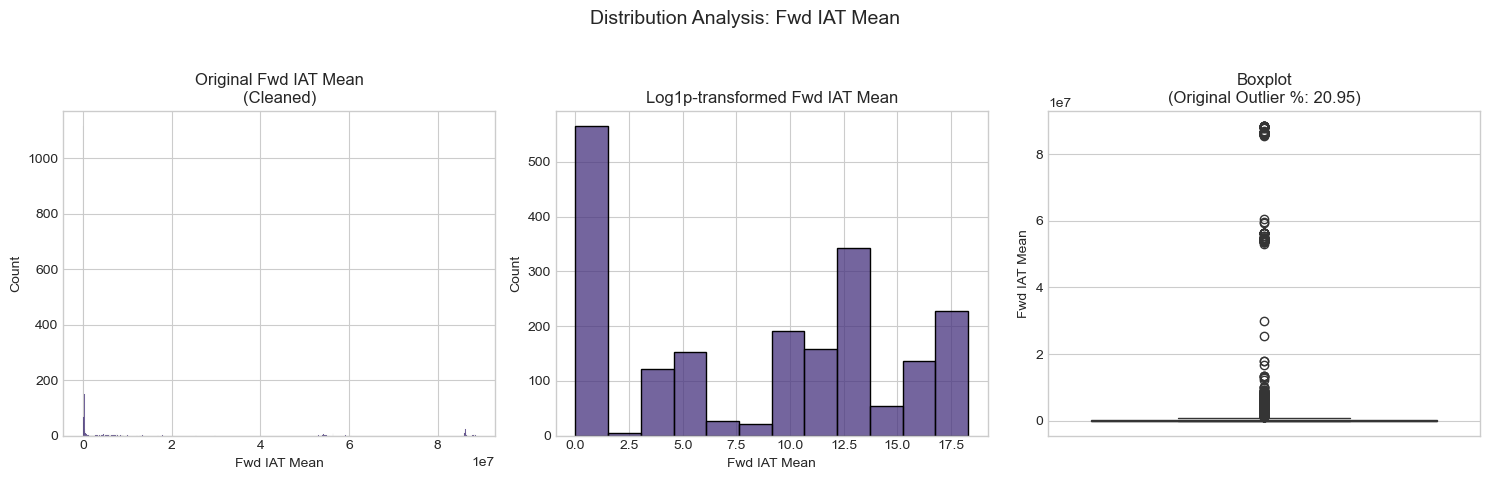

  Plots shown for 'Fwd IAT Mean'.
  -> Finished feature: 'Fwd IAT Mean' in 1.56 seconds.
[23/77] Starting analysis for feature: 'Fwd IAT Std'...
  Calculating stats for 'Fwd IAT Std'...
  Stats calculated for 'Fwd IAT Std'.
  Plotting distributions for 'Fwd IAT Std'...
    Original Data stats for 'Fwd IAT Std' before plotting:
count    2.000000e+03
mean     8.624196e+05
std      3.437279e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.402511e+05
max      4.448323e+07
Name: Fwd IAT Std, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Fwd IAT Std'.
    Trying sns.histplot (original) for 'Fwd IAT Std'...
    SUCCESS: sns.histplot (original) for 'Fwd IAT Std'.
    Trying sns.histplot (log) for 'Fwd IAT Std'...
    SUCCESS: sns.histplot (log) for 'Fwd IAT Std'.
    Trying sns.boxplot for 'Fwd IAT Std'...
    SUCCESS: sns.boxplot for 'Fwd IAT Std'.


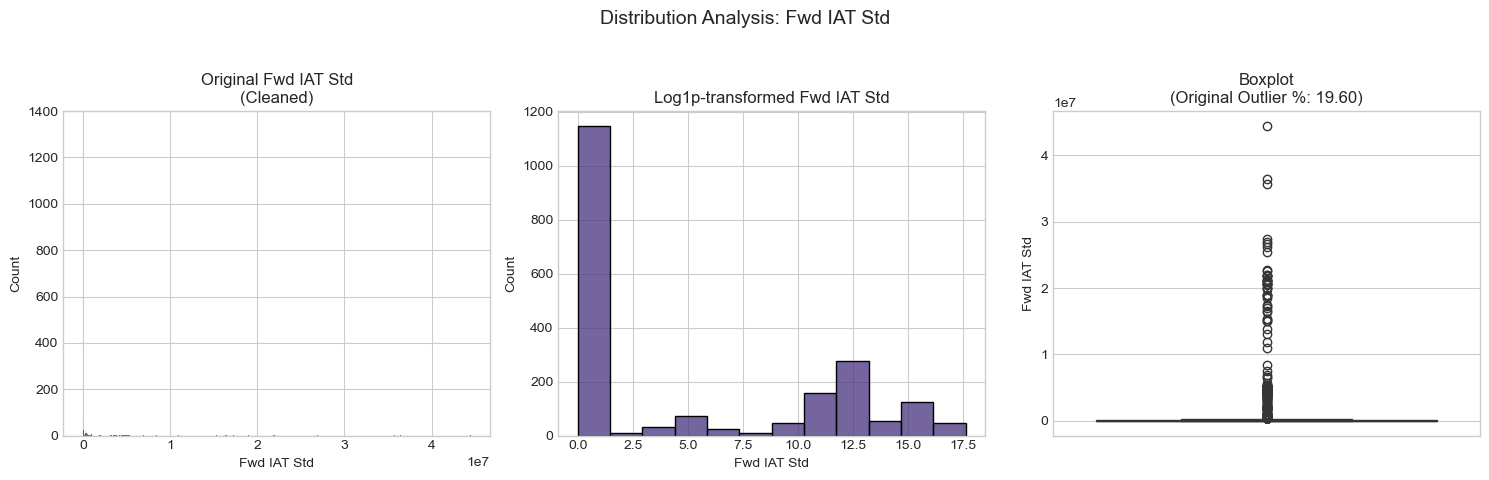

  Plots shown for 'Fwd IAT Std'.
  -> Finished feature: 'Fwd IAT Std' in 3.10 seconds.
[24/77] Starting analysis for feature: 'Fwd IAT Max'...
  Calculating stats for 'Fwd IAT Max'...
  Stats calculated for 'Fwd IAT Max'.
  Plotting distributions for 'Fwd IAT Max'...
    Original Data stats for 'Fwd IAT Max' before plotting:
count    2.000000e+03
mean     1.119095e+07
std      2.605134e+07
min      0.000000e+00
25%      0.000000e+00
50%      4.384750e+04
75%      1.314475e+06
max      1.177533e+08
Name: Fwd IAT Max, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Fwd IAT Max'.
    Trying sns.histplot (original) for 'Fwd IAT Max'...
    SUCCESS: sns.histplot (original) for 'Fwd IAT Max'.
    Trying sns.histplot (log) for 'Fwd IAT Max'...
    SUCCESS: sns.histplot (log) for 'Fwd IAT Max'.
    Trying sns.boxplot for 'Fwd IAT Max'...
    SUCCESS: sns.boxplot for 'Fwd IAT Max'.


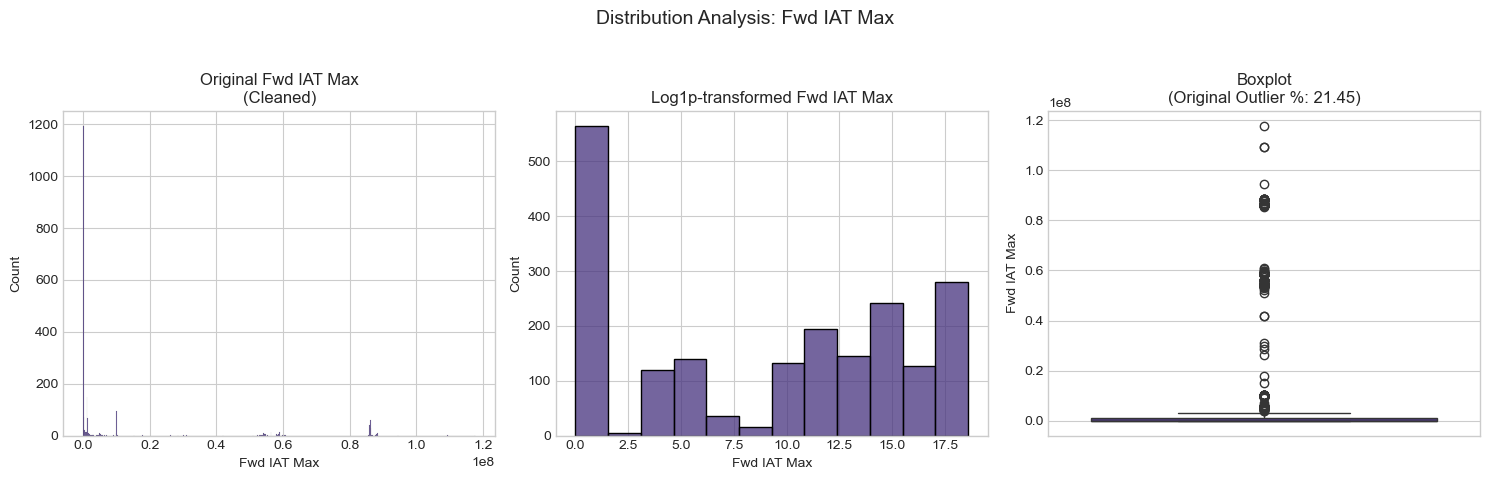

  Plots shown for 'Fwd IAT Max'.
  -> Finished feature: 'Fwd IAT Max' in 1.23 seconds.
[25/77] Starting analysis for feature: 'Fwd IAT Min'...
  Calculating stats for 'Fwd IAT Min'...
  Stats calculated for 'Fwd IAT Min'.
  Plotting distributions for 'Fwd IAT Min'...
    Original Data stats for 'Fwd IAT Min' before plotting:
count    2.000000e+03
mean     8.793176e+06
std      2.488726e+07
min      0.000000e+00
25%      0.000000e+00
50%      8.300000e+01
75%      1.985900e+04
max      8.851016e+07
Name: Fwd IAT Min, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Fwd IAT Min'.
    Trying sns.histplot (original) for 'Fwd IAT Min'...
    SUCCESS: sns.histplot (original) for 'Fwd IAT Min'.
    Trying sns.histplot (log) for 'Fwd IAT Min'...
    SUCCESS: sns.histplot (log) for 'Fwd IAT Min'.
    Trying sns.boxplot for 'Fwd IAT Min'...
    SUCCESS: sns.boxplot for 'Fwd IAT Min'.


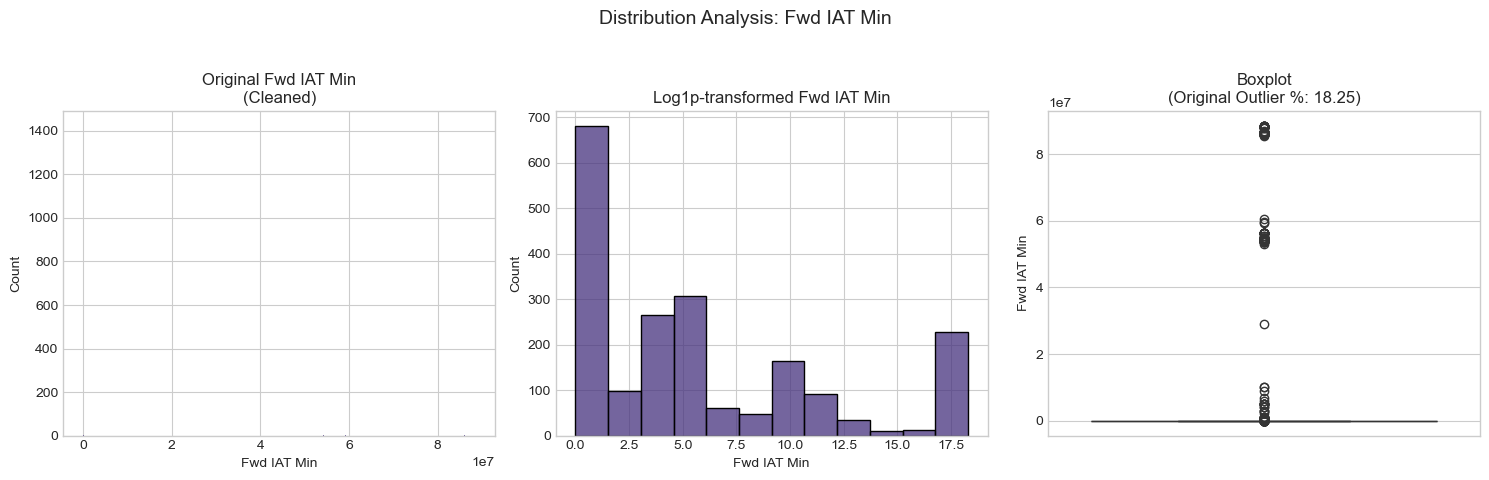

  Plots shown for 'Fwd IAT Min'.
  -> Finished feature: 'Fwd IAT Min' in 21.73 seconds.
[26/77] Starting analysis for feature: 'Bwd IAT Tot'...
  Calculating stats for 'Bwd IAT Tot'...
  Stats calculated for 'Bwd IAT Tot'.
  Plotting distributions for 'Bwd IAT Tot'...
    Original Data stats for 'Bwd IAT Tot' before plotting:
count    2.000000e+03
mean     7.963194e+06
std      2.649459e+07
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.156619e+06
max      1.199792e+08
Name: Bwd IAT Tot, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Bwd IAT Tot'.
    Trying sns.histplot (original) for 'Bwd IAT Tot'...
    SUCCESS: sns.histplot (original) for 'Bwd IAT Tot'.
    Trying sns.histplot (log) for 'Bwd IAT Tot'...
    SUCCESS: sns.histplot (log) for 'Bwd IAT Tot'.
    Trying sns.boxplot for 'Bwd IAT Tot'...
    SUCCESS: sns.boxplot for 'Bwd IAT Tot'.


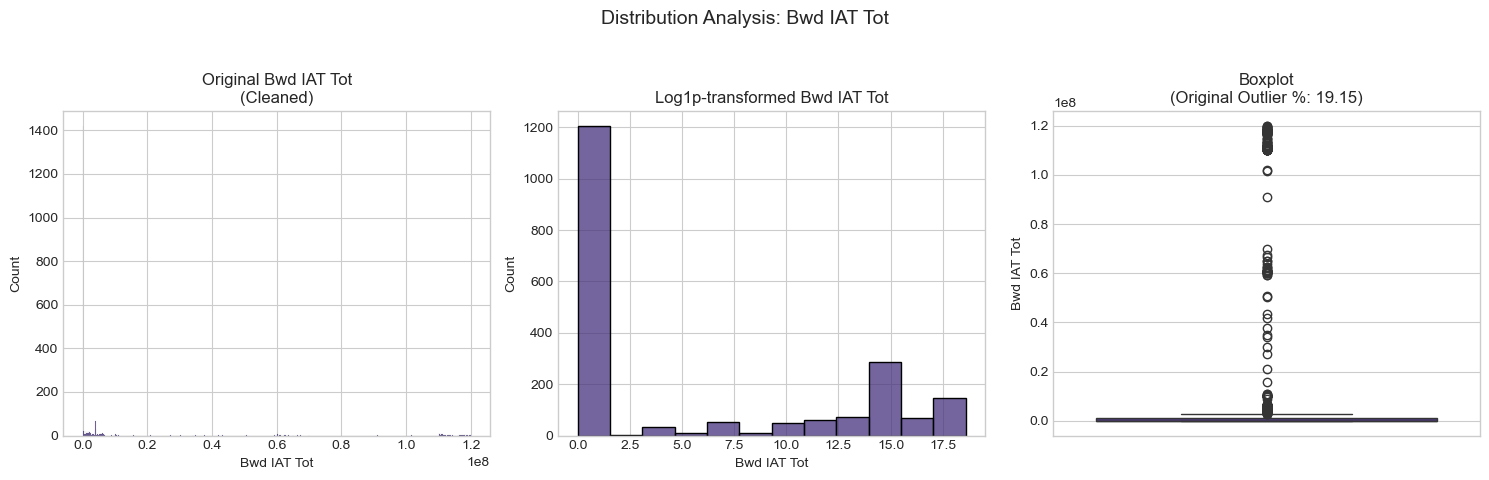

  Plots shown for 'Bwd IAT Tot'.
  -> Finished feature: 'Bwd IAT Tot' in 1.34 seconds.
[27/77] Starting analysis for feature: 'Bwd IAT Mean'...
  Calculating stats for 'Bwd IAT Mean'...
  Stats calculated for 'Bwd IAT Mean'.
  Plotting distributions for 'Bwd IAT Mean'...
    Original Data stats for 'Bwd IAT Mean' before plotting:
count    2.000000e+03
mean     5.888101e+05
std      1.906236e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.412827e+05
max      2.979584e+07
Name: Bwd IAT Mean, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Bwd IAT Mean'.
    Trying sns.histplot (original) for 'Bwd IAT Mean'...
    SUCCESS: sns.histplot (original) for 'Bwd IAT Mean'.
    Trying sns.histplot (log) for 'Bwd IAT Mean'...
    SUCCESS: sns.histplot (log) for 'Bwd IAT Mean'.
    Trying sns.boxplot for 'Bwd IAT Mean'...
    SUCCESS: sns.boxplot for 'Bwd IAT Mean'.


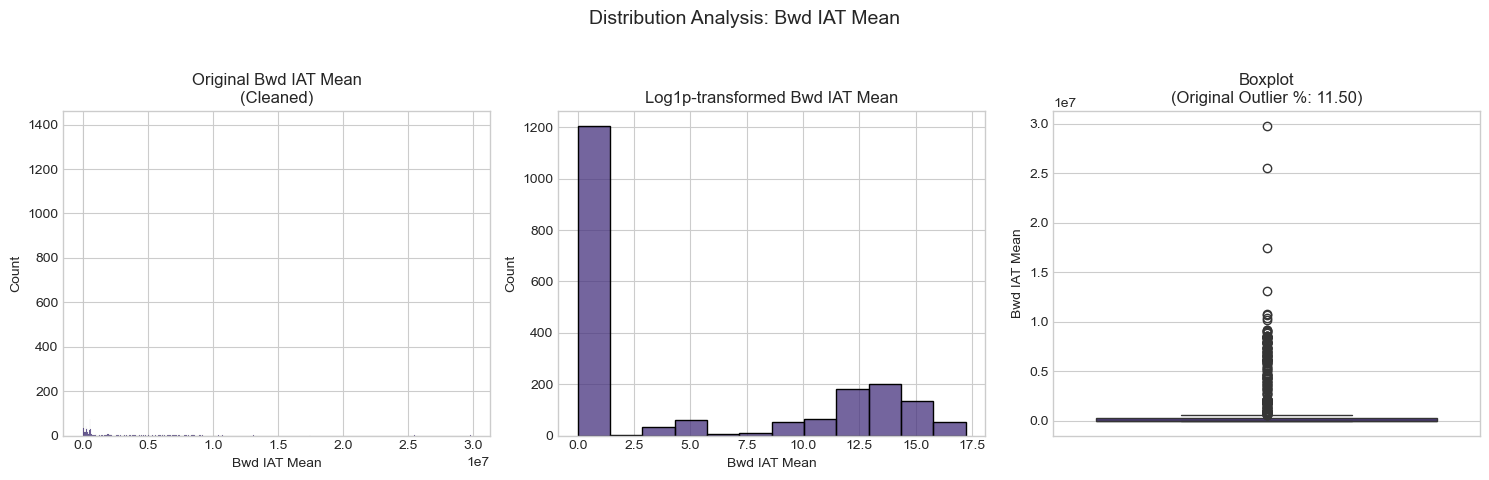

  Plots shown for 'Bwd IAT Mean'.
  -> Finished feature: 'Bwd IAT Mean' in 1.48 seconds.
[28/77] Starting analysis for feature: 'Bwd IAT Std'...
  Calculating stats for 'Bwd IAT Std'...
  Stats calculated for 'Bwd IAT Std'.
  Plotting distributions for 'Bwd IAT Std'...
    Original Data stats for 'Bwd IAT Std' before plotting:
count    2.000000e+03
mean     7.385673e+05
std      2.648833e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.624899e+05
max      2.590495e+07
Name: Bwd IAT Std, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Bwd IAT Std'.
    Trying sns.histplot (original) for 'Bwd IAT Std'...
    SUCCESS: sns.histplot (original) for 'Bwd IAT Std'.
    Trying sns.histplot (log) for 'Bwd IAT Std'...
    SUCCESS: sns.histplot (log) for 'Bwd IAT Std'.
    Trying sns.boxplot for 'Bwd IAT Std'...
    SUCCESS: sns.boxplot for 'Bwd IAT Std'.


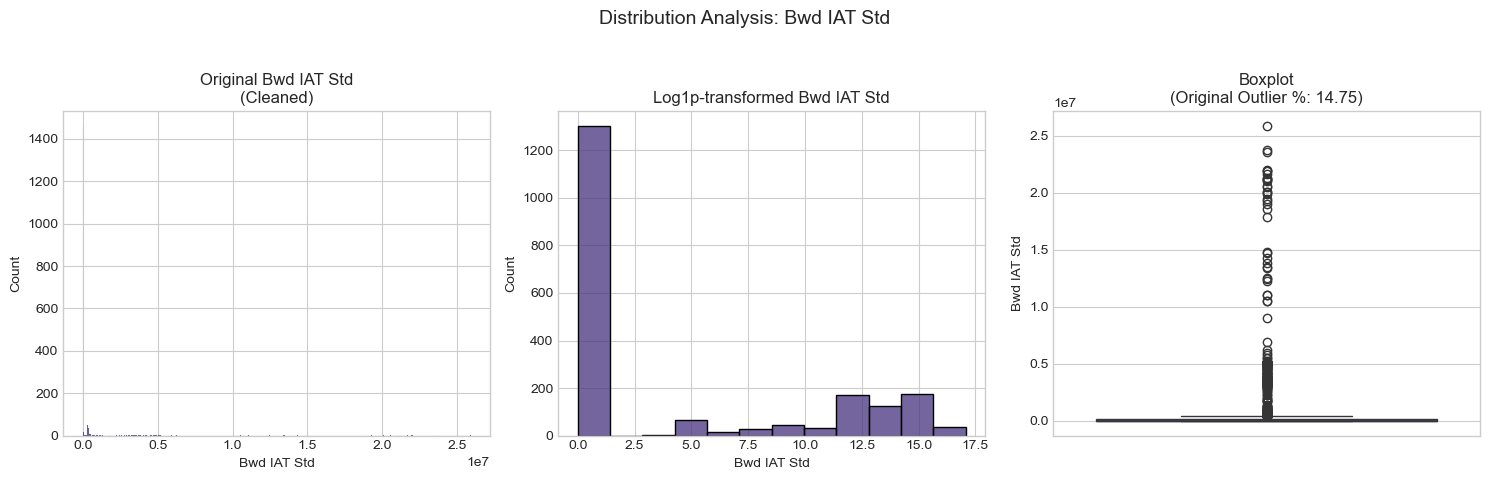

  Plots shown for 'Bwd IAT Std'.
  -> Finished feature: 'Bwd IAT Std' in 1.79 seconds.
[29/77] Starting analysis for feature: 'Bwd IAT Max'...
  Calculating stats for 'Bwd IAT Max'...
  Stats calculated for 'Bwd IAT Max'.
  Plotting distributions for 'Bwd IAT Max'...
    Original Data stats for 'Bwd IAT Max' before plotting:
count    2.000000e+03
mean     2.144264e+06
std      8.449300e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.637252e+05
max      6.714049e+07
Name: Bwd IAT Max, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Bwd IAT Max'.
    Trying sns.histplot (original) for 'Bwd IAT Max'...
    SUCCESS: sns.histplot (original) for 'Bwd IAT Max'.
    Trying sns.histplot (log) for 'Bwd IAT Max'...
    SUCCESS: sns.histplot (log) for 'Bwd IAT Max'.
    Trying sns.boxplot for 'Bwd IAT Max'...
    SUCCESS: sns.boxplot for 'Bwd IAT Max'.


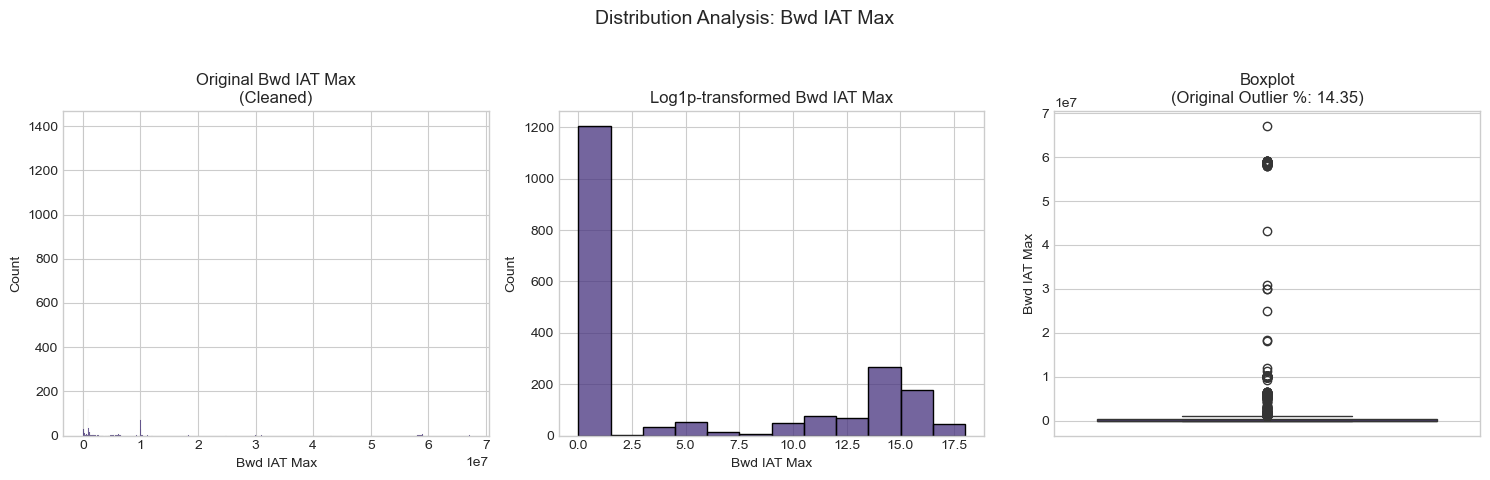

  Plots shown for 'Bwd IAT Max'.
  -> Finished feature: 'Bwd IAT Max' in 1.15 seconds.
[30/77] Starting analysis for feature: 'Bwd IAT Min'...
  Calculating stats for 'Bwd IAT Min'...
  Stats calculated for 'Bwd IAT Min'.
  -> Feature 'Bwd IAT Min' is very skewed. Skipping plotting to avoid hangs.
  -> Finished feature: 'Bwd IAT Min' in 0.00 seconds.
[31/77] Starting analysis for feature: 'Fwd PSH Flags'...
  Calculating stats for 'Fwd PSH Flags'...
  Stats calculated for 'Fwd PSH Flags'.
  Plotting distributions for 'Fwd PSH Flags'...
    Original Data stats for 'Fwd PSH Flags' before plotting:
count    2000.000000
mean        0.037500
std         0.190031
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: Fwd PSH Flags, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Fwd PSH Flags'.
    Trying sns.histplot (original) for 'Fwd PSH Flags'...
    SUCCESS: sns.histplo

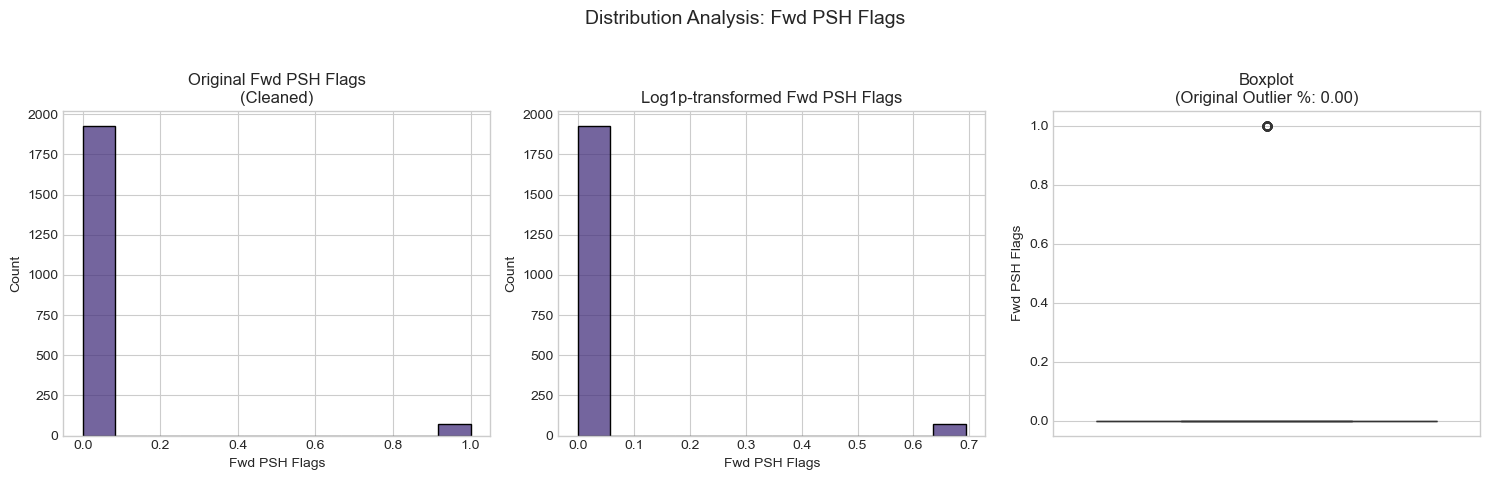

  Plots shown for 'Fwd PSH Flags'.
  -> Finished feature: 'Fwd PSH Flags' in 0.46 seconds.
[32/77] Starting analysis for feature: 'Bwd PSH Flags'...
  Calculating stats for 'Bwd PSH Flags'...
  Stats calculated for 'Bwd PSH Flags'.
  Plotting distributions for 'Bwd PSH Flags'...
    Original Data stats for 'Bwd PSH Flags' before plotting:
count    2000.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: Bwd PSH Flags, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Bwd PSH Flags'.
    Trying sns.histplot (original) for 'Bwd PSH Flags'...
    SUCCESS: sns.histplot (original) for 'Bwd PSH Flags'.
    Trying sns.histplot (log) for 'Bwd PSH Flags'...
    SUCCESS: sns.histplot (log) for 'Bwd PSH Flags'.
    Trying sns.boxplot for 'Bwd PSH Flags'...
    SUCCESS: sns.boxplot for 'Bwd PSH Flags'.


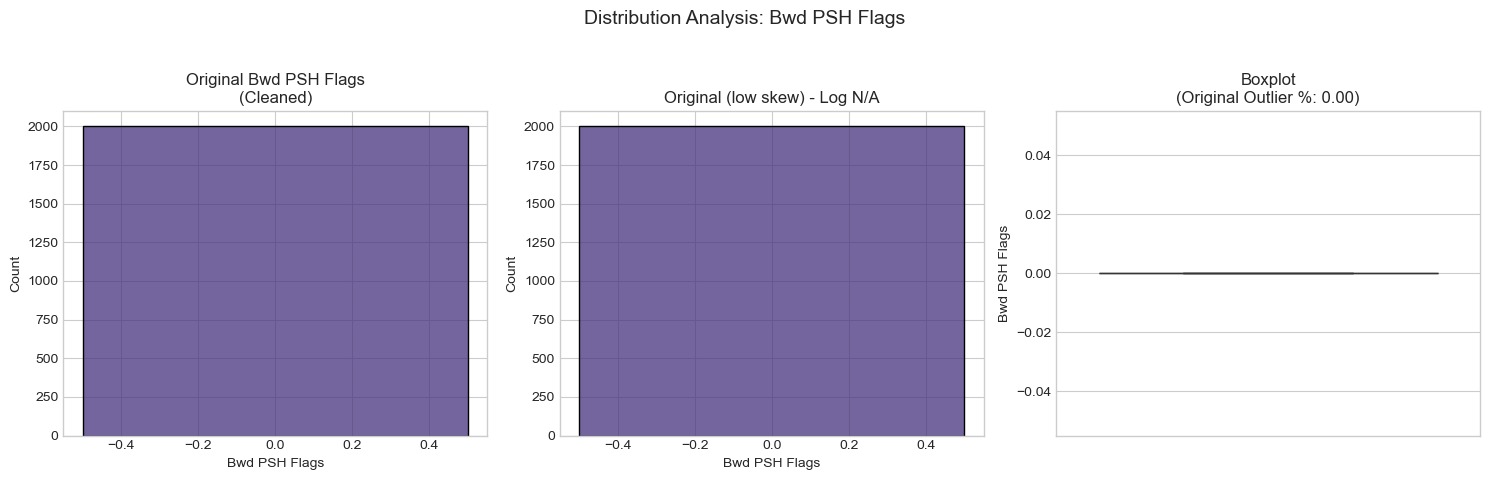

  Plots shown for 'Bwd PSH Flags'.
  -> Finished feature: 'Bwd PSH Flags' in 0.41 seconds.
[33/77] Starting analysis for feature: 'Fwd URG Flags'...
  Calculating stats for 'Fwd URG Flags'...
  Stats calculated for 'Fwd URG Flags'.
  Plotting distributions for 'Fwd URG Flags'...
    Original Data stats for 'Fwd URG Flags' before plotting:
count    2000.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: Fwd URG Flags, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Fwd URG Flags'.
    Trying sns.histplot (original) for 'Fwd URG Flags'...
    SUCCESS: sns.histplot (original) for 'Fwd URG Flags'.
    Trying sns.histplot (log) for 'Fwd URG Flags'...
    SUCCESS: sns.histplot (log) for 'Fwd URG Flags'.
    Trying sns.boxplot for 'Fwd URG Flags'...
    SUCCESS: sns.boxplot for 'Fwd URG Flags'.


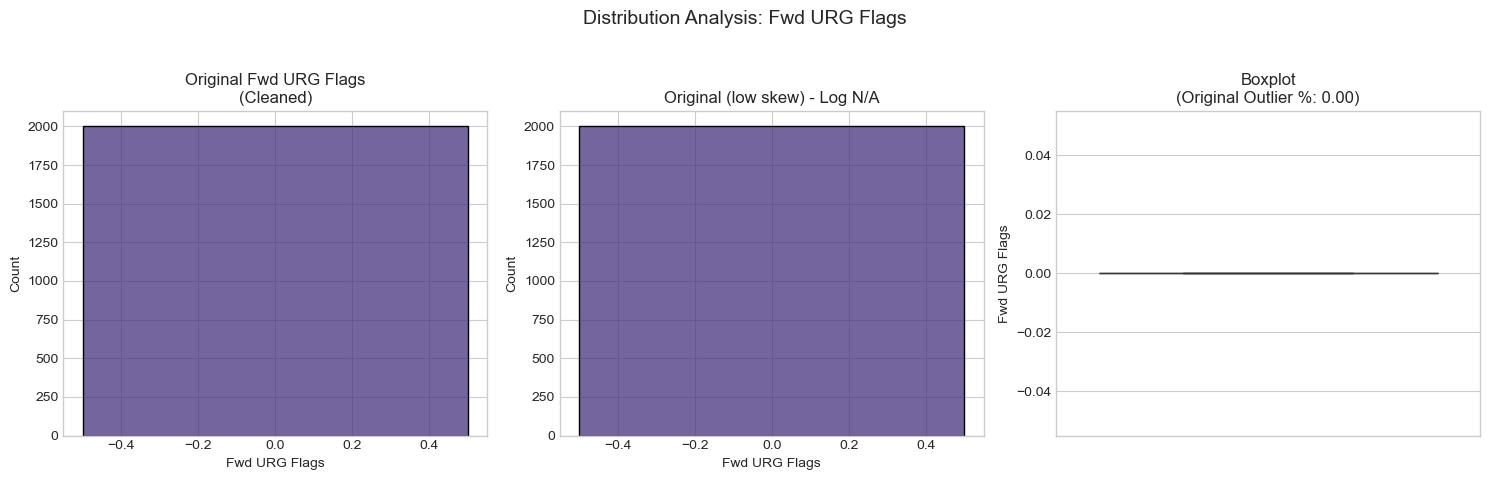

  Plots shown for 'Fwd URG Flags'.
  -> Finished feature: 'Fwd URG Flags' in 0.41 seconds.
[34/77] Starting analysis for feature: 'Bwd URG Flags'...
  Calculating stats for 'Bwd URG Flags'...
  Stats calculated for 'Bwd URG Flags'.
  Plotting distributions for 'Bwd URG Flags'...
    Original Data stats for 'Bwd URG Flags' before plotting:
count    2000.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: Bwd URG Flags, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Bwd URG Flags'.
    Trying sns.histplot (original) for 'Bwd URG Flags'...
    SUCCESS: sns.histplot (original) for 'Bwd URG Flags'.
    Trying sns.histplot (log) for 'Bwd URG Flags'...
    SUCCESS: sns.histplot (log) for 'Bwd URG Flags'.
    Trying sns.boxplot for 'Bwd URG Flags'...
    SUCCESS: sns.boxplot for 'Bwd URG Flags'.


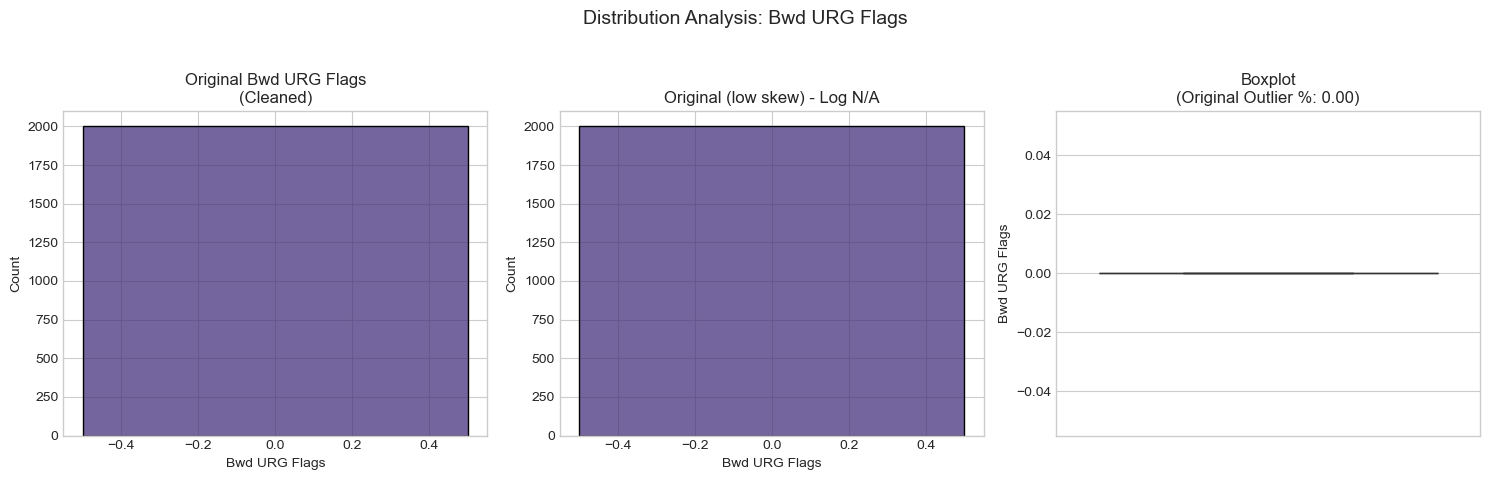

  Plots shown for 'Bwd URG Flags'.
  -> Finished feature: 'Bwd URG Flags' in 0.41 seconds.
[35/77] Starting analysis for feature: 'Fwd Header Len'...
  Calculating stats for 'Fwd Header Len'...
  Stats calculated for 'Fwd Header Len'.
  -> Feature 'Fwd Header Len' is very skewed. Skipping plotting to avoid hangs.
  -> Finished feature: 'Fwd Header Len' in 0.00 seconds.
[36/77] Starting analysis for feature: 'Bwd Header Len'...
  Calculating stats for 'Bwd Header Len'...
  Stats calculated for 'Bwd Header Len'.
  -> Feature 'Bwd Header Len' is very skewed. Skipping plotting to avoid hangs.
  -> Finished feature: 'Bwd Header Len' in 0.01 seconds.
[37/77] Starting analysis for feature: 'Fwd Pkts/s'...
  Calculating stats for 'Fwd Pkts/s'...
  Stats calculated for 'Fwd Pkts/s'.
  Plotting distributions for 'Fwd Pkts/s'...
    Original Data stats for 'Fwd Pkts/s' before plotting:
count    2.000000e+03
mean     2.274803e+04
std      2.009970e+05
min      0.000000e+00
25%      1.468817e+00
50

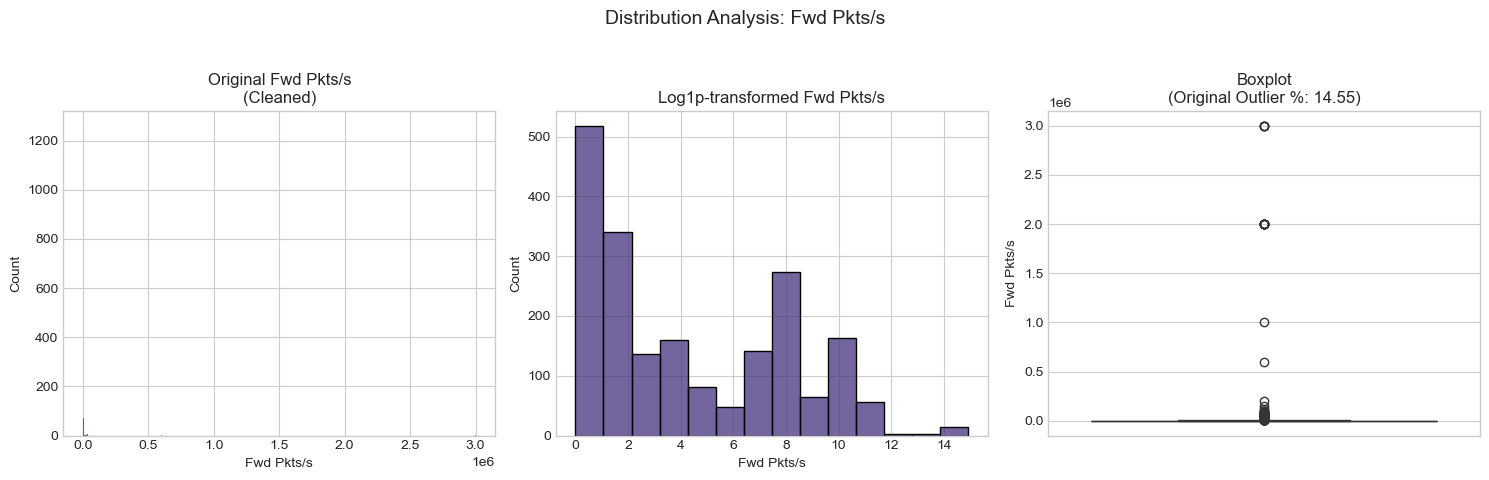

  Plots shown for 'Fwd Pkts/s'.
  -> Finished feature: 'Fwd Pkts/s' in 5.54 seconds.
[38/77] Starting analysis for feature: 'Bwd Pkts/s'...
  Calculating stats for 'Bwd Pkts/s'...
  Stats calculated for 'Bwd Pkts/s'.
  -> Feature 'Bwd Pkts/s' is very skewed. Skipping plotting to avoid hangs.
  -> Finished feature: 'Bwd Pkts/s' in 0.00 seconds.
[39/77] Starting analysis for feature: 'Pkt Len Min'...
  Calculating stats for 'Pkt Len Min'...
  Stats calculated for 'Pkt Len Min'.
  Plotting distributions for 'Pkt Len Min'...
    Original Data stats for 'Pkt Len Min' before plotting:
count    2000.000000
mean       12.993500
std        26.186109
min         0.000000
25%         0.000000
50%         0.000000
75%        33.000000
max       500.000000
Name: Pkt Len Min, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Pkt Len Min'.
    Trying sns.histplot (original) for 'Pkt Len Min'...
    SUCCESS: sns.histplot (original) for 'Pkt L

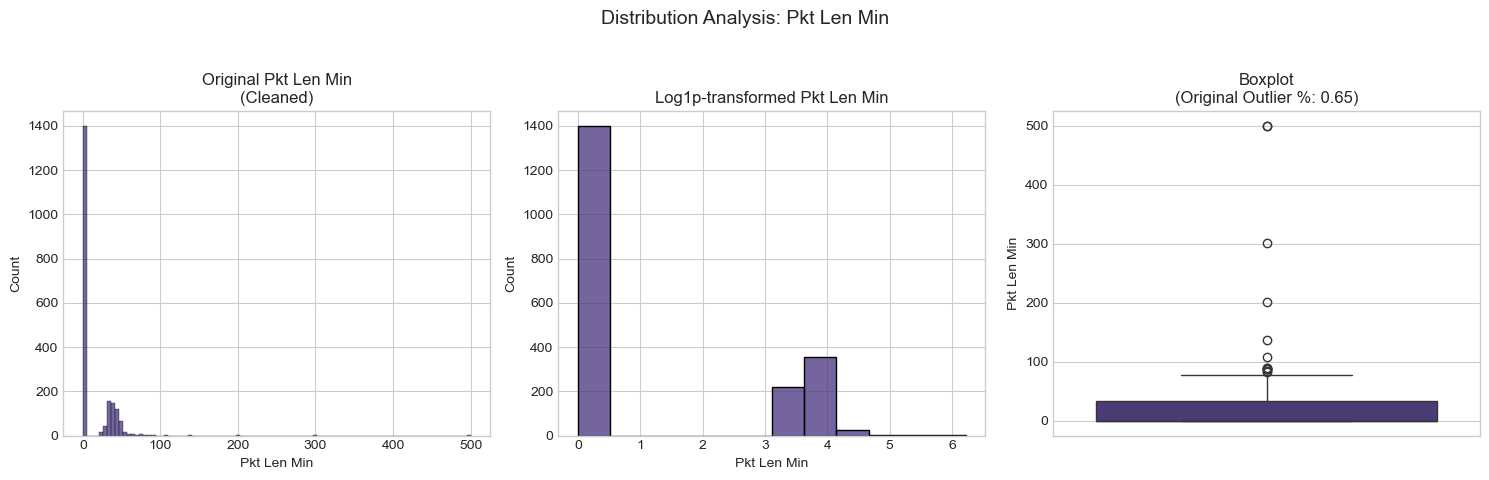

  Plots shown for 'Pkt Len Min'.
  -> Finished feature: 'Pkt Len Min' in 0.57 seconds.
[40/77] Starting analysis for feature: 'Pkt Len Max'...
  Calculating stats for 'Pkt Len Max'...
  Stats calculated for 'Pkt Len Max'.
  Plotting distributions for 'Pkt Len Max'...
    Original Data stats for 'Pkt Len Max' before plotting:
count    2000.00000
mean      367.10200
std       514.67199
min         0.00000
25%         0.00000
50%        95.50000
75%       488.00000
max      1460.00000
Name: Pkt Len Max, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Pkt Len Max'.
    Trying sns.histplot (original) for 'Pkt Len Max'...
    SUCCESS: sns.histplot (original) for 'Pkt Len Max'.
    Trying sns.histplot (log) for 'Pkt Len Max'...
    SUCCESS: sns.histplot (log) for 'Pkt Len Max'.
    Trying sns.boxplot for 'Pkt Len Max'...
    SUCCESS: sns.boxplot for 'Pkt Len Max'.


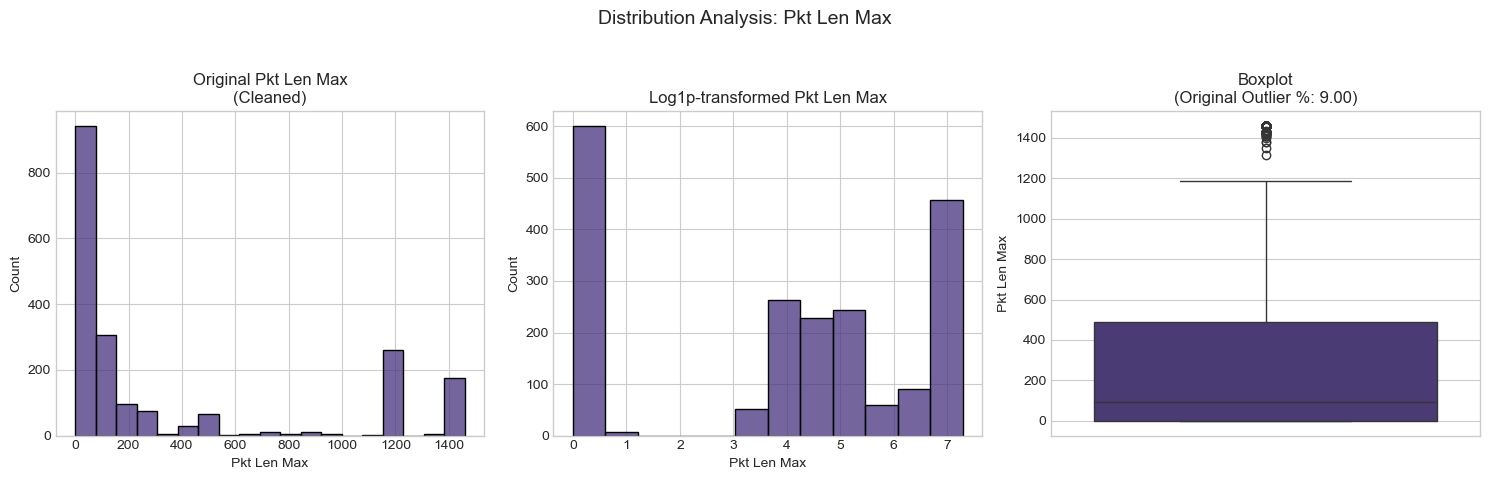

  Plots shown for 'Pkt Len Max'.
  -> Finished feature: 'Pkt Len Max' in 0.43 seconds.
[41/77] Starting analysis for feature: 'Pkt Len Mean'...
  Calculating stats for 'Pkt Len Mean'...
  Stats calculated for 'Pkt Len Mean'.
  Plotting distributions for 'Pkt Len Mean'...
    Original Data stats for 'Pkt Len Mean' before plotting:
count    2000.000000
mean       77.912054
std       109.965808
min         0.000000
25%         0.000000
50%        50.500000
75%       102.045455
max      1103.105674
Name: Pkt Len Mean, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Pkt Len Mean'.
    Trying sns.histplot (original) for 'Pkt Len Mean'...
    SUCCESS: sns.histplot (original) for 'Pkt Len Mean'.
    Trying sns.histplot (log) for 'Pkt Len Mean'...
    SUCCESS: sns.histplot (log) for 'Pkt Len Mean'.
    Trying sns.boxplot for 'Pkt Len Mean'...
    SUCCESS: sns.boxplot for 'Pkt Len Mean'.


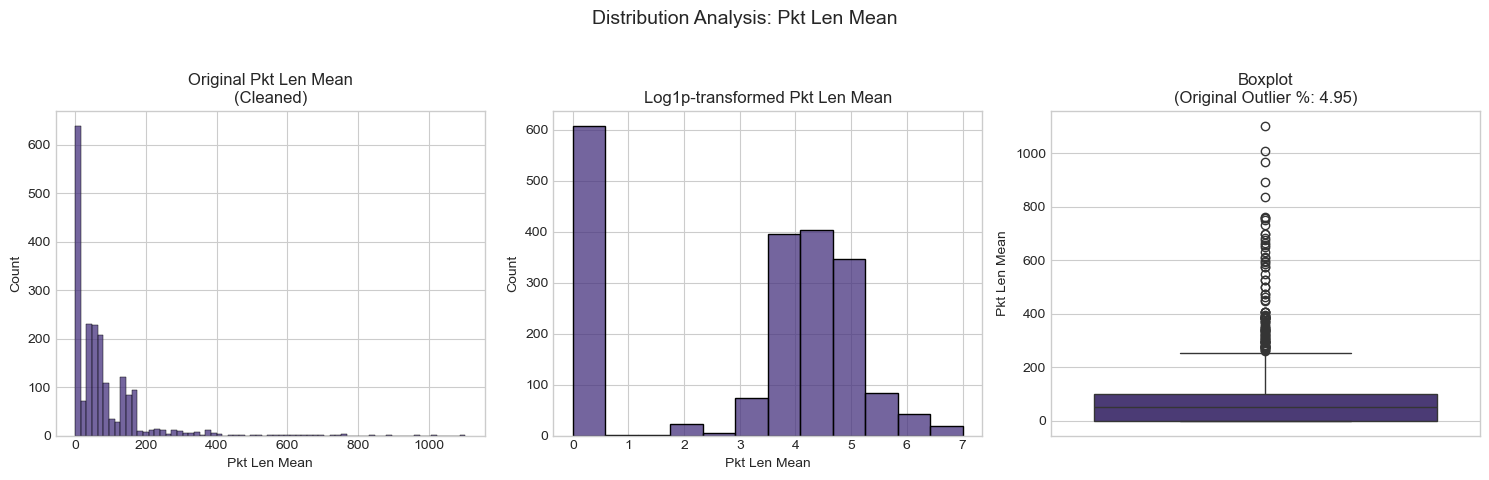

  Plots shown for 'Pkt Len Mean'.
  -> Finished feature: 'Pkt Len Mean' in 0.47 seconds.
[42/77] Starting analysis for feature: 'Pkt Len Std'...
  Calculating stats for 'Pkt Len Std'...
  Stats calculated for 'Pkt Len Std'.
  Plotting distributions for 'Pkt Len Std'...
    Original Data stats for 'Pkt Len Std' before plotting:
count    2000.000000
mean      111.480690
std       161.453285
min         0.000000
25%         0.000000
50%        32.331615
75%       173.787586
max       729.845973
Name: Pkt Len Std, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Pkt Len Std'.
    Trying sns.histplot (original) for 'Pkt Len Std'...
    SUCCESS: sns.histplot (original) for 'Pkt Len Std'.
    Trying sns.histplot (log) for 'Pkt Len Std'...
    SUCCESS: sns.histplot (log) for 'Pkt Len Std'.
    Trying sns.boxplot for 'Pkt Len Std'...
    SUCCESS: sns.boxplot for 'Pkt Len Std'.


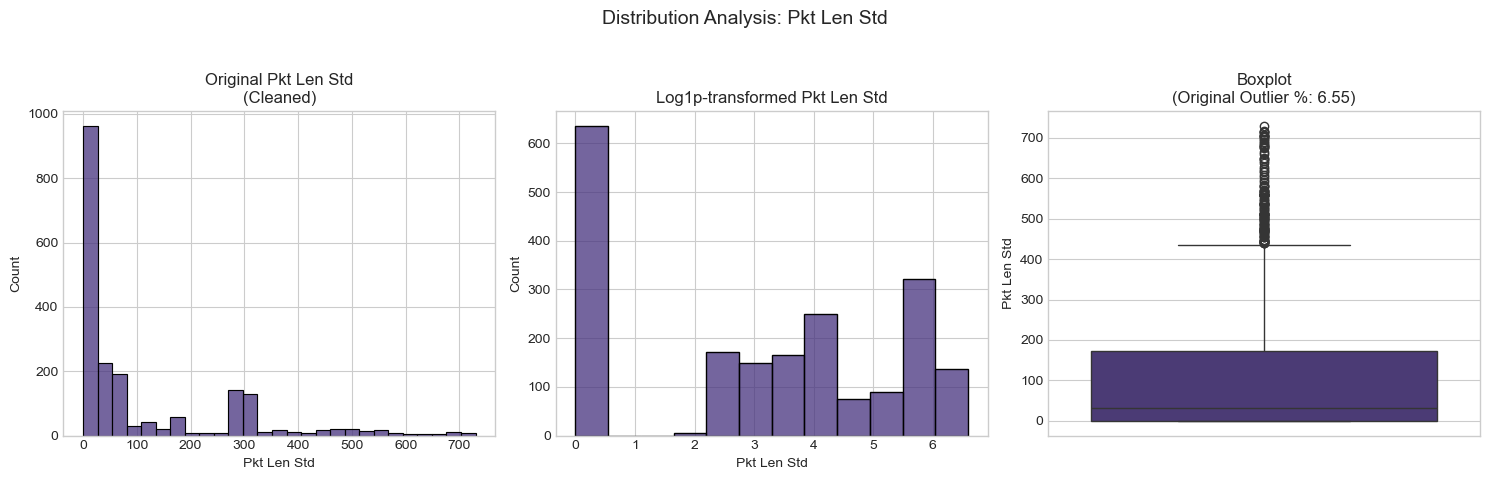

  Plots shown for 'Pkt Len Std'.
  -> Finished feature: 'Pkt Len Std' in 0.46 seconds.
[43/77] Starting analysis for feature: 'Pkt Len Var'...
  Calculating stats for 'Pkt Len Var'...
  Stats calculated for 'Pkt Len Var'.
  Plotting distributions for 'Pkt Len Var'...
    Original Data stats for 'Pkt Len Var' before plotting:
count      2000.000000
mean      38482.074061
std       84147.997892
min           0.000000
25%           0.000000
50%        1045.333333
75%       30202.125000
max      532675.144636
Name: Pkt Len Var, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Pkt Len Var'.
    Trying sns.histplot (original) for 'Pkt Len Var'...
    SUCCESS: sns.histplot (original) for 'Pkt Len Var'.
    Trying sns.histplot (log) for 'Pkt Len Var'...
    SUCCESS: sns.histplot (log) for 'Pkt Len Var'.
    Trying sns.boxplot for 'Pkt Len Var'...
    SUCCESS: sns.boxplot for 'Pkt Len Var'.


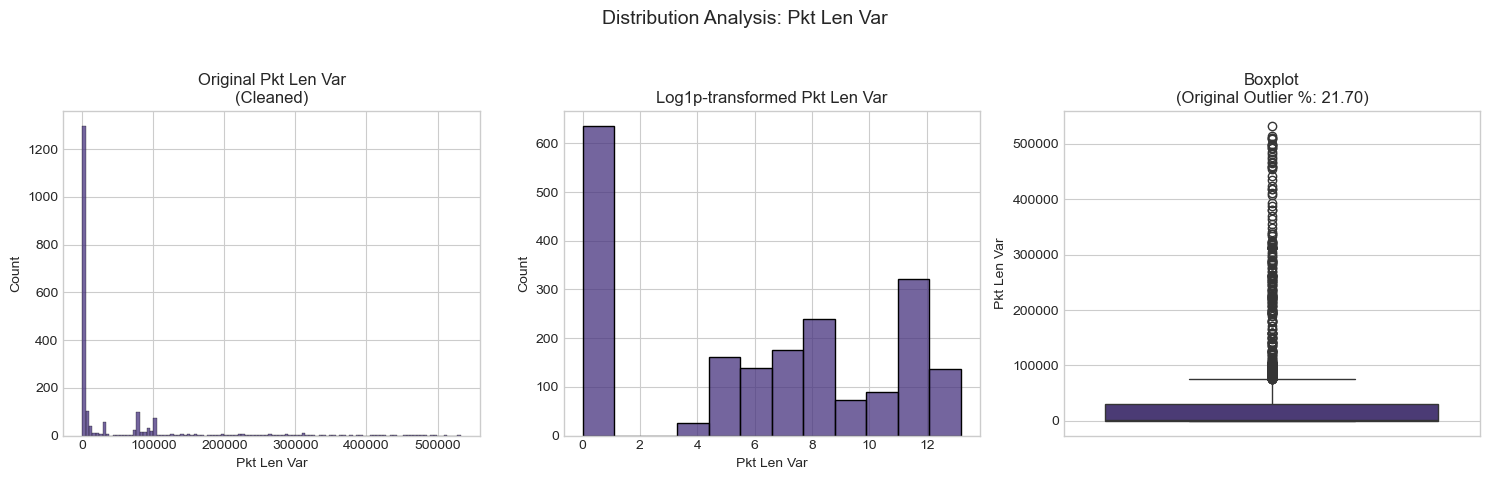

  Plots shown for 'Pkt Len Var'.
  -> Finished feature: 'Pkt Len Var' in 0.50 seconds.
[44/77] Starting analysis for feature: 'FIN Flag Cnt'...
  Calculating stats for 'FIN Flag Cnt'...
  Stats calculated for 'FIN Flag Cnt'.
  Plotting distributions for 'FIN Flag Cnt'...
    Original Data stats for 'FIN Flag Cnt' before plotting:
count    2000.000000
mean        0.006000
std         0.077246
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: FIN Flag Cnt, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'FIN Flag Cnt'.
    Trying sns.histplot (original) for 'FIN Flag Cnt'...
    SUCCESS: sns.histplot (original) for 'FIN Flag Cnt'.
    Trying sns.histplot (log) for 'FIN Flag Cnt'...
    SUCCESS: sns.histplot (log) for 'FIN Flag Cnt'.
    Trying sns.boxplot for 'FIN Flag Cnt'...
    SUCCESS: sns.boxplot for 'FIN Flag Cnt'.


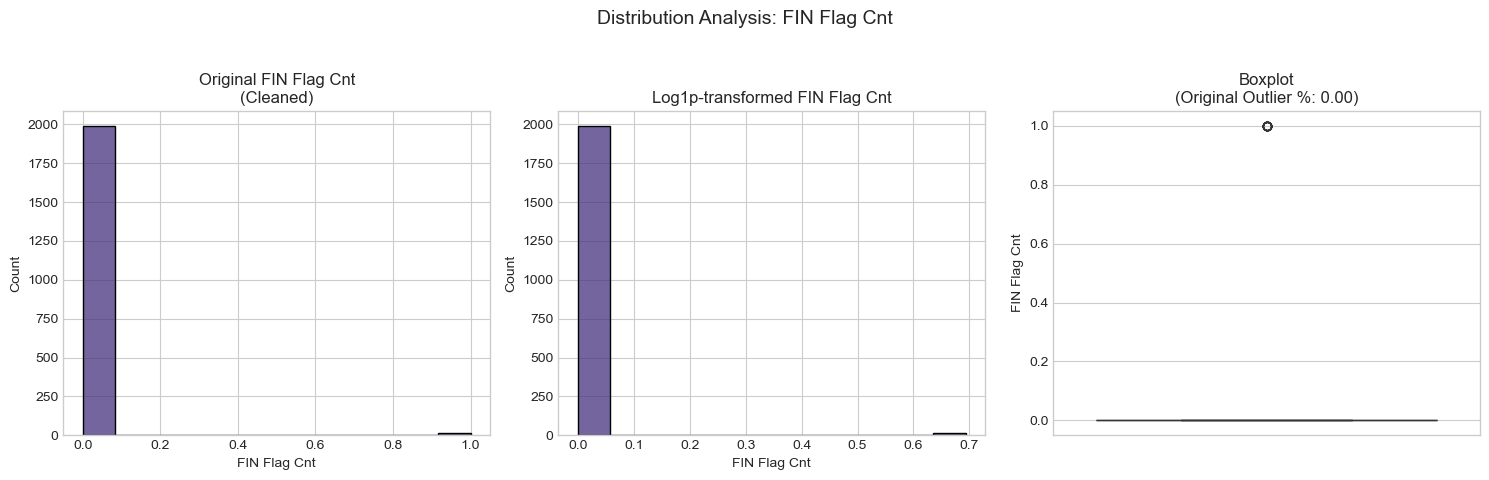

  Plots shown for 'FIN Flag Cnt'.
  -> Finished feature: 'FIN Flag Cnt' in 0.45 seconds.
[45/77] Starting analysis for feature: 'SYN Flag Cnt'...
  Calculating stats for 'SYN Flag Cnt'...
  Stats calculated for 'SYN Flag Cnt'.
  Plotting distributions for 'SYN Flag Cnt'...
    Original Data stats for 'SYN Flag Cnt' before plotting:
count    2000.000000
mean        0.037500
std         0.190031
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: SYN Flag Cnt, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'SYN Flag Cnt'.
    Trying sns.histplot (original) for 'SYN Flag Cnt'...
    SUCCESS: sns.histplot (original) for 'SYN Flag Cnt'.
    Trying sns.histplot (log) for 'SYN Flag Cnt'...
    SUCCESS: sns.histplot (log) for 'SYN Flag Cnt'.
    Trying sns.boxplot for 'SYN Flag Cnt'...
    SUCCESS: sns.boxplot for 'SYN Flag Cnt'.


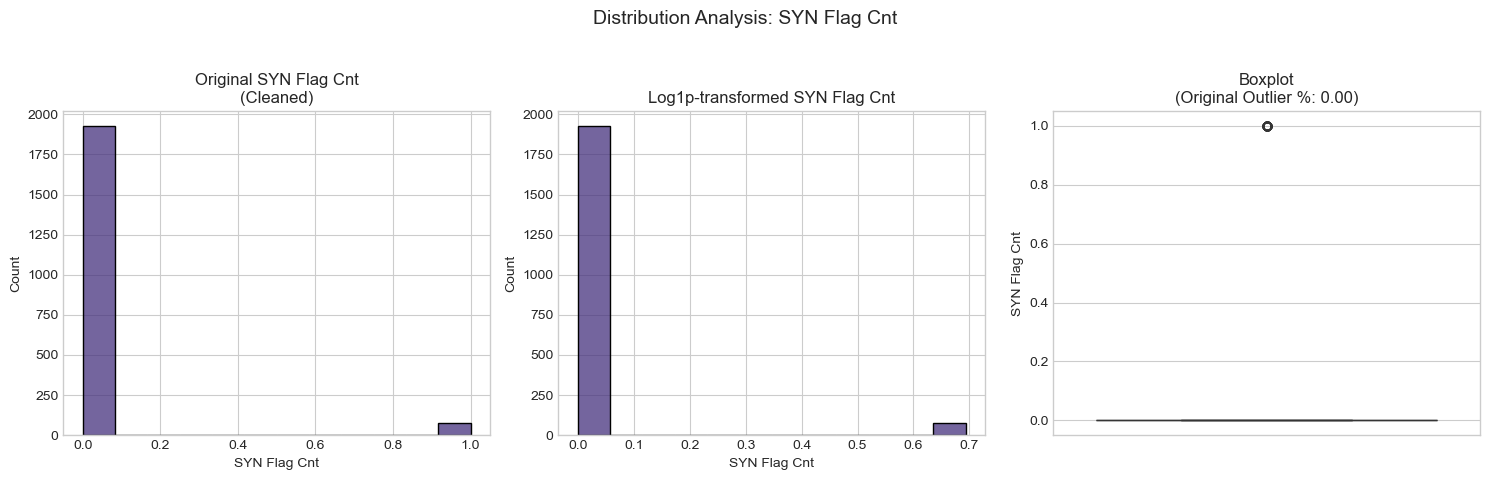

  Plots shown for 'SYN Flag Cnt'.
  -> Finished feature: 'SYN Flag Cnt' in 0.46 seconds.
[46/77] Starting analysis for feature: 'RST Flag Cnt'...
  Calculating stats for 'RST Flag Cnt'...
  Stats calculated for 'RST Flag Cnt'.
  Plotting distributions for 'RST Flag Cnt'...
    Original Data stats for 'RST Flag Cnt' before plotting:
count    2000.000000
mean        0.114000
std         0.317891
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: RST Flag Cnt, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'RST Flag Cnt'.
    Trying sns.histplot (original) for 'RST Flag Cnt'...
    SUCCESS: sns.histplot (original) for 'RST Flag Cnt'.
    Trying sns.histplot (log) for 'RST Flag Cnt'...
    SUCCESS: sns.histplot (log) for 'RST Flag Cnt'.
    Trying sns.boxplot for 'RST Flag Cnt'...
    SUCCESS: sns.boxplot for 'RST Flag Cnt'.


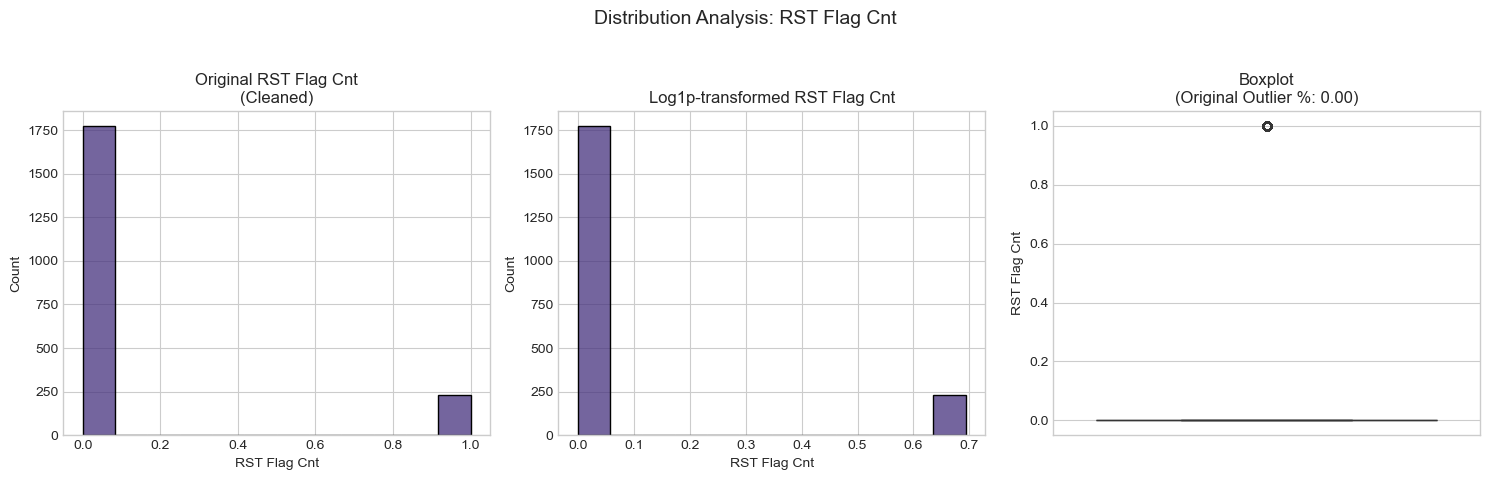

  Plots shown for 'RST Flag Cnt'.
  -> Finished feature: 'RST Flag Cnt' in 0.47 seconds.
[47/77] Starting analysis for feature: 'PSH Flag Cnt'...
  Calculating stats for 'PSH Flag Cnt'...
  Stats calculated for 'PSH Flag Cnt'.
  Plotting distributions for 'PSH Flag Cnt'...
    Original Data stats for 'PSH Flag Cnt' before plotting:
count    2000.000000
mean        0.371500
std         0.483327
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: PSH Flag Cnt, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'PSH Flag Cnt'.
    Trying sns.histplot (original) for 'PSH Flag Cnt'...
    SUCCESS: sns.histplot (original) for 'PSH Flag Cnt'.
    Trying sns.histplot (log) for 'PSH Flag Cnt'...
    SUCCESS: sns.histplot (log) for 'PSH Flag Cnt'.
    Trying sns.boxplot for 'PSH Flag Cnt'...
    SUCCESS: sns.boxplot for 'PSH Flag Cnt'.


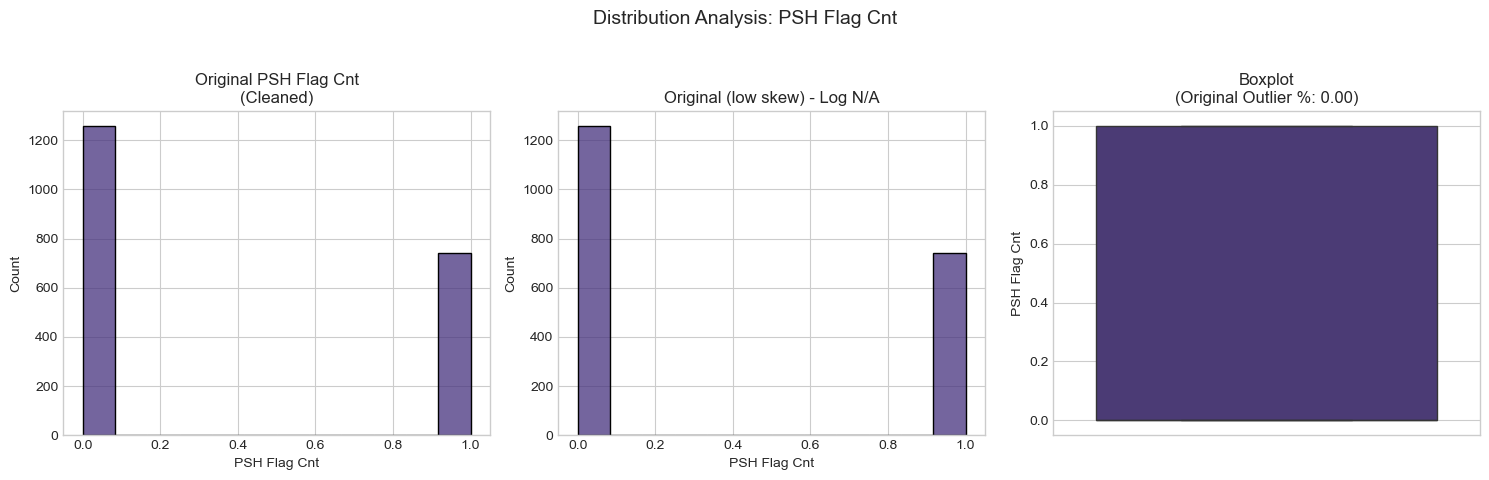

  Plots shown for 'PSH Flag Cnt'.
  -> Finished feature: 'PSH Flag Cnt' in 0.44 seconds.
[48/77] Starting analysis for feature: 'ACK Flag Cnt'...
  Calculating stats for 'ACK Flag Cnt'...
  Stats calculated for 'ACK Flag Cnt'.
  Plotting distributions for 'ACK Flag Cnt'...
    Original Data stats for 'ACK Flag Cnt' before plotting:
count    2000.000000
mean        0.310500
std         0.462814
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: ACK Flag Cnt, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'ACK Flag Cnt'.
    Trying sns.histplot (original) for 'ACK Flag Cnt'...
    SUCCESS: sns.histplot (original) for 'ACK Flag Cnt'.
    Trying sns.histplot (log) for 'ACK Flag Cnt'...
    SUCCESS: sns.histplot (log) for 'ACK Flag Cnt'.
    Trying sns.boxplot for 'ACK Flag Cnt'...
    SUCCESS: sns.boxplot for 'ACK Flag Cnt'.


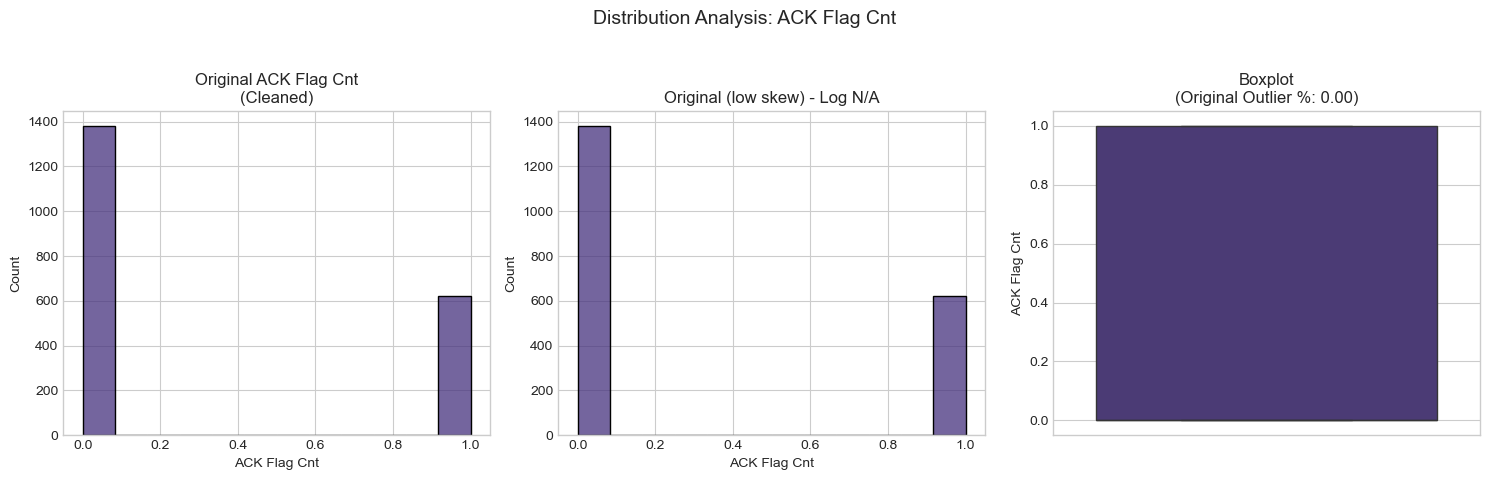

  Plots shown for 'ACK Flag Cnt'.
  -> Finished feature: 'ACK Flag Cnt' in 0.43 seconds.
[49/77] Starting analysis for feature: 'URG Flag Cnt'...
  Calculating stats for 'URG Flag Cnt'...
  Stats calculated for 'URG Flag Cnt'.
  Plotting distributions for 'URG Flag Cnt'...
    Original Data stats for 'URG Flag Cnt' before plotting:
count    2000.000000
mean        0.043500
std         0.204031
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: URG Flag Cnt, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'URG Flag Cnt'.
    Trying sns.histplot (original) for 'URG Flag Cnt'...
    SUCCESS: sns.histplot (original) for 'URG Flag Cnt'.
    Trying sns.histplot (log) for 'URG Flag Cnt'...
    SUCCESS: sns.histplot (log) for 'URG Flag Cnt'.
    Trying sns.boxplot for 'URG Flag Cnt'...
    SUCCESS: sns.boxplot for 'URG Flag Cnt'.


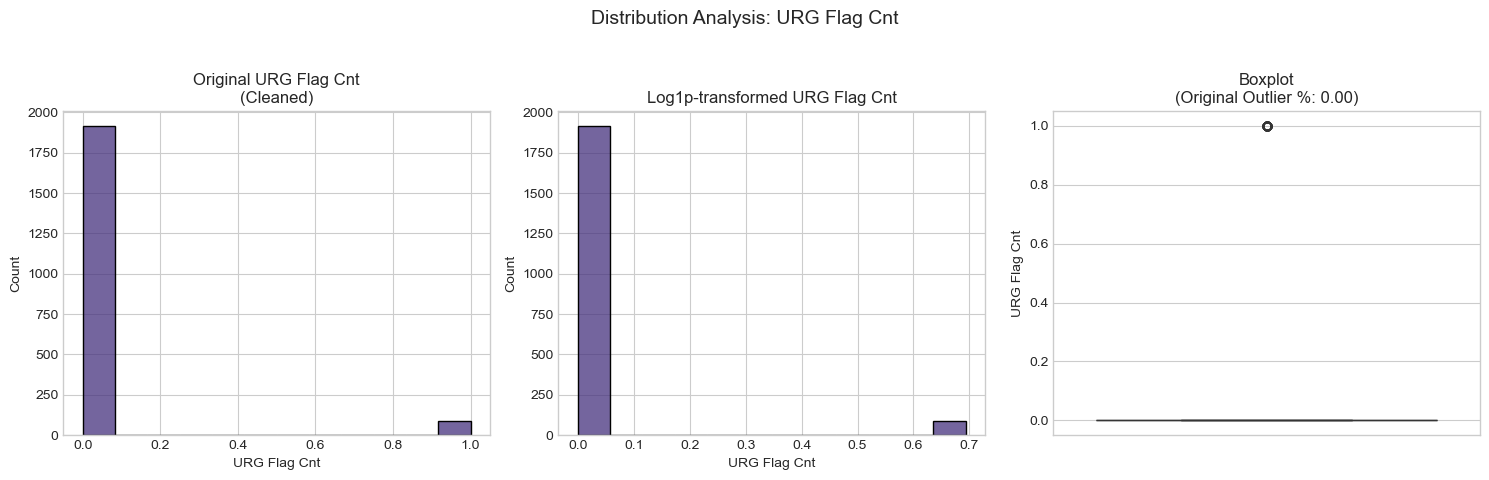

  Plots shown for 'URG Flag Cnt'.
  -> Finished feature: 'URG Flag Cnt' in 0.46 seconds.
[50/77] Starting analysis for feature: 'CWE Flag Count'...
  Calculating stats for 'CWE Flag Count'...
  Stats calculated for 'CWE Flag Count'.
  Plotting distributions for 'CWE Flag Count'...
    Original Data stats for 'CWE Flag Count' before plotting:
count    2000.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: CWE Flag Count, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'CWE Flag Count'.
    Trying sns.histplot (original) for 'CWE Flag Count'...
    SUCCESS: sns.histplot (original) for 'CWE Flag Count'.
    Trying sns.histplot (log) for 'CWE Flag Count'...
    SUCCESS: sns.histplot (log) for 'CWE Flag Count'.
    Trying sns.boxplot for 'CWE Flag Count'...
    SUCCESS: sns.boxplot for 'CWE Flag Count'.


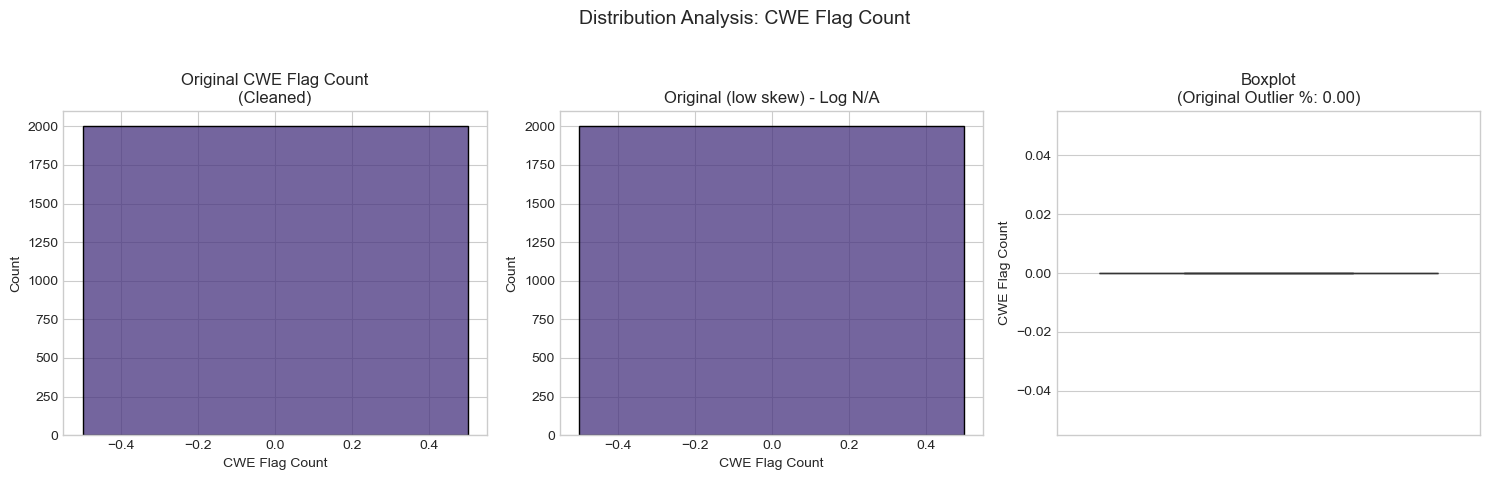

  Plots shown for 'CWE Flag Count'.
  -> Finished feature: 'CWE Flag Count' in 0.42 seconds.
[51/77] Starting analysis for feature: 'ECE Flag Cnt'...
  Calculating stats for 'ECE Flag Cnt'...
  Stats calculated for 'ECE Flag Cnt'.
  Plotting distributions for 'ECE Flag Cnt'...
    Original Data stats for 'ECE Flag Cnt' before plotting:
count    2000.000000
mean        0.114000
std         0.317891
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: ECE Flag Cnt, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'ECE Flag Cnt'.
    Trying sns.histplot (original) for 'ECE Flag Cnt'...
    SUCCESS: sns.histplot (original) for 'ECE Flag Cnt'.
    Trying sns.histplot (log) for 'ECE Flag Cnt'...
    SUCCESS: sns.histplot (log) for 'ECE Flag Cnt'.
    Trying sns.boxplot for 'ECE Flag Cnt'...
    SUCCESS: sns.boxplot for 'ECE Flag Cnt'.


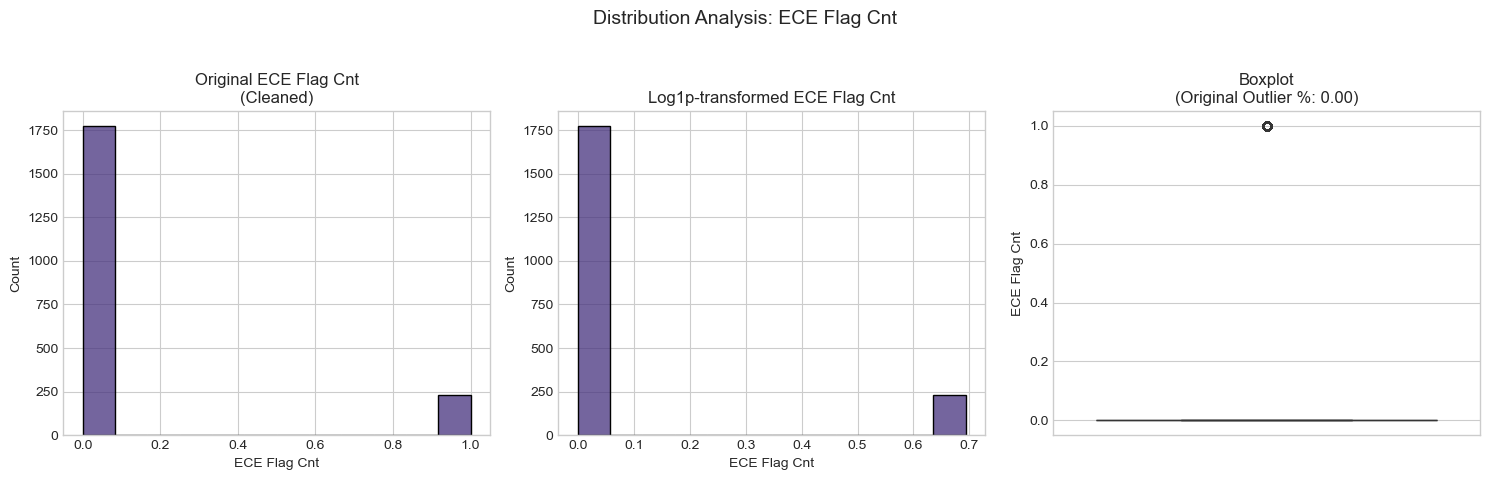

  Plots shown for 'ECE Flag Cnt'.
  -> Finished feature: 'ECE Flag Cnt' in 0.45 seconds.
[52/77] Starting analysis for feature: 'Down/Up Ratio'...
  Calculating stats for 'Down/Up Ratio'...
  Stats calculated for 'Down/Up Ratio'.
  Plotting distributions for 'Down/Up Ratio'...
    Original Data stats for 'Down/Up Ratio' before plotting:
count    2000.000000
mean        0.473500
std         0.527671
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         4.000000
Name: Down/Up Ratio, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Down/Up Ratio'.
    Trying sns.histplot (original) for 'Down/Up Ratio'...
    SUCCESS: sns.histplot (original) for 'Down/Up Ratio'.
    Trying sns.histplot (log) for 'Down/Up Ratio'...
    SUCCESS: sns.histplot (log) for 'Down/Up Ratio'.
    Trying sns.boxplot for 'Down/Up Ratio'...
    SUCCESS: sns.boxplot for 'Down/Up Ratio'.


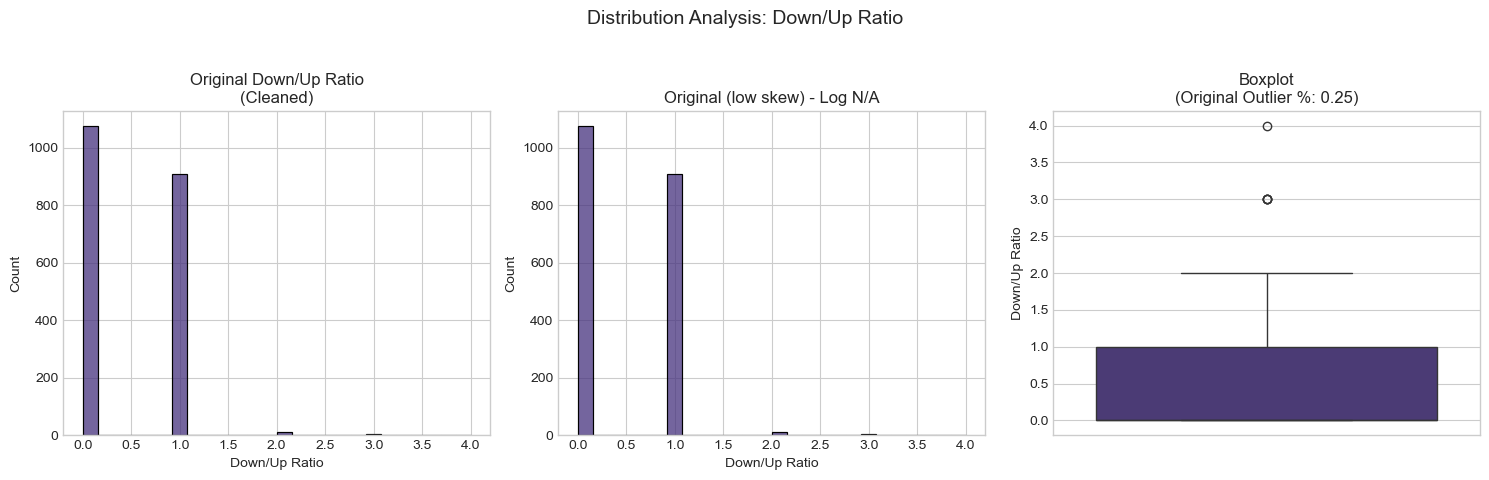

  Plots shown for 'Down/Up Ratio'.
  -> Finished feature: 'Down/Up Ratio' in 0.47 seconds.
[53/77] Starting analysis for feature: 'Pkt Size Avg'...
  Calculating stats for 'Pkt Size Avg'...
  Stats calculated for 'Pkt Size Avg'.
  Plotting distributions for 'Pkt Size Avg'...
    Original Data stats for 'Pkt Size Avg' before plotting:
count    2000.000000
mean       89.686849
std       114.037044
min         0.000000
25%         0.000000
50%        71.000000
75%       134.000000
max      1103.251587
Name: Pkt Size Avg, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Pkt Size Avg'.
    Trying sns.histplot (original) for 'Pkt Size Avg'...
    SUCCESS: sns.histplot (original) for 'Pkt Size Avg'.
    Trying sns.histplot (log) for 'Pkt Size Avg'...
    SUCCESS: sns.histplot (log) for 'Pkt Size Avg'.
    Trying sns.boxplot for 'Pkt Size Avg'...
    SUCCESS: sns.boxplot for 'Pkt Size Avg'.


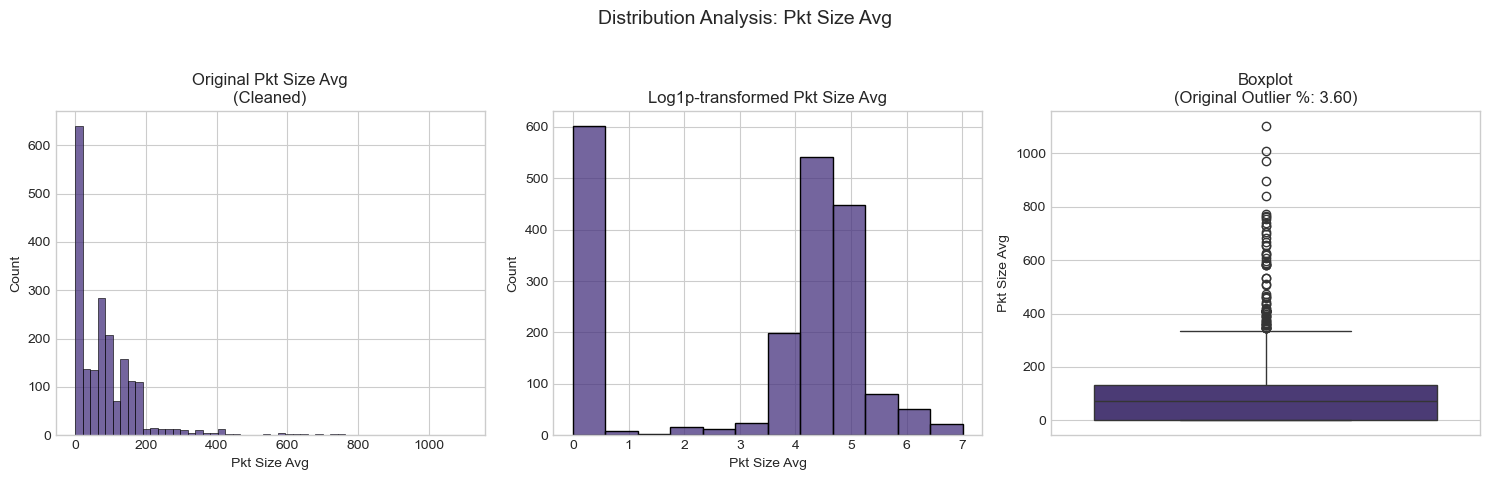

  Plots shown for 'Pkt Size Avg'.
  -> Finished feature: 'Pkt Size Avg' in 0.47 seconds.
[54/77] Starting analysis for feature: 'Fwd Seg Size Avg'...
  Calculating stats for 'Fwd Seg Size Avg'...
  Stats calculated for 'Fwd Seg Size Avg'.
  Plotting distributions for 'Fwd Seg Size Avg'...
    Original Data stats for 'Fwd Seg Size Avg' before plotting:
count    2000.000000
mean       44.199116
std        49.296214
min         0.000000
25%         0.000000
50%        36.000000
75%        54.025000
max       581.333333
Name: Fwd Seg Size Avg, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Fwd Seg Size Avg'.
    Trying sns.histplot (original) for 'Fwd Seg Size Avg'...
    SUCCESS: sns.histplot (original) for 'Fwd Seg Size Avg'.
    Trying sns.histplot (log) for 'Fwd Seg Size Avg'...
    SUCCESS: sns.histplot (log) for 'Fwd Seg Size Avg'.
    Trying sns.boxplot for 'Fwd Seg Size Avg'...
    SUCCESS: sns.boxplot for 'Fwd Seg Size

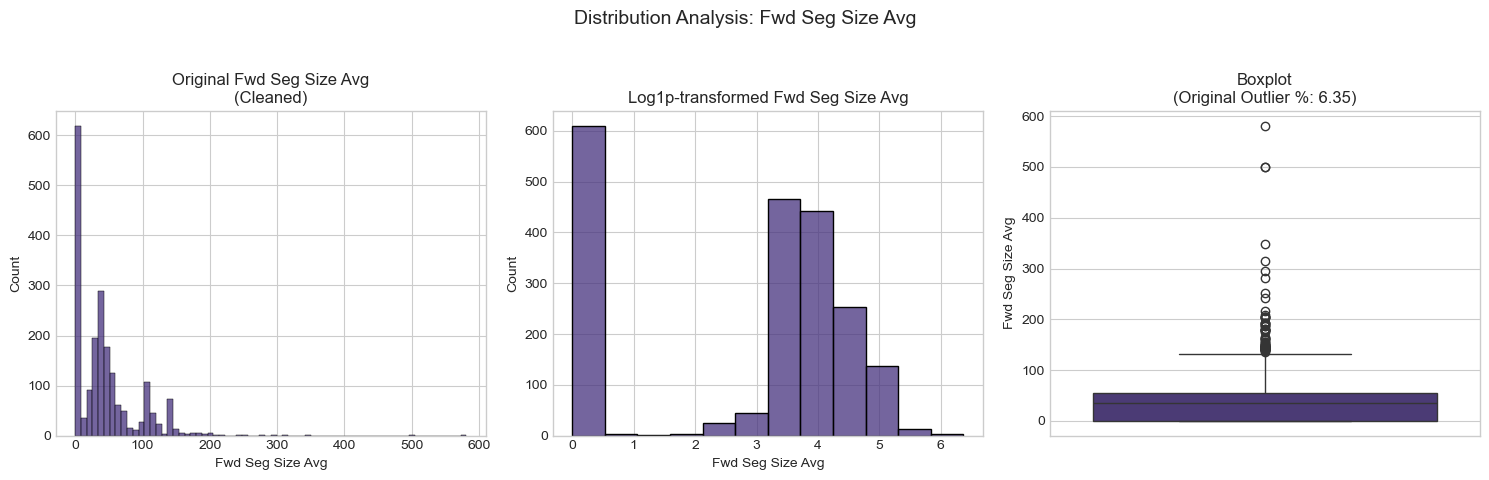

  Plots shown for 'Fwd Seg Size Avg'.
  -> Finished feature: 'Fwd Seg Size Avg' in 0.48 seconds.
[55/77] Starting analysis for feature: 'Bwd Seg Size Avg'...
  Calculating stats for 'Bwd Seg Size Avg'...
  Stats calculated for 'Bwd Seg Size Avg'.
  Plotting distributions for 'Bwd Seg Size Avg'...
    Original Data stats for 'Bwd Seg Size Avg' before plotting:
count    2000.000000
mean      119.549367
std       180.800432
min         0.000000
25%         0.000000
50%        64.000000
75%       166.850000
max      1449.634291
Name: Bwd Seg Size Avg, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Bwd Seg Size Avg'.
    Trying sns.histplot (original) for 'Bwd Seg Size Avg'...
    SUCCESS: sns.histplot (original) for 'Bwd Seg Size Avg'.
    Trying sns.histplot (log) for 'Bwd Seg Size Avg'...
    SUCCESS: sns.histplot (log) for 'Bwd Seg Size Avg'.
    Trying sns.boxplot for 'Bwd Seg Size Avg'...
    SUCCESS: sns.boxplot for 'Bwd 

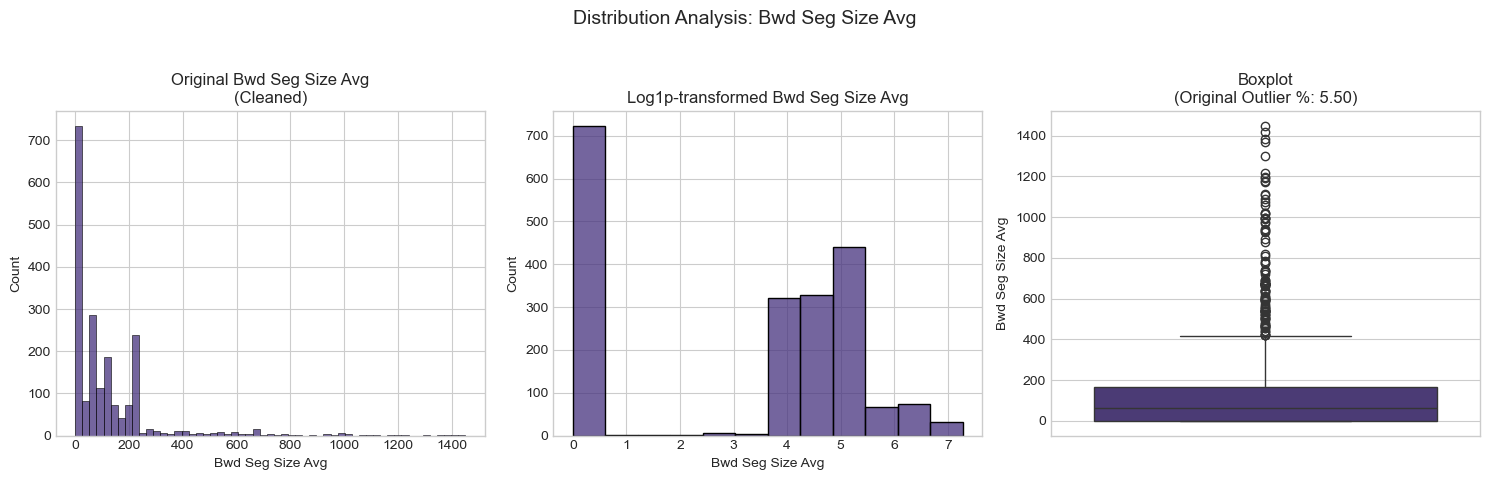

  Plots shown for 'Bwd Seg Size Avg'.
  -> Finished feature: 'Bwd Seg Size Avg' in 0.49 seconds.
[56/77] Starting analysis for feature: 'Fwd Byts/b Avg'...
  Calculating stats for 'Fwd Byts/b Avg'...
  Stats calculated for 'Fwd Byts/b Avg'.
  Plotting distributions for 'Fwd Byts/b Avg'...
    Original Data stats for 'Fwd Byts/b Avg' before plotting:
count    2000.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: Fwd Byts/b Avg, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Fwd Byts/b Avg'.
    Trying sns.histplot (original) for 'Fwd Byts/b Avg'...
    SUCCESS: sns.histplot (original) for 'Fwd Byts/b Avg'.
    Trying sns.histplot (log) for 'Fwd Byts/b Avg'...
    SUCCESS: sns.histplot (log) for 'Fwd Byts/b Avg'.
    Trying sns.boxplot for 'Fwd Byts/b Avg'...
    SUCCESS: sns.boxplot for 'Fwd Byts/b Avg'.


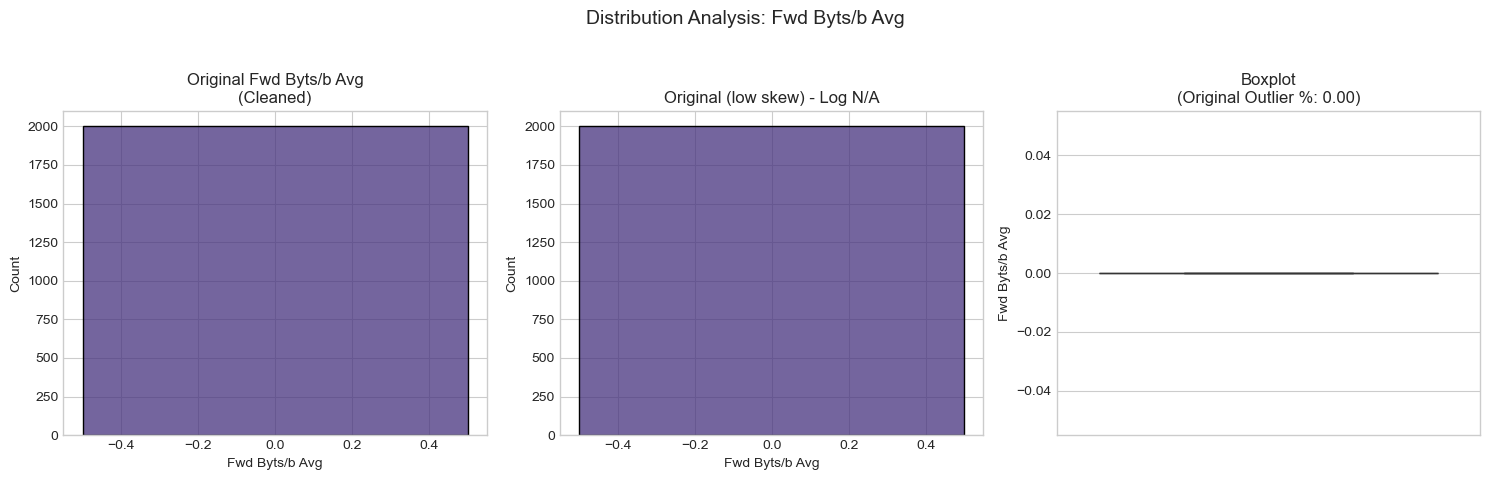

  Plots shown for 'Fwd Byts/b Avg'.
  -> Finished feature: 'Fwd Byts/b Avg' in 0.41 seconds.
[57/77] Starting analysis for feature: 'Fwd Pkts/b Avg'...
  Calculating stats for 'Fwd Pkts/b Avg'...
  Stats calculated for 'Fwd Pkts/b Avg'.
  Plotting distributions for 'Fwd Pkts/b Avg'...
    Original Data stats for 'Fwd Pkts/b Avg' before plotting:
count    2000.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: Fwd Pkts/b Avg, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Fwd Pkts/b Avg'.
    Trying sns.histplot (original) for 'Fwd Pkts/b Avg'...
    SUCCESS: sns.histplot (original) for 'Fwd Pkts/b Avg'.
    Trying sns.histplot (log) for 'Fwd Pkts/b Avg'...
    SUCCESS: sns.histplot (log) for 'Fwd Pkts/b Avg'.
    Trying sns.boxplot for 'Fwd Pkts/b Avg'...
    SUCCESS: sns.boxplot for 'Fwd Pkts/b Avg'.


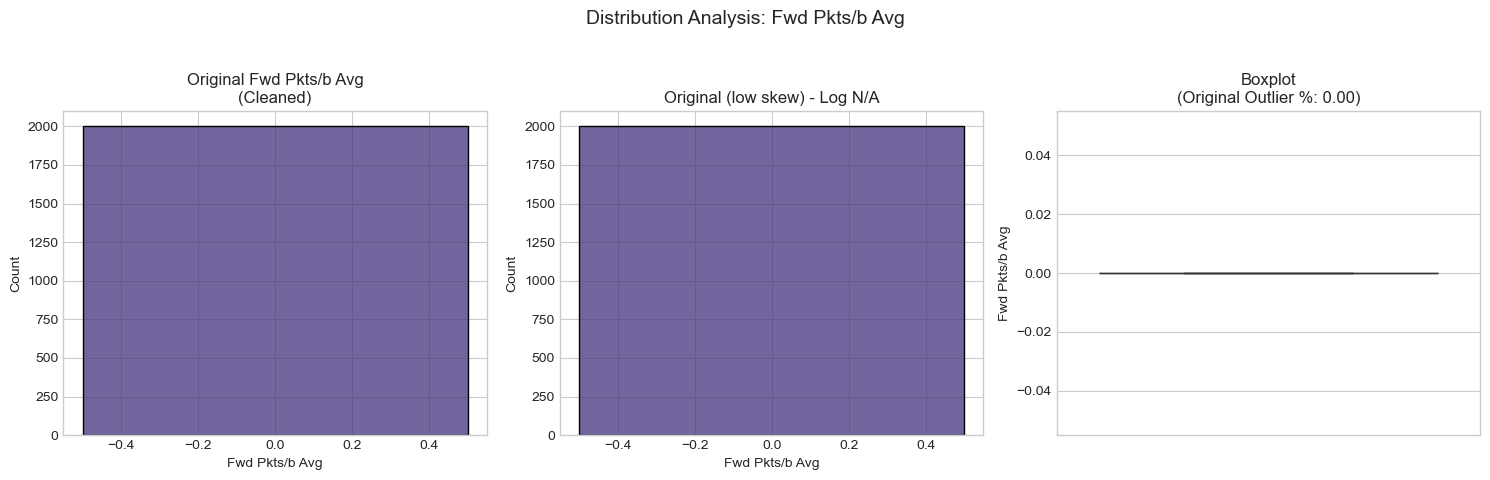

  Plots shown for 'Fwd Pkts/b Avg'.
  -> Finished feature: 'Fwd Pkts/b Avg' in 0.41 seconds.
[58/77] Starting analysis for feature: 'Fwd Blk Rate Avg'...
  Calculating stats for 'Fwd Blk Rate Avg'...
  Stats calculated for 'Fwd Blk Rate Avg'.
  Plotting distributions for 'Fwd Blk Rate Avg'...
    Original Data stats for 'Fwd Blk Rate Avg' before plotting:
count    2000.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: Fwd Blk Rate Avg, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Fwd Blk Rate Avg'.
    Trying sns.histplot (original) for 'Fwd Blk Rate Avg'...
    SUCCESS: sns.histplot (original) for 'Fwd Blk Rate Avg'.
    Trying sns.histplot (log) for 'Fwd Blk Rate Avg'...
    SUCCESS: sns.histplot (log) for 'Fwd Blk Rate Avg'.
    Trying sns.boxplot for 'Fwd Blk Rate Avg'...
    SUCCESS: sns.boxplot for 'Fwd Blk Rate Avg'.


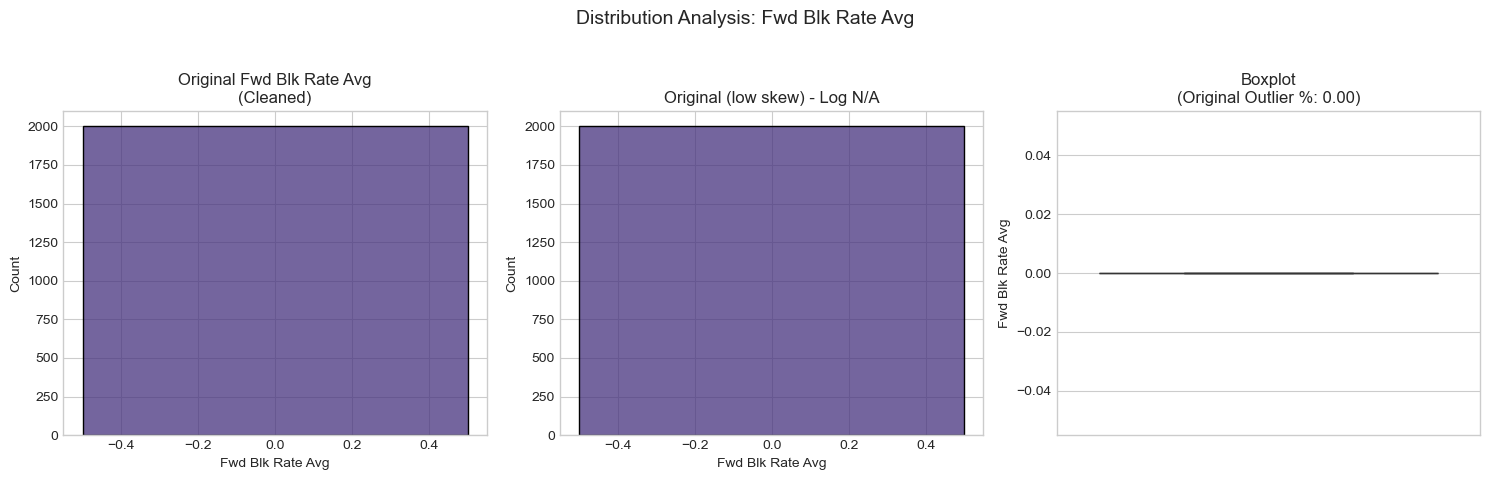

  Plots shown for 'Fwd Blk Rate Avg'.
  -> Finished feature: 'Fwd Blk Rate Avg' in 0.43 seconds.
[59/77] Starting analysis for feature: 'Bwd Byts/b Avg'...
  Calculating stats for 'Bwd Byts/b Avg'...
  Stats calculated for 'Bwd Byts/b Avg'.
  Plotting distributions for 'Bwd Byts/b Avg'...
    Original Data stats for 'Bwd Byts/b Avg' before plotting:
count    2000.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: Bwd Byts/b Avg, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Bwd Byts/b Avg'.
    Trying sns.histplot (original) for 'Bwd Byts/b Avg'...
    SUCCESS: sns.histplot (original) for 'Bwd Byts/b Avg'.
    Trying sns.histplot (log) for 'Bwd Byts/b Avg'...
    SUCCESS: sns.histplot (log) for 'Bwd Byts/b Avg'.
    Trying sns.boxplot for 'Bwd Byts/b Avg'...
    SUCCESS: sns.boxplot for 'Bwd Byts/b Avg'.


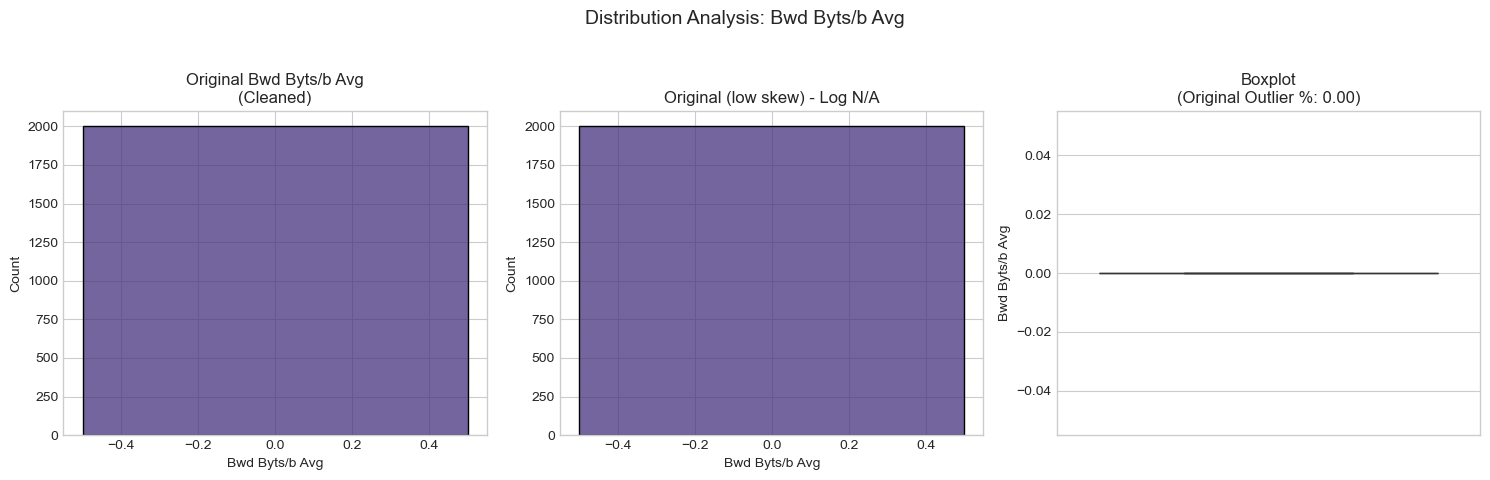

  Plots shown for 'Bwd Byts/b Avg'.
  -> Finished feature: 'Bwd Byts/b Avg' in 0.41 seconds.
[60/77] Starting analysis for feature: 'Bwd Pkts/b Avg'...
  Calculating stats for 'Bwd Pkts/b Avg'...
  Stats calculated for 'Bwd Pkts/b Avg'.
  Plotting distributions for 'Bwd Pkts/b Avg'...
    Original Data stats for 'Bwd Pkts/b Avg' before plotting:
count    2000.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: Bwd Pkts/b Avg, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Bwd Pkts/b Avg'.
    Trying sns.histplot (original) for 'Bwd Pkts/b Avg'...
    SUCCESS: sns.histplot (original) for 'Bwd Pkts/b Avg'.
    Trying sns.histplot (log) for 'Bwd Pkts/b Avg'...
    SUCCESS: sns.histplot (log) for 'Bwd Pkts/b Avg'.
    Trying sns.boxplot for 'Bwd Pkts/b Avg'...
    SUCCESS: sns.boxplot for 'Bwd Pkts/b Avg'.


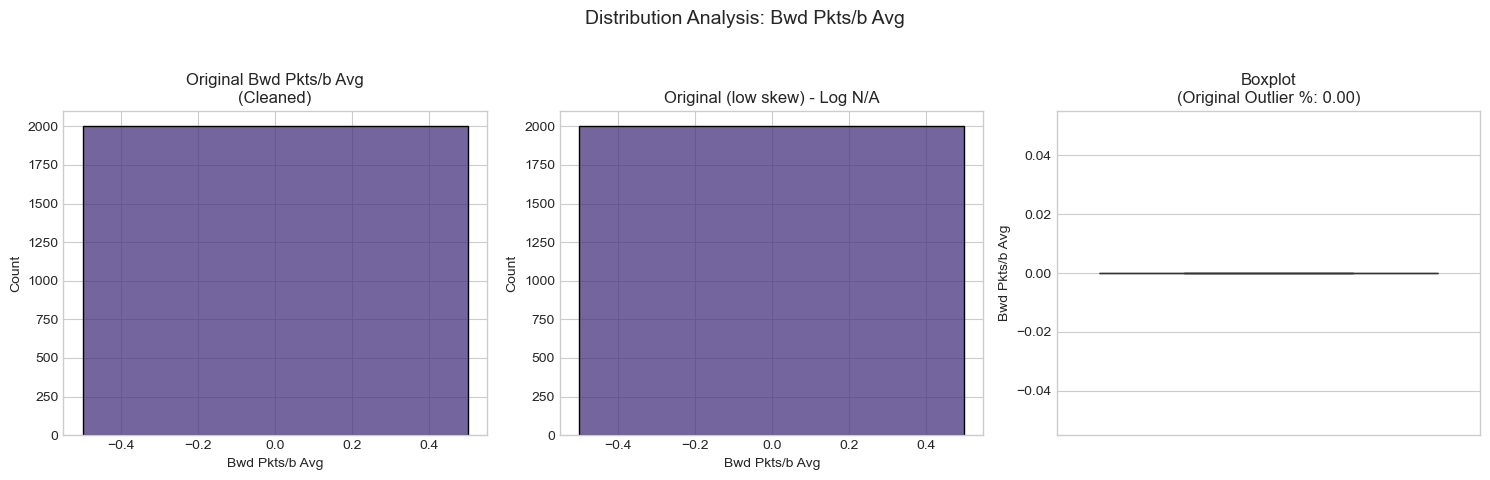

  Plots shown for 'Bwd Pkts/b Avg'.
  -> Finished feature: 'Bwd Pkts/b Avg' in 0.42 seconds.
[61/77] Starting analysis for feature: 'Bwd Blk Rate Avg'...
  Calculating stats for 'Bwd Blk Rate Avg'...
  Stats calculated for 'Bwd Blk Rate Avg'.
  Plotting distributions for 'Bwd Blk Rate Avg'...
    Original Data stats for 'Bwd Blk Rate Avg' before plotting:
count    2000.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: Bwd Blk Rate Avg, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Bwd Blk Rate Avg'.
    Trying sns.histplot (original) for 'Bwd Blk Rate Avg'...
    SUCCESS: sns.histplot (original) for 'Bwd Blk Rate Avg'.
    Trying sns.histplot (log) for 'Bwd Blk Rate Avg'...
    SUCCESS: sns.histplot (log) for 'Bwd Blk Rate Avg'.
    Trying sns.boxplot for 'Bwd Blk Rate Avg'...
    SUCCESS: sns.boxplot for 'Bwd Blk Rate Avg'.


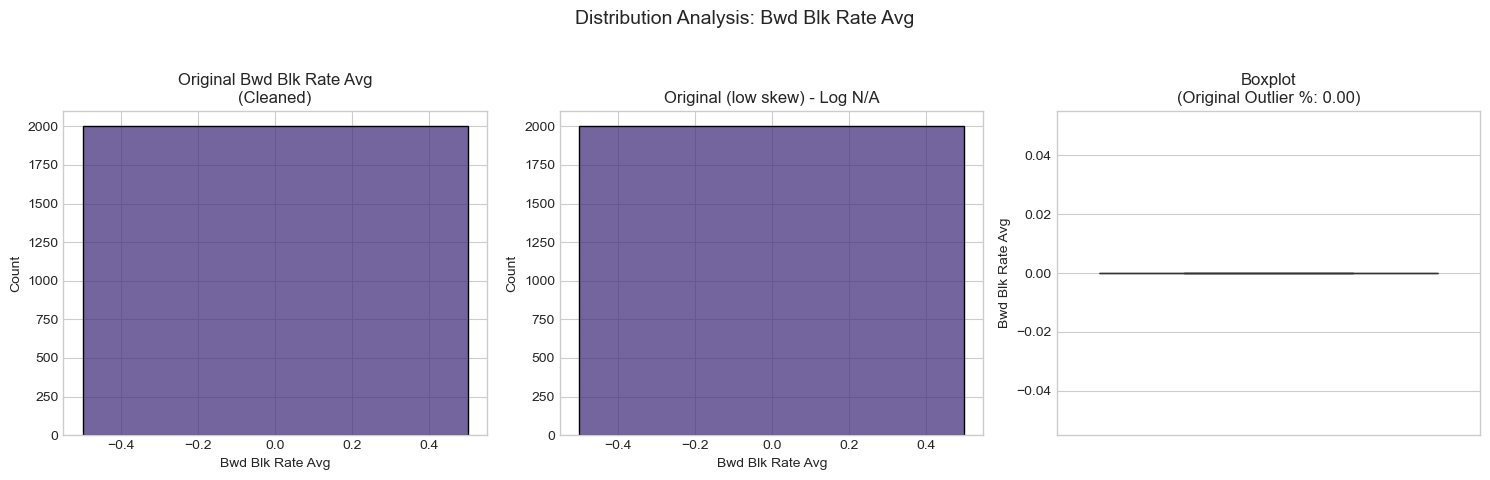

  Plots shown for 'Bwd Blk Rate Avg'.
  -> Finished feature: 'Bwd Blk Rate Avg' in 0.42 seconds.
[62/77] Starting analysis for feature: 'Subflow Fwd Pkts'...
  Calculating stats for 'Subflow Fwd Pkts'...
  Stats calculated for 'Subflow Fwd Pkts'.
  -> Feature 'Subflow Fwd Pkts' is very skewed. Skipping plotting to avoid hangs.
  -> Finished feature: 'Subflow Fwd Pkts' in 0.00 seconds.
[63/77] Starting analysis for feature: 'Subflow Fwd Byts'...
  Calculating stats for 'Subflow Fwd Byts'...
  Stats calculated for 'Subflow Fwd Byts'.
  Plotting distributions for 'Subflow Fwd Byts'...
    Original Data stats for 'Subflow Fwd Byts' before plotting:
count     2000.00000
mean       365.47700
std        856.95317
min          0.00000
25%          0.00000
50%         45.00000
75%        447.00000
max      20880.00000
Name: Subflow Fwd Byts, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Subflow Fwd Byts'.
    Trying sns.histplot (o

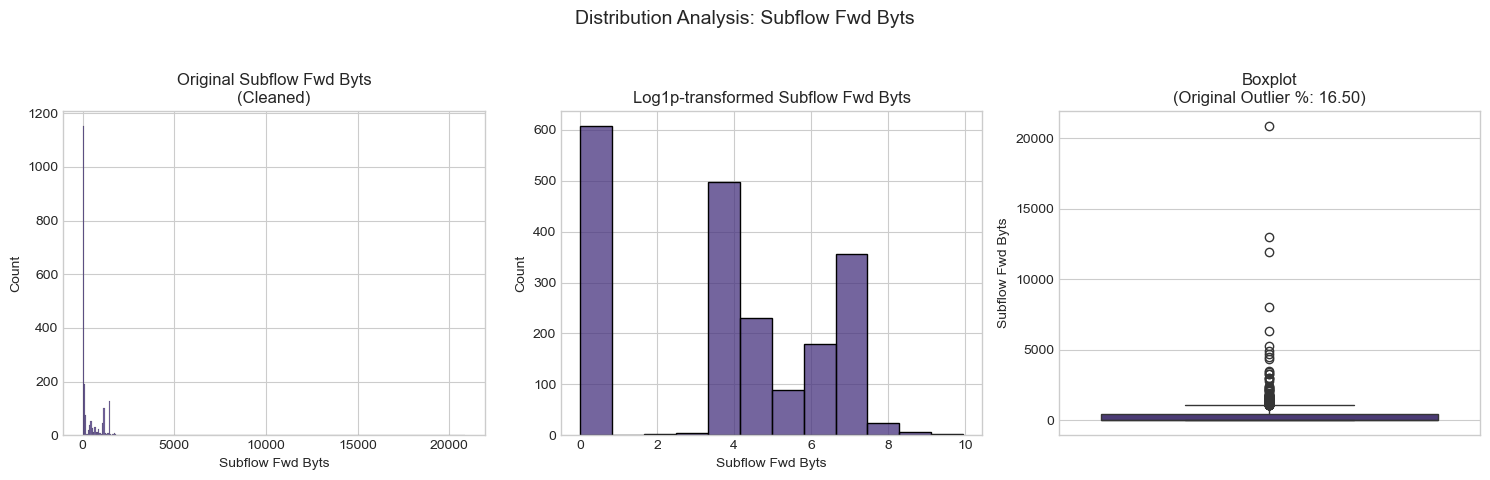

  Plots shown for 'Subflow Fwd Byts'.
  -> Finished feature: 'Subflow Fwd Byts' in 0.81 seconds.
[64/77] Starting analysis for feature: 'Subflow Bwd Pkts'...
  Calculating stats for 'Subflow Bwd Pkts'...
  Stats calculated for 'Subflow Bwd Pkts'.
  -> Feature 'Subflow Bwd Pkts' is very skewed. Skipping plotting to avoid hangs.
  -> Finished feature: 'Subflow Bwd Pkts' in 0.00 seconds.
[65/77] Starting analysis for feature: 'Subflow Bwd Byts'...
  Calculating stats for 'Subflow Bwd Byts'...
  Stats calculated for 'Subflow Bwd Byts'.
  -> Feature 'Subflow Bwd Byts' is very skewed. Skipping plotting to avoid hangs.
  -> Finished feature: 'Subflow Bwd Byts' in 0.00 seconds.
[66/77] Starting analysis for feature: 'Init Fwd Win Byts'...
  Calculating stats for 'Init Fwd Win Byts'...
  Stats calculated for 'Init Fwd Win Byts'.
    Replacing 628 negative values in 'Init Fwd Win Byts' with NaN before plotting.
  Plotting distributions for 'Init Fwd Win Byts'...
    Original Data stats for 'Init

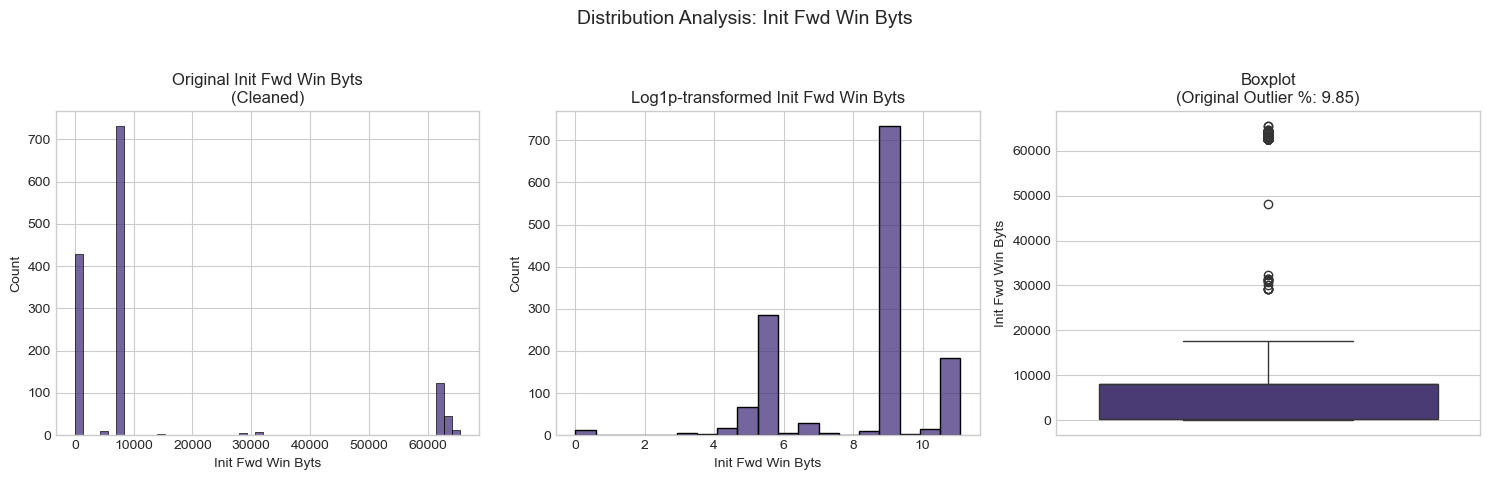

  Plots shown for 'Init Fwd Win Byts'.
  -> Finished feature: 'Init Fwd Win Byts' in 0.48 seconds.
[67/77] Starting analysis for feature: 'Init Bwd Win Byts'...
  Calculating stats for 'Init Bwd Win Byts'...
  Stats calculated for 'Init Bwd Win Byts'.
    Replacing 1110 negative values in 'Init Bwd Win Byts' with NaN before plotting.
  Plotting distributions for 'Init Bwd Win Byts'...
    Original Data stats for 'Init Bwd Win Byts' before plotting:
count     2000.000000
mean      9951.538500
std      22441.265546
min         -1.000000
25%         -1.000000
50%         -1.000000
75%        256.000000
max      65535.000000
Name: Init Bwd Win Byts, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 890 valid data points for 'Init Bwd Win Byts'.
    Trying sns.histplot (original) for 'Init Bwd Win Byts'...
    SUCCESS: sns.histplot (original) for 'Init Bwd Win Byts'.
    Trying sns.histplot (log) for 'Init Bwd Win Byts'...
    SUCCESS: sns.histplot (log) for 

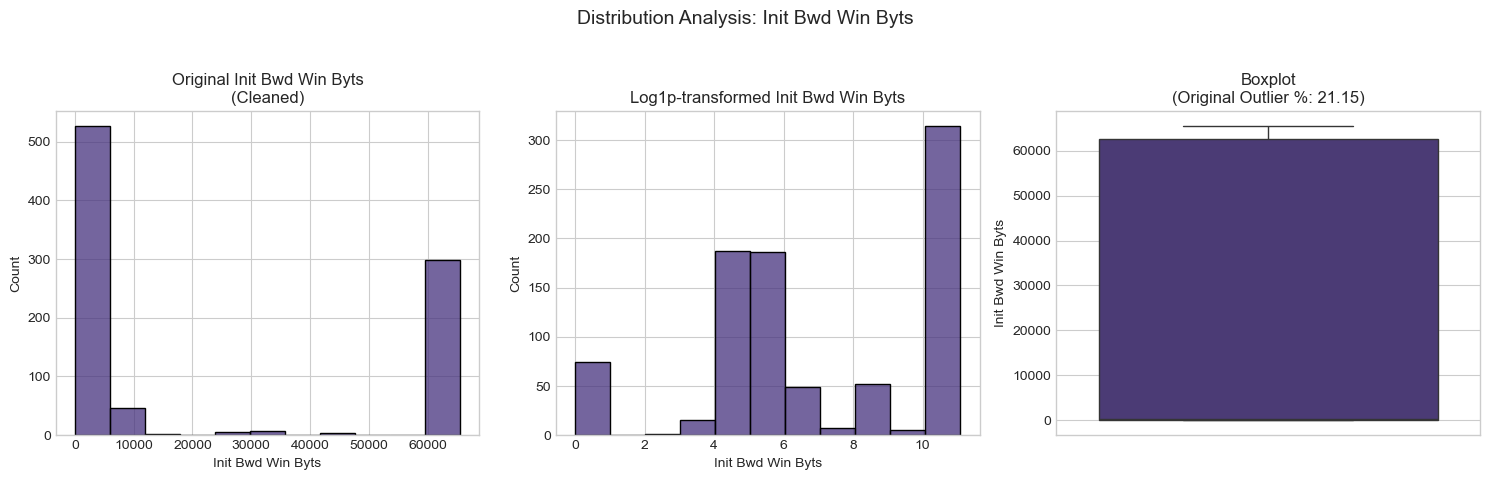

  Plots shown for 'Init Bwd Win Byts'.
  -> Finished feature: 'Init Bwd Win Byts' in 0.42 seconds.
[68/77] Starting analysis for feature: 'Fwd Act Data Pkts'...
  Calculating stats for 'Fwd Act Data Pkts'...
  Stats calculated for 'Fwd Act Data Pkts'.
  Plotting distributions for 'Fwd Act Data Pkts'...
    Original Data stats for 'Fwd Act Data Pkts' before plotting:
count    2000.000000
mean        2.141500
std         3.720269
min         0.000000
25%         0.000000
50%         0.000000
75%         4.000000
max        48.000000
Name: Fwd Act Data Pkts, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Fwd Act Data Pkts'.
    Trying sns.histplot (original) for 'Fwd Act Data Pkts'...
    SUCCESS: sns.histplot (original) for 'Fwd Act Data Pkts'.
    Trying sns.histplot (log) for 'Fwd Act Data Pkts'...
    SUCCESS: sns.histplot (log) for 'Fwd Act Data Pkts'.
    Trying sns.boxplot for 'Fwd Act Data Pkts'...
    SUCCESS: sns.box

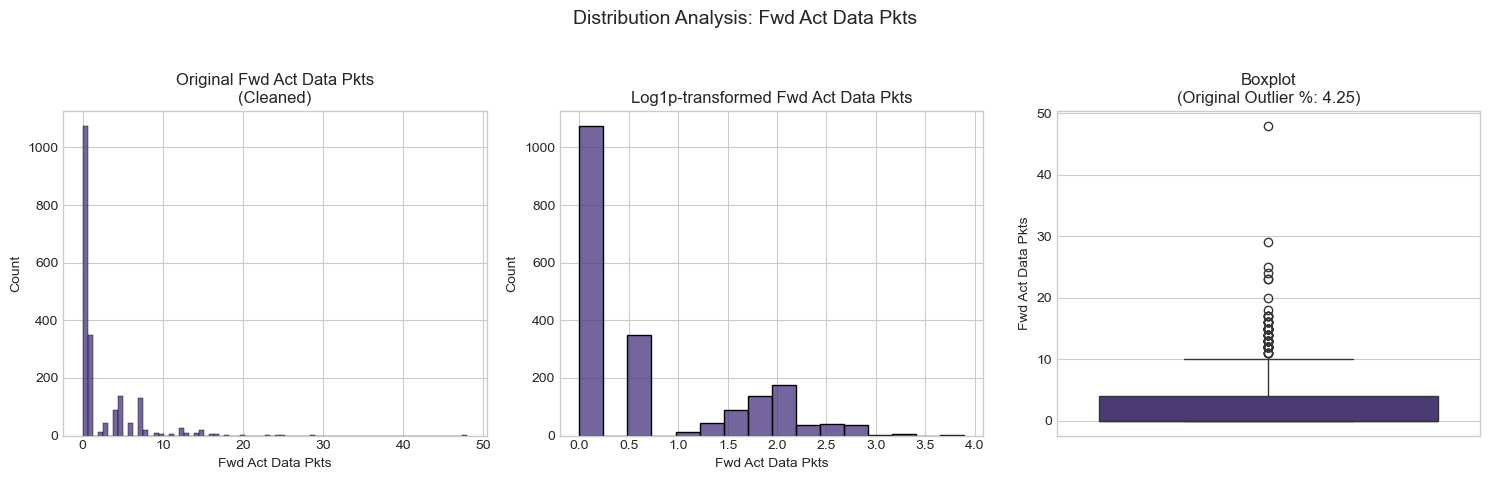

  Plots shown for 'Fwd Act Data Pkts'.
  -> Finished feature: 'Fwd Act Data Pkts' in 0.48 seconds.
[69/77] Starting analysis for feature: 'Fwd Seg Size Min'...
  Calculating stats for 'Fwd Seg Size Min'...
  Stats calculated for 'Fwd Seg Size Min'.
  Plotting distributions for 'Fwd Seg Size Min'...
    Original Data stats for 'Fwd Seg Size Min' before plotting:
count    2000.000000
mean       16.174000
std         5.900096
min         0.000000
25%         8.000000
50%        20.000000
75%        20.000000
max        40.000000
Name: Fwd Seg Size Min, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Fwd Seg Size Min'.
    Trying sns.histplot (original) for 'Fwd Seg Size Min'...
    SUCCESS: sns.histplot (original) for 'Fwd Seg Size Min'.
    Trying sns.histplot (log) for 'Fwd Seg Size Min'...
    SUCCESS: sns.histplot (log) for 'Fwd Seg Size Min'.
    Trying sns.boxplot for 'Fwd Seg Size Min'...
    SUCCESS: sns.boxplot for 'Fw

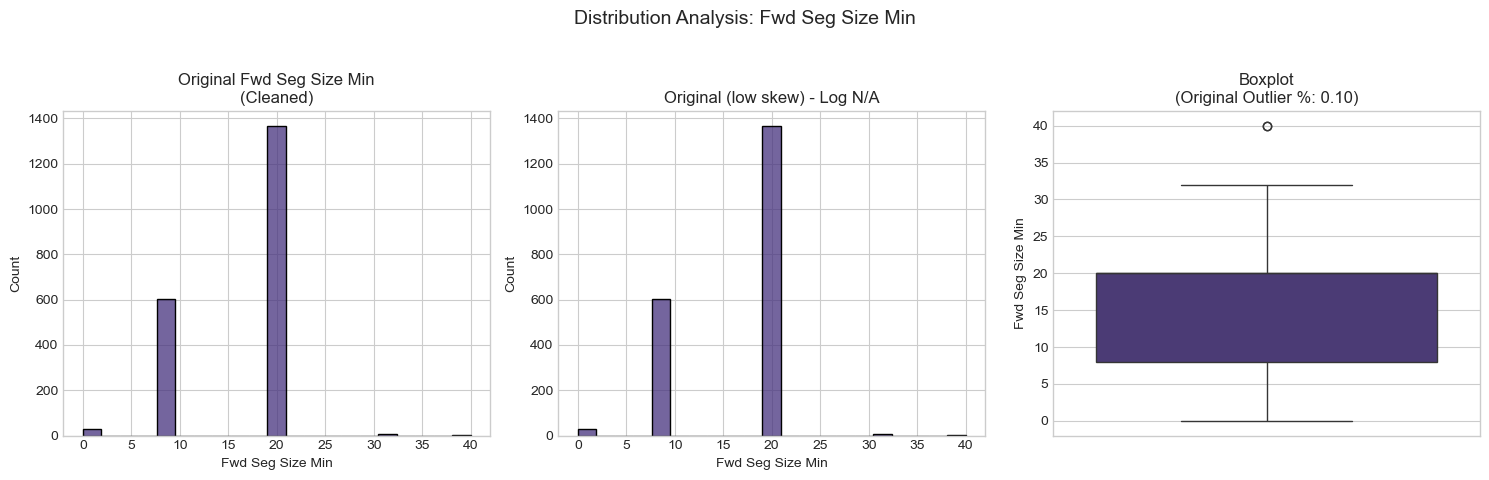

  Plots shown for 'Fwd Seg Size Min'.
  -> Finished feature: 'Fwd Seg Size Min' in 0.49 seconds.
[70/77] Starting analysis for feature: 'Active Mean'...
  Calculating stats for 'Active Mean'...
  Stats calculated for 'Active Mean'.
  -> Feature 'Active Mean' is very skewed. Skipping plotting to avoid hangs.
  -> Finished feature: 'Active Mean' in 0.00 seconds.
[71/77] Starting analysis for feature: 'Active Std'...
  Calculating stats for 'Active Std'...
  Stats calculated for 'Active Std'.
  Plotting distributions for 'Active Std'...
    Original Data stats for 'Active Std' before plotting:
count    2.000000e+03
mean     2.709365e+04
std      2.189176e+05
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      6.439990e+06
Name: Active Std, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Active Std'.
    Trying sns.histplot (original) for 'Active Std'...
    SUCCESS: sns.histplot (ori

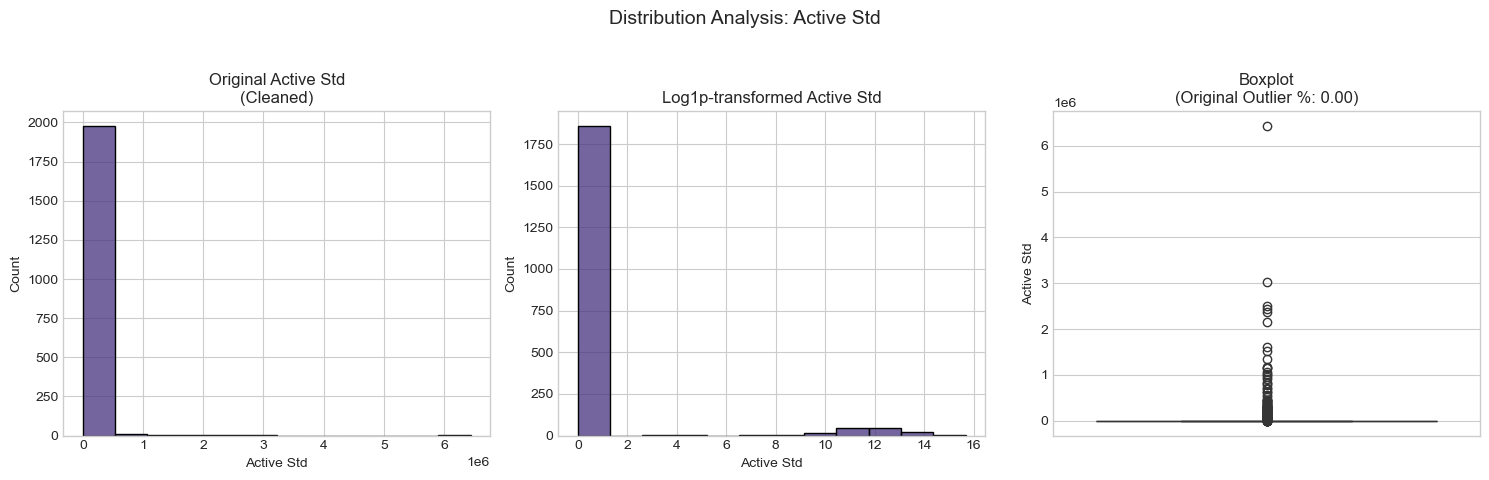

  Plots shown for 'Active Std'.
  -> Finished feature: 'Active Std' in 0.47 seconds.
[72/77] Starting analysis for feature: 'Active Max'...
  Calculating stats for 'Active Max'...
  Stats calculated for 'Active Max'.
  Plotting distributions for 'Active Max'...
    Original Data stats for 'Active Max' before plotting:
count    2.000000e+03
mean     1.110080e+05
std      8.612326e+05
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.988641e+07
Name: Active Max, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Active Max'.
    Trying sns.histplot (original) for 'Active Max'...
    SUCCESS: sns.histplot (original) for 'Active Max'.
    Trying sns.histplot (log) for 'Active Max'...
    SUCCESS: sns.histplot (log) for 'Active Max'.
    Trying sns.boxplot for 'Active Max'...
    SUCCESS: sns.boxplot for 'Active Max'.


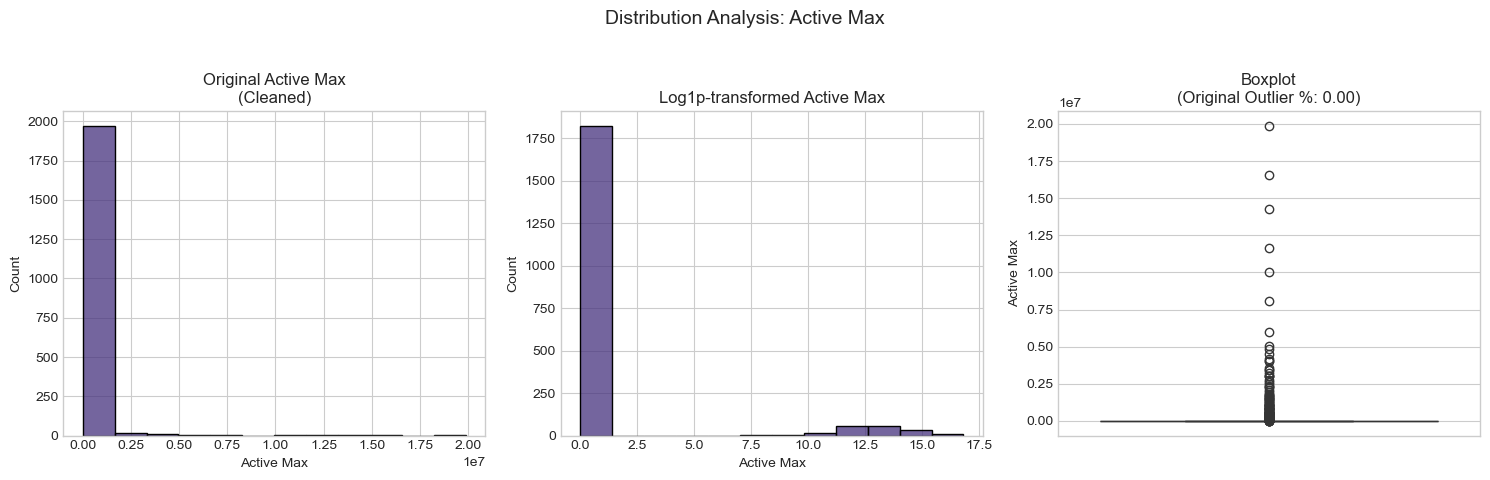

  Plots shown for 'Active Max'.
  -> Finished feature: 'Active Max' in 0.48 seconds.
[73/77] Starting analysis for feature: 'Active Min'...
  Calculating stats for 'Active Min'...
  Stats calculated for 'Active Min'.
  -> Feature 'Active Min' is very skewed. Skipping plotting to avoid hangs.
  -> Finished feature: 'Active Min' in 0.00 seconds.
[74/77] Starting analysis for feature: 'Idle Mean'...
  Calculating stats for 'Idle Mean'...
  Stats calculated for 'Idle Mean'.
  Plotting distributions for 'Idle Mean'...
    Original Data stats for 'Idle Mean' before plotting:
count    2.000000e+03
mean     9.369708e+06
std      2.493352e+07
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.177533e+08
Name: Idle Mean, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Idle Mean'.
    Trying sns.histplot (original) for 'Idle Mean'...
    SUCCESS: sns.histplot (original) for 'Idle Mean'.
 

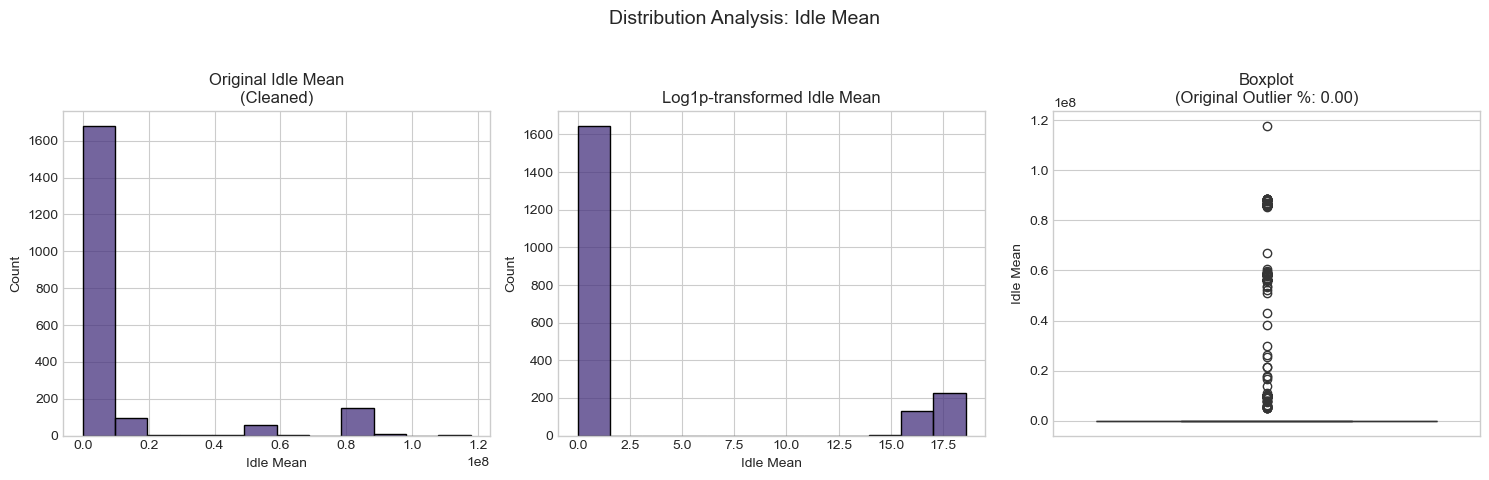

  Plots shown for 'Idle Mean'.
  -> Finished feature: 'Idle Mean' in 0.46 seconds.
[75/77] Starting analysis for feature: 'Idle Std'...
  Calculating stats for 'Idle Std'...
  Stats calculated for 'Idle Std'.
  -> Feature 'Idle Std' is very skewed. Skipping plotting to avoid hangs.
  -> Finished feature: 'Idle Std' in 0.01 seconds.
[76/77] Starting analysis for feature: 'Idle Max'...
  Calculating stats for 'Idle Max'...
  Stats calculated for 'Idle Max'.
  Plotting distributions for 'Idle Max'...
    Original Data stats for 'Idle Max' before plotting:
count    2.000000e+03
mean     9.434411e+06
std      2.498827e+07
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.177533e+08
Name: Idle Max, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Idle Max'.
    Trying sns.histplot (original) for 'Idle Max'...
    SUCCESS: sns.histplot (original) for 'Idle Max'.
    Trying sns.histplo

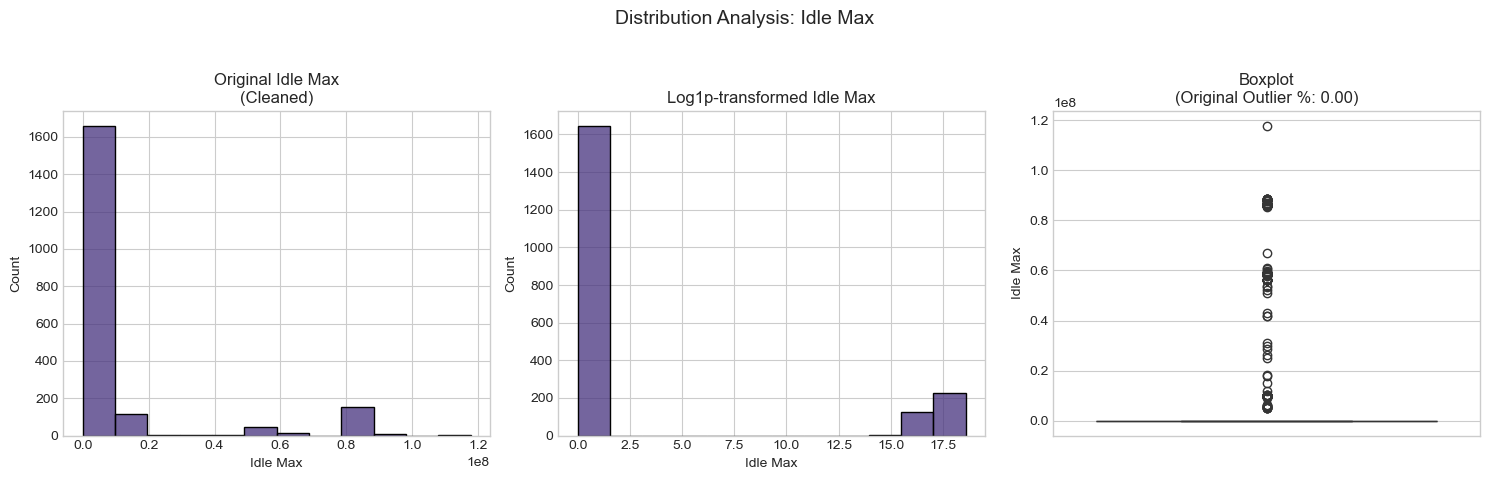

  Plots shown for 'Idle Max'.
  -> Finished feature: 'Idle Max' in 0.45 seconds.
[77/77] Starting analysis for feature: 'Idle Min'...
  Calculating stats for 'Idle Min'...
  Stats calculated for 'Idle Min'.
  Plotting distributions for 'Idle Min'...
    Original Data stats for 'Idle Min' before plotting:
count    2.000000e+03
mean     9.274381e+06
std      2.491144e+07
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.177533e+08
Name: Idle Min, dtype: float64
    Original NaN count: 0, Original Inf count: 0
    Plotting with 2000 valid data points for 'Idle Min'.
    Trying sns.histplot (original) for 'Idle Min'...
    SUCCESS: sns.histplot (original) for 'Idle Min'.
    Trying sns.histplot (log) for 'Idle Min'...
    SUCCESS: sns.histplot (log) for 'Idle Min'.
    Trying sns.boxplot for 'Idle Min'...
    SUCCESS: sns.boxplot for 'Idle Min'.


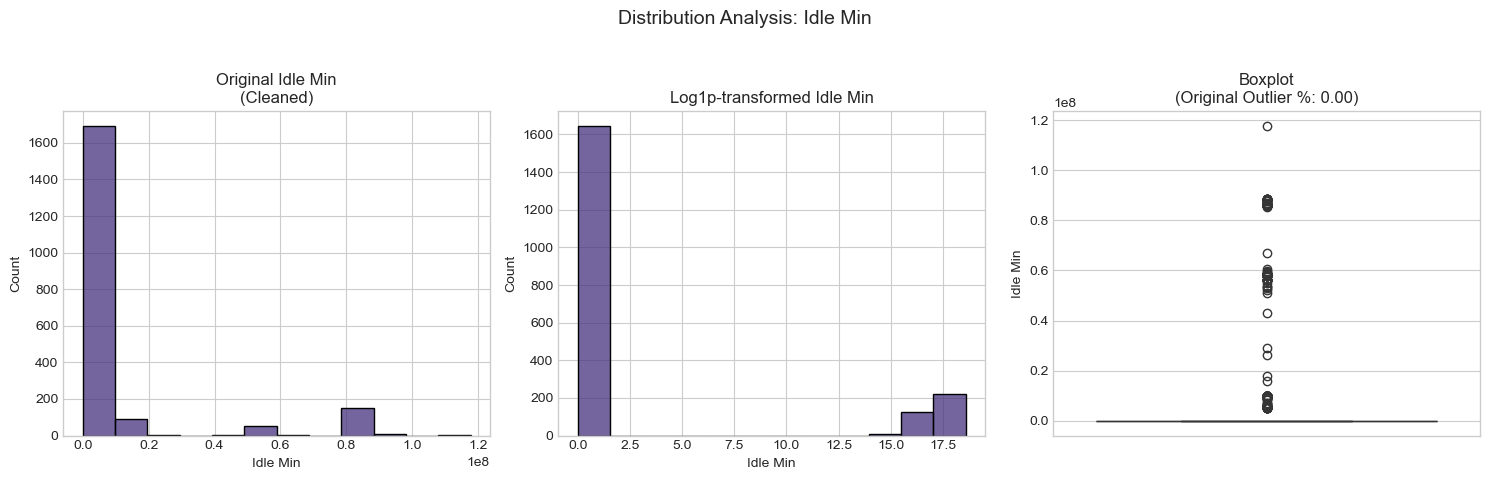

  Plots shown for 'Idle Min'.
  -> Finished feature: 'Idle Min' in 0.48 seconds.

Feature distribution analysis complete.

Features with skewness > 1.5: 59
Features with >10% outliers: 26


In [6]:
if df is not None:
    # Select numerical features, excluding identifiers and labels
    numerical_features = df.select_dtypes(include=np.number).columns.tolist()
    label_cols = ['is_attack'] # attack_type is likely object/category
    # Add known non-feature numeric columns (adjust as needed)
    id_like_cols = ['Timestamp', 'Src Port', 'Dst Port'] # Example
    # Filter out labels and identifiers
    feature_cols = [
        col for col in numerical_features
        if col not in label_cols and col not in id_like_cols and '_Id' not in col # General ID pattern
    ]
    print(f"\nSelected {len(feature_cols)} potential numerical features.")
    # print("Features:", feature_cols) # Uncomment to see list

    # Analyze feature distributions
    distribution_analysis = analyze_feature_distributions(df, feature_cols)

    # Optional: Print summary of highly skewed features or those with many outliers
    if distribution_analysis:
         high_skew = {k: v for k, v in distribution_analysis['skewness'].items() if abs(v) > 1.5}
         high_outliers = {k: v['percent'] for k, v in distribution_analysis['outliers'].items() if v['percent'] > 10}
         print(f"\nFeatures with skewness > 1.5: {len(high_skew)}")
         # print(high_skew)
         print(f"Features with >10% outliers: {len(high_outliers)}")
         # print(high_outliers)
else:
    print("\nSkipping feature selection and analysis because DataFrame 'df' is None.")
    feature_cols = [] # Ensure feature_cols is defined even if empty
    distribution_analysis = None

In [7]:
def create_transformation_pipeline(df, feature_cols, skewness_threshold=1.5, range_threshold=1000):
    """
    Create a transformation pipeline based on feature analysis.
    Returns functions and details needed for application/saving.
    """
    if df is None:
         print("DataFrame is None. Cannot create transformation pipeline.")
         return {}, {}

    print("\nCreating transformation pipeline...")
    transformations = {} # Stores callable functions (e.g., np.log1p, lambda scaler)
    transformation_details = {} # Stores type and parameters (e.g., min/max for scaling)

    for feature in feature_cols:
        if feature not in df.columns:
            print(f"Warning: Feature '{feature}' not in DataFrame. Skipping pipeline creation for it.")
            continue

        # Ensure column is numeric before proceeding
        if not pd.api.types.is_numeric_dtype(df[feature]):
            print(f"Warning: Feature '{feature}' is not numeric. Skipping transformation.")
            transformations[feature] = ('none', lambda x: x)
            transformation_details[feature] = {'type': 'none'}
            continue

        # Get skewness and range (handle potential NaNs in calculation)
        skewness = df[feature].skew()
        feature_min = df[feature].min()
        feature_max = df[feature].max()
        feature_range = feature_max - feature_min if pd.notna(feature_min) and pd.notna(feature_max) else 0

        # --- Decide on transformation ---
        transform_type = 'none' # Default

        # Condition 1: Log transform (positive and skewed)
        if abs(skewness) > skewness_threshold and feature_min >= 0:
            transform_type = 'log1p'
            transformations[feature] = (transform_type, np.log1p)
            transformation_details[feature] = {'type': transform_type}

        # Condition 2: MinMax scaling (wide range, not already log-transformed)
        # Check feature_range > 0 to avoid division by zero for constant columns
        elif feature_range > range_threshold and feature_range > 0:
            transform_type = 'minmax'
            min_val = feature_min
            max_val = feature_max
            # Define scaler using default arguments to capture current min/max
            scaler = lambda x, min_v=min_val, max_v=max_val: (x - min_v) / (max_v - min_v) if (max_v - min_v) > 0 else 0.0
            transformations[feature] = (transform_type, scaler)
            transformation_details[feature] = {'type': transform_type, 'min': min_val, 'max': max_val}

        # Condition 3: None (if neither above applies)
        else:
            transformations[feature] = ('none', lambda x: x)
            transformation_details[feature] = {'type': 'none'}

        # print(f"Feature: {feature}, Skew: {skewness:.2f}, Range: {feature_range:.2f} -> Transform: {transform_type}")


    print("Transformation pipeline created.")
    return transformations, transformation_details

print("Transformation pipeline creation function defined.")

Transformation pipeline creation function defined.


In [8]:
if df is not None and feature_cols:
    # Create the pipeline based on the original data 'df'
    transformation_pipeline, transformation_details = create_transformation_pipeline(df, feature_cols)

    # Display transformation decisions for the first few features
    print("\nTransformation decisions (sample):")
    count = 0
    for feature, details in transformation_details.items():
        print(f"- {feature}: {details['type']}")
        count += 1
        if count >= 10: # Show first 10
             break
else:
    print("\nSkipping transformation pipeline creation (df or feature_cols missing).")
    transformation_pipeline, transformation_details = {}, {}


Creating transformation pipeline...
Transformation pipeline created.

Transformation decisions (sample):
- Protocol: none
- Flow Duration: log1p
- Tot Fwd Pkts: log1p
- Tot Bwd Pkts: log1p
- TotLen Fwd Pkts: log1p
- TotLen Bwd Pkts: log1p
- Fwd Pkt Len Max: log1p
- Fwd Pkt Len Min: log1p
- Fwd Pkt Len Mean: log1p
- Fwd Pkt Len Std: log1p


In [9]:
def apply_transformations(df, transformations):
    """Apply the defined transformations to the dataset."""
    if df is None:
         print("DataFrame is None. Cannot apply transformations.")
         return None
    if not transformations:
         print("Transformation pipeline is empty. Returning original DataFrame.")
         return df.copy() # Return a copy

    df_transformed = df.copy()
    print("\nApplying transformations...")

    for feature, (transform_type, transform_func) in transformations.items():
        if feature in df_transformed.columns:
            if transform_type != 'none':
                try:
                    original_dtype = df_transformed[feature].dtype
                    # Apply the transformation function
                    transformed_col = transform_func(df_transformed[feature])

                    # Handle potential new NaNs or Infs introduced by transformation (e.g., log(0))
                    if isinstance(transformed_col, pd.Series):
                        if np.isinf(transformed_col).any() or transformed_col.isnull().any():
                            # Replace Inf with NaN first
                            transformed_col.replace([np.inf, -np.inf], np.nan, inplace=True)
                            # Fill NaNs created by transformation (e.g., with 0 or median of transformed data)
                            fill_value = 0.0 # Choose appropriate fill value
                            transformed_col.fillna(fill_value, inplace=True)
                            # print(f"NaNs/Infs introduced in {feature} after {transform_type}. Filled with {fill_value}.")
                    elif not np.isfinite(transformed_col).all(): # Check numpy array if function returns array
                         transformed_col[~np.isfinite(transformed_col)] = 0.0 # Fill non-finite with 0

                    df_transformed[feature] = transformed_col

                    # Optional: Check if dtype changed significantly (e.g., int to float)
                    # if df_transformed[feature].dtype != original_dtype:
                    #     print(f"Feature '{feature}' dtype changed from {original_dtype} to {df_transformed[feature].dtype} after {transform_type}.")

                except Exception as e:
                    print(f"Error applying {transform_type} to feature '{feature}': {e}. Skipping transformation for this feature.")
        # else: # Don't warn if feature wasn't in original selection passed to pipeline creator
        #     if feature in feature_cols: # Check against the list used to create pipeline
        #          print(f"Warning: Feature '{feature}' from pipeline not found in DataFrame during application.")

    print("Transformations applied.")
    return df_transformed

print("Transformation application function defined.")

Transformation application function defined.


In [10]:
if df is not None and transformation_pipeline:
    # Apply transformations to the original data
    df_transformed = apply_transformations(df, transformation_pipeline)

    # Display info of transformed data
    print("\nTransformed DataFrame basic info:")
    df_transformed.info()
    # print(df_transformed.head())

    # --- Save Transformation Details ---
    # Use 'transformation_details' which is JSON serializable
    pipeline_save_path = '../../src/models/transformation_details.json'
    # Ensure the directory exists
    os.makedirs(os.path.dirname(pipeline_save_path), exist_ok=True)
    try:
        # Convert numpy types to standard Python types for JSON
        serializable_details = {}
        for feature, details in transformation_details.items():
            serializable_details[feature] = {
                k: (v.item() if isinstance(v, (np.float64, np.int64, np.bool_)) else v)
                for k, v in details.items()
            }
        with open(pipeline_save_path, 'w') as f:
            json.dump(serializable_details, f, indent=4)
        print(f"\nTransformation details saved to {pipeline_save_path}")
    except TypeError as e:
         print(f"Error: Could not serialize transformation details to JSON: {e}")
         print("Details:", serializable_details) # Print problematic part
    except Exception as e:
        print(f"Error saving transformation details: {e}")


    # --- Save Transformed Dataset ---
    transformed_data_path = '../../data/processed/transformed_dataset.csv'
    try:
        df_transformed.to_csv(transformed_data_path, index=False)
        print(f"Transformed dataset saved to {transformed_data_path}")
    except Exception as e:
        print(f"Error saving transformed dataset: {e}")

else:
    print("\nSkipping transformation application and saving (df or pipeline missing).")
    df_transformed = df.copy() if df is not None else None # Keep df_transformed as original df if pipeline empty


Applying transformations...
Transformations applied.

Transformed DataFrame basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 83 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Dst Port           2000 non-null   int64  
 1   Protocol           2000 non-null   int64  
 2   Timestamp          2000 non-null   object 
 3   Flow Duration      2000 non-null   float64
 4   Tot Fwd Pkts       2000 non-null   float64
 5   Tot Bwd Pkts       2000 non-null   float64
 6   TotLen Fwd Pkts    2000 non-null   float64
 7   TotLen Bwd Pkts    2000 non-null   float64
 8   Fwd Pkt Len Max    2000 non-null   float64
 9   Fwd Pkt Len Min    2000 non-null   float64
 10  Fwd Pkt Len Mean   2000 non-null   float64
 11  Fwd Pkt Len Std    2000 non-null   float64
 12  Bwd Pkt Len Max    2000 non-null   float64
 13  Bwd Pkt Len Min    2000 non-null   float64
 14  Bwd Pkt Len Mean   2000 non-nul

In [11]:
# Calculate range info (min, max, median) from the *original* data ('df')
# This is used for clipping and imputation during inference/application.
range_info = {}
if df is not None and feature_cols:
    print("\nCalculating range info (min, max, median) from original data...")
    for feature in feature_cols:
        if feature in df.columns and pd.api.types.is_numeric_dtype(df[feature]):
            col_data = df[feature].dropna() # Use dropna for robust stats
            if not col_data.empty:
                 range_info[feature] = {
                     'min': col_data.min(),
                     'max': col_data.max(),
                     'median': col_data.median()
                 }
            else: # Handle empty or all-NaN columns
                 range_info[feature] = {'min': 0.0, 'max': 0.0, 'median': 0.0}
        # else: # Skip non-numeric or missing columns silently
        #    pass
    print("Range info calculation complete.")
    # print("Sample Range Info:", dict(list(range_info.items())[:5]))
else:
    print("\nSkipping range info calculation (df or feature_cols missing).")


Calculating range info (min, max, median) from original data...
Range info calculation complete.


In [12]:
def create_robust_preprocessing_function(feature_cols, transformation_details, range_info):
    """
    Creates a function to preprocess a single data instance (dict) robustly,
    handling missing values, clipping, and applying transformations based on saved details.
    """
    print("\nCreating robust preprocessing function...")

    # Reconstruct transformation functions from details (more robust than saving lambdas)
    transform_functions = {}
    for feature, details in transformation_details.items():
        transform_type = details.get('type', 'none')
        if transform_type == 'log1p':
            transform_functions[feature] = np.log1p
        elif transform_type == 'minmax':
            min_val = details.get('min')
            max_val = details.get('max')
            # Ensure min/max are valid numbers
            if pd.notna(min_val) and pd.notna(max_val) and (max_val - min_val) > 0:
                 # Create scaler function using default args to capture values
                 transform_functions[feature] = \
                    lambda x, min_v=min_val, max_v=max_val: (x - min_v) / (max_v - min_v)
            else: # Handle invalid range (e.g., constant column)
                 print(f"Warning: Invalid min/max for MinMax scaler on {feature}. Using identity transform.")
                 transform_functions[feature] = lambda x: x # Identity function
        else: # 'none' or unrecognized
            transform_functions[feature] = lambda x: x # Identity function


    def preprocess_features_instance(features_dict):
        """Applies robust preprocessing to a feature dictionary."""
        processed = {}

        # 1. Handle missing features using median from training range_info
        for feature in feature_cols:
            feature_value = features_dict.get(feature, None) # Use .get for safety
            if feature_value is not None and pd.notna(feature_value):
                processed[feature] = feature_value
            else:
                # Impute missing/NaN using median
                if feature in range_info and 'median' in range_info[feature]:
                    processed[feature] = range_info[feature]['median']
                    # print(f"Debug: Imputed missing '{feature}' with median {processed[feature]}")
                else:
                     processed[feature] = 0.0 # Fallback
                     # print(f"Debug: Imputed missing '{feature}' with fallback 0.0")

        # 2. Clip to training range (using min/max from range_info)
        for feature in processed:
             if feature in range_info:
                 min_val = range_info[feature].get('min', -np.inf)
                 max_val = range_info[feature].get('max', np.inf)
                 # Ensure values are valid numbers before comparison
                 if pd.notna(processed[feature]) and pd.notna(min_val) and pd.notna(max_val):
                      processed[feature] = np.clip(processed[feature], min_val, max_val)
                 # else: handle potential NaN in input or range_info if needed

        # 3. Apply transformations using reconstructed functions
        for feature in processed:
            if feature in transform_functions:
                try:
                    # Apply the corresponding function
                    transformed_value = transform_functions[feature](processed[feature])
                    # Handle potential NaN/Inf resulting from transformation
                    if not np.isfinite(transformed_value):
                         # print(f"Debug: Non-finite value after transform on {feature}. Replacing with 0.")
                         transformed_value = 0.0 # Replace NaN/Inf
                    processed[feature] = transformed_value
                except Exception as e:
                    print(f"Error applying transformation to '{feature}' during preprocessing: {e}. Leaving value as is (after clipping).")

        return processed # Return the dictionary of processed features

    print("Robust preprocessing function created.")
    return preprocess_features_instance

print("Robust preprocessing function definition complete.")

Robust preprocessing function definition complete.


In [13]:
if feature_cols and transformation_details and range_info:
    # Create the actual function closure
    preprocess_features_func = create_robust_preprocessing_function(
        feature_cols, transformation_details, range_info
    )

    # --- Save Components Needed for Inference ---
    # We need:
    # 1. List of feature columns in the correct order expected by the model.
    # 2. Transformation details (type and parameters like min/max).
    # 3. Range info (min, max, median) for clipping and imputation.
    preprocessing_components = {
        'feature_cols': feature_cols,
        'transformation_details': transformation_details, # Already serialized safely earlier
        'range_info': range_info # Contains min/max/median
    }

    components_save_path = '../../src/models/preprocessing_components.json'
    # Ensure the directory exists
    os.makedirs(os.path.dirname(components_save_path), exist_ok=True)
    try:
        # Convert numpy types to standard Python types for JSON
        serializable_components = json.loads(json.dumps(preprocessing_components, default=lambda x: x.item() if isinstance(x, (np.int64, np.float64, np.bool_)) else str(x)))

        with open(components_save_path, 'w') as f:
            json.dump(serializable_components, f, indent=4)
        print(f"\nPreprocessing components saved to {components_save_path}")

        # --- Example Usage (Optional) ---
        if df is not None and not df.empty:
             print("\nTesting preprocessing function on first row...")
             # Get a sample row as dict (handle potential errors if df is empty)
             sample_instance_dict = df.iloc[0].to_dict()
             # Preprocess the sample
             processed_sample = preprocess_features_func(sample_instance_dict)
             print("Sample Original Features (first 5):")
             print({k: sample_instance_dict.get(k) for k in feature_cols[:5]})
             print("\nSample Processed Features (first 5):")
             print({k: processed_sample.get(k) for k in feature_cols[:5]})
        else:
             print("\nSkipping preprocessing test (original df is empty or None).")


    except TypeError as e:
         print(f"Error: Could not serialize preprocessing components to JSON: {e}")
         # Try to identify the problematic part
         for key, value in preprocessing_components.items():
              try:
                   json.dumps(value, default=lambda x: x.item() if isinstance(x, (np.int64, np.float64, np.bool_)) else str(x))
              except Exception as E:
                   print(f"Problem might be in key: {key}")
                   # print(f"Content sample: {str(value)[:200]}") # Print sample of problematic data
    except Exception as e:
        print(f"Error saving preprocessing components: {e}")

else:
    print("\nSkipping creation of preprocessing function and saving components (required info missing).")


Creating robust preprocessing function...
Robust preprocessing function created.

Preprocessing components saved to ../../src/models/preprocessing_components.json

Testing preprocessing function on first row...
Sample Original Features (first 5):
{'Protocol': 6, 'Flow Duration': 1692719, 'Tot Fwd Pkts': 16, 'Tot Bwd Pkts': 16, 'TotLen Fwd Pkts': 1096}

Sample Processed Features (first 5):
{'Protocol': 6, 'Flow Duration': 14.341847260550171, 'Tot Fwd Pkts': 2.833213344056216, 'Tot Bwd Pkts': 2.833213344056216, 'TotLen Fwd Pkts': 7.00033446027523}
